# Francesco/Esteves/Valle Model — Complete Analysis with Sector Benchmarks

Evaluates the **Francesco/Esteves/Valle Model** portfolio optimized against benchmarks from the **11 GICS sectors (Global Industry Classification Standard)**
(equal-weighted return of each S&P 500 sector).

| Model | Optimization Benchmark |
|-------|------------------------|
| **Francesco/Esteves/Valle Model** | Synthetic Benchmark = max_k(Tail_{s/S^k}) of the 11 sectors |
| **Roman Model (Scaled)** | SP500 (reference) |
| **Francesco/Esteves/Valle Model (Factors)** | Synthetic Benchmark of Fama-French factors |

---


---
## Experiment Settings
| Parameter | Value |
|-----------|-------|
| **Model** | TAF-MultiSSD (tafmSSD) — multi-benchmark SSD, synthetic benchmark (*max_k* operator) |
| **Formulation** | MIP with lazy constraints (CPLEX callback; dummy binary var `cb_temp`) |
| **In-sample window** | 200 days (sliding window) |
| **Universe** | ~505 S&P 500 constituent assets (after removing >15% missing values) |
| **Benchmark** | Synthetic = max_k(Tail_{s/S^k}) of the 11 GICS sectors |
| **Rebalancing frequency** | Every 21 business days |
| **Out-of-sample period** | 2024-01-02 to 2024-06-01 |
| **Number of rebalancings** | 5 |
| **Transaction costs** | None |
| **Minimum lots** | None |
---


---

**Structure:**
1. Setup
2. Data and model loading
3. Market context — OOS sectors
3b. Dominant sector per OOS day
4. Synthetic Benchmark OOS — detailed analysis
5. Constraint tightness — τ_k per sector per window
6. Dominant sector by rank
7. Overview — portfolio vs sectors
8. Comparative drawdown
9. OOS metrics — complete table
10. SSD dominance
10b. SSD dominance — CDFs and cumulative integrals (Francesco/Esteves/Valle Model)
10c. r_P vs r_B by quantile — tail analysis
11. Risk × return analysis
12. Distribution and correlation
13. Rolling returns
14. Executive summary
15. Consolidated analysis of the experiment

---


---
## 1. Setup
---


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter

warnings.filterwarnings('ignore')

ROOT             = Path('..').resolve()
SRC              = ROOT / 'src'
OUTPUT_DIR       = SRC / 'output'
SECTORS_DIR_OUT  = OUTPUT_DIR / 'tafmssd-sectors'
TAFMSSD_DIR      = OUTPUT_DIR / 'tafmssd'
SCSSD_DIR        = OUTPUT_DIR / 'scssd'
DATA_DIR         = SRC / 'data'
SECTORS_DATA_DIR = DATA_DIR / 'sectors'

sys.path.insert(0, str(SRC))
from metrics.stats import compute_ssd_dominance, compute_metrics
from blotter.plots import (
    plot_market_context, plot_performance,
    plot_dominance_overview, plot_dominance_panels,
    plot_risk_return_scatter, plot_return_distribution,
    plot_correlation_matrix, plot_drawdown, plot_rolling_returns,
    plot_portfolio_comparison,
)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top':  False,   'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 12,
})

AVAILABLE_SECTORS = sorted([f.stem for f in SECTORS_DATA_DIR.glob('*.csv')])
OOS_START  = '2024-01-01'
OOS_END    = '2024-06-01'
RISK_FREE  = 0.05

SECTOR_PALETTE = {
    'BASIC_MATERIALS':             '#8c564b',
    'CONSUMER_CYCLICALS':          '#ff7f0e',
    'CONSUMER_NON_CYCLICALS':      '#bcbd22',
    'ENERGY':                      '#d62728',
    'FINANCIALS':                  '#1f77b4',
    'HEALTHCARE':                  '#2ca02c',
    'INDUSTRIALS':                 '#7f7f7f',
    'REAL_ESTATE':                 '#9467bd',
    'TECHNOLOGY':                  '#17becf',
    'TELECOMMUNICATIONS_SERVICES': '#e377c2',
    'UTILITIES':                   '#aec7e8',
}

print(f'ROOT: {ROOT}')
print(f'Available sectors ({len(AVAILABLE_SECTORS)}): {AVAILABLE_SECTORS}')


ROOT: /media/toni/Dados/Git/ssd-multi
Available sectors (11): ['BASIC_MATERIALS', 'CONSUMER_CYCLICALS', 'CONSUMER_NON_CYCLICALS', 'ENERGY', 'FINANCIALS', 'HEALTHCARE', 'INDUSTRIALS', 'REAL_ESTATE', 'TECHNOLOGY', 'TELECOMMUNICATIONS_SERVICES', 'UTILITIES']


---
## 2. Data and model loading
---


In [2]:
# ── Market data (assets + SP500) ──────────────────────────────────────────────
market        = pd.read_csv(DATA_DIR / 'marketData.csv', parse_dates=['Date'])
market.set_index('Date', inplace=True)
market_prices = market.dropna(how='all').abs()
market_returns = market_prices.diff() / market_prices.shift(1)
market_returns = market_returns.iloc[1:]

# ── Sector equal-weighted returns ──────────────────────────────────────────────
def load_sector_returns(sectors_dir, selected, index):
    frames = {}
    for sector in selected:
        prices = pd.read_csv(sectors_dir / f'{sector}.csv', parse_dates=['Date'])
        prices.set_index('Date', inplace=True)
        prices = prices[prices.columns[prices.isnull().mean() <= 0.15]]
        prices = prices.ffill().bfill().abs()
        ret    = prices.diff() / prices.shift(1)
        ret    = ret.iloc[1:]
        frames[sector] = ret.mean(axis=1)
    return pd.DataFrame(frames).reindex(index)

sector_returns = load_sector_returns(SECTORS_DATA_DIR, AVAILABLE_SECTORS, market_returns.index)

# ── OOS sector series ──────────────────────────────────────────────────────────
sector_oos = {}
for s in AVAILABLE_SECTORS:
    ret = sector_returns.loc[OOS_START:OOS_END, s].dropna()
    cum = (1 + ret).cumprod()
    sector_oos[s] = {'norm': (cum / cum.iloc[0]), 'ret': ret}

idx = sector_oos[AVAILABLE_SECTORS[0]]['norm'].index

# SP500 OOS (for reference only)
sp500_oos  = market_prices.loc[OOS_START:OOS_END, 'SP500']
sp500_norm = (sp500_oos / sp500_oos.iloc[0]).reindex(idx)
sp500_ret  = market_returns.loc[OOS_START:OOS_END, 'SP500'].reindex(idx)

print(f'Market data  : {market_prices.shape}')
print(f'OOS          : {idx[0].date()} → {idx[-1].date()}  ({len(idx)} days)')
print(f'Sectors      : {sector_returns.shape}')


Market data  : (305, 509)
OOS          : 2024-01-02 → 2024-05-31  (105 days)
Sectors      : (304, 11)


In [3]:
# ── Load model portfolios ──────────────────────────────────────────────────────
def load_port(path, label):
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    s  = df.iloc[:, 0].reindex(idx).ffill()
    return s.rename(label)

models = {}

# Francesco/Esteves/Valle Model (sector synthetic benchmark)
sec_path = SECTORS_DIR_OUT / 'portfolio_tafmssd_sectors.csv'
if sec_path.exists():
    models['Francesco/Esteves/Valle Model'] = load_port(sec_path, 'Francesco/Esteves/Valle Model')

# Roman Model (Scaled) — SP500 reference
scssd_path = SCSSD_DIR / 'portfolio_scssd.csv'
if scssd_path.exists():
    models['Roman Model (Scaled)'] = load_port(scssd_path, 'Roman Model (Scaled)')

# tafmSSD (factor-based, for comparison)
taf_path = TAFMSSD_DIR / 'portfolio_tafmssd.csv'
if taf_path.exists():
    models['Francesco/Esteves/Valle Model (Factors)'] = load_port(taf_path, 'Francesco/Esteves/Valle Model (Factors)')

# OOS synthetic sector benchmark
synth_path = SECTORS_DIR_OUT / 'synthetic_benchmark_oos.csv'
if synth_path.exists():
    synth_oos = pd.read_csv(synth_path, index_col=0, parse_dates=True).squeeze().reindex(idx).ffill()
else:
    # Same formulation as the experiment: tau_oos[s] = max_k(Tail_{s/S_k}(I_k))
    # over OOS sector returns; implied sorted returns dated by quantile matching
    # against the cross-sector mean return.
    ret_oos   = pd.DataFrame({s: sector_oos[s]['ret'] for s in AVAILABLE_SECTORS}).reindex(idx)
    S_oos     = len(ret_oos)
    tails     = np.column_stack([np.cumsum(np.sort(ret_oos[s].values)) / S_oos
                                 for s in AVAILABLE_SECTORS])
    tau_oos   = tails.max(axis=1)
    abs_oos   = np.diff(S_oos * tau_oos, prepend=0.0)
    order     = ret_oos.mean(axis=1).rank(method='first').astype(int) - 1
    synth_ret = pd.Series(abs_oos[order.values], index=ret_oos.index)
    synth_oos = (1 + synth_ret).cumprod()
    synth_oos = synth_oos / synth_oos.iloc[0]

print(f'\nLoaded models ({len(models)}):')
for k, v in models.items():
    print(f'  {k:<40}  final = {v.iloc[-1]:.4f}  ({(v.iloc[-1]-1)*100:+.2f}%)')



Loaded models (3):
  Francesco/Esteves/Valle Model             final = 1.6089  (+60.89%)
  Roman Model (Scaled)                      final = 1.4911  (+49.11%)
  Francesco/Esteves/Valle Model (Factors)   final = 1.2230  (+22.30%)


---
## 3. Market context — OOS sectors
---


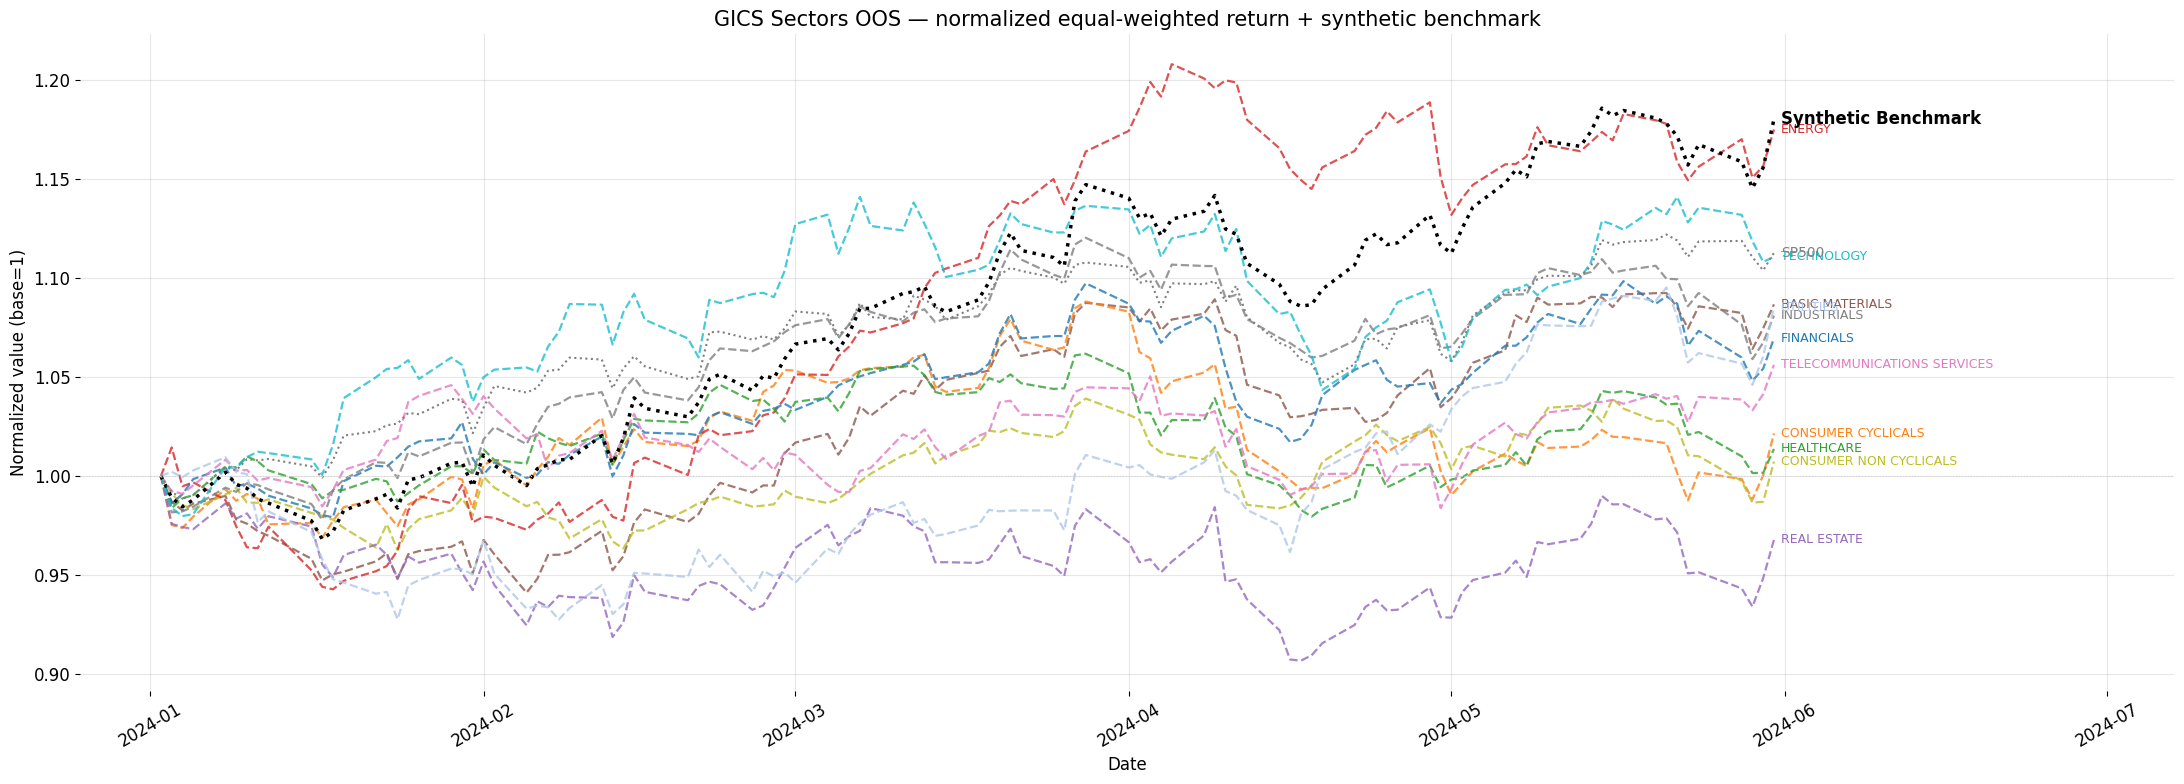

In [4]:
fig, ax = plt.subplots(figsize=(22, 8))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for sector in AVAILABLE_SECTORS:
    norm  = sector_oos[sector]['norm']
    color = SECTOR_PALETTE[sector]
    ax.plot(norm.index, norm.values, linewidth=1.6, linestyle='--', color=color, alpha=0.8)
    ax.annotate(sector.replace('_', ' '), xy=(norm.index[-1], norm.iloc[-1]),
                xytext=(5, 0), textcoords='offset points', va='center',
                fontsize=9, color=color)

ax.plot(synth_oos.index, synth_oos.values, linestyle=':', linewidth=2.5, color='black')
ax.annotate('Synthetic Benchmark', xy=(synth_oos.index[-1], synth_oos.iloc[-1]),
            xytext=(5, 0), textcoords='offset points', va='center',
            fontsize=12, color='black', fontweight='bold')

ax.plot(sp500_norm.index, sp500_norm.values, linewidth=1.5, color='gray', linestyle=':')
ax.annotate('SP500', xy=(sp500_norm.index[-1], sp500_norm.iloc[-1]),
            xytext=(5, 0), textcoords='offset points', va='center', fontsize=10, color='gray')

ax.axhline(1.0, color='lightgray', linewidth=0.8, linestyle=':')
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.18)
ax.set_title('GICS Sectors OOS — normalized equal-weighted return + synthetic benchmark', fontsize=15)
ax.set_xlabel('Date'); ax.set_ylabel('Normalized value (base=1)')
ax.tick_params(axis='x', rotation=30)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'sectors_overview.pdf', bbox_inches='tight')
plt.show()


**Market context (overview of OOS sectors)**

The chart shows the normalized performance of all 11 GICS sectors during the out-of-sample period. The solid black line (Synthetic Benchmark) is the compounded value of the synthetic distribution built with the same formulation used in the optimization — $\max_k\bigl(\mathrm{Tail}_{s/S^k}(R(I^k))\bigr)$ over the OOS sector returns — with the implied returns assigned to dates by quantile matching (the worst synthetic return falls on the worst day of the cross-sector mean return). The spread between sectors reveals the heterogeneity of the OOS environment: a well-optimized portfolio should outperform most individual sectors; the Synthetic Benchmark ends the period close to the best sector — at each tail level it adopts the most demanding sector's requirement, but, being a distribution (not a path envelope), it can be crossed intermittently by individual sectors. Sectors below 1.0 represent absolute losses over the period and imposed looser SSD constraints on the model. SP500 (dotted gray) serves as a broad market reference; when the Synthetic Benchmark sits clearly above SP500, the environment created by the sectors was more demanding than the overall market — tightening the constraints the portfolio had to satisfy at each rebalancing.

**Normalization formula:**

$$\text{norm}_s(t) = \prod_{i=1}^{t}\bigl(1 + r_{s,i}\bigr) = \frac{P_s(t)}{P_s(0)}, \qquad \tau_{\text{oos}}[s] = \max_k\left(\mathrm{Tail}_{\frac{s}{S^k}}\bigl(R(I^k)\bigr)\right), \quad r^{(s)}_{\text{synth}} = S\,\tau_{\text{oos}}[s] - S\,\tau_{\text{oos}}[s-1]$$

where $r_{s,i}$ is sector $s$'s equal-weighted return on day $i$ (mean of its constituents' daily returns) and $P_s(t)$ its cumulative-return index. Every series is rebased to 1.0 on the first OOS day; the Synthetic Benchmark compounds the implied returns $r^{(s)}_{\text{synth}}$ of the tail-expectation envelope, dated by quantile matching against the cross-sector mean return.

---


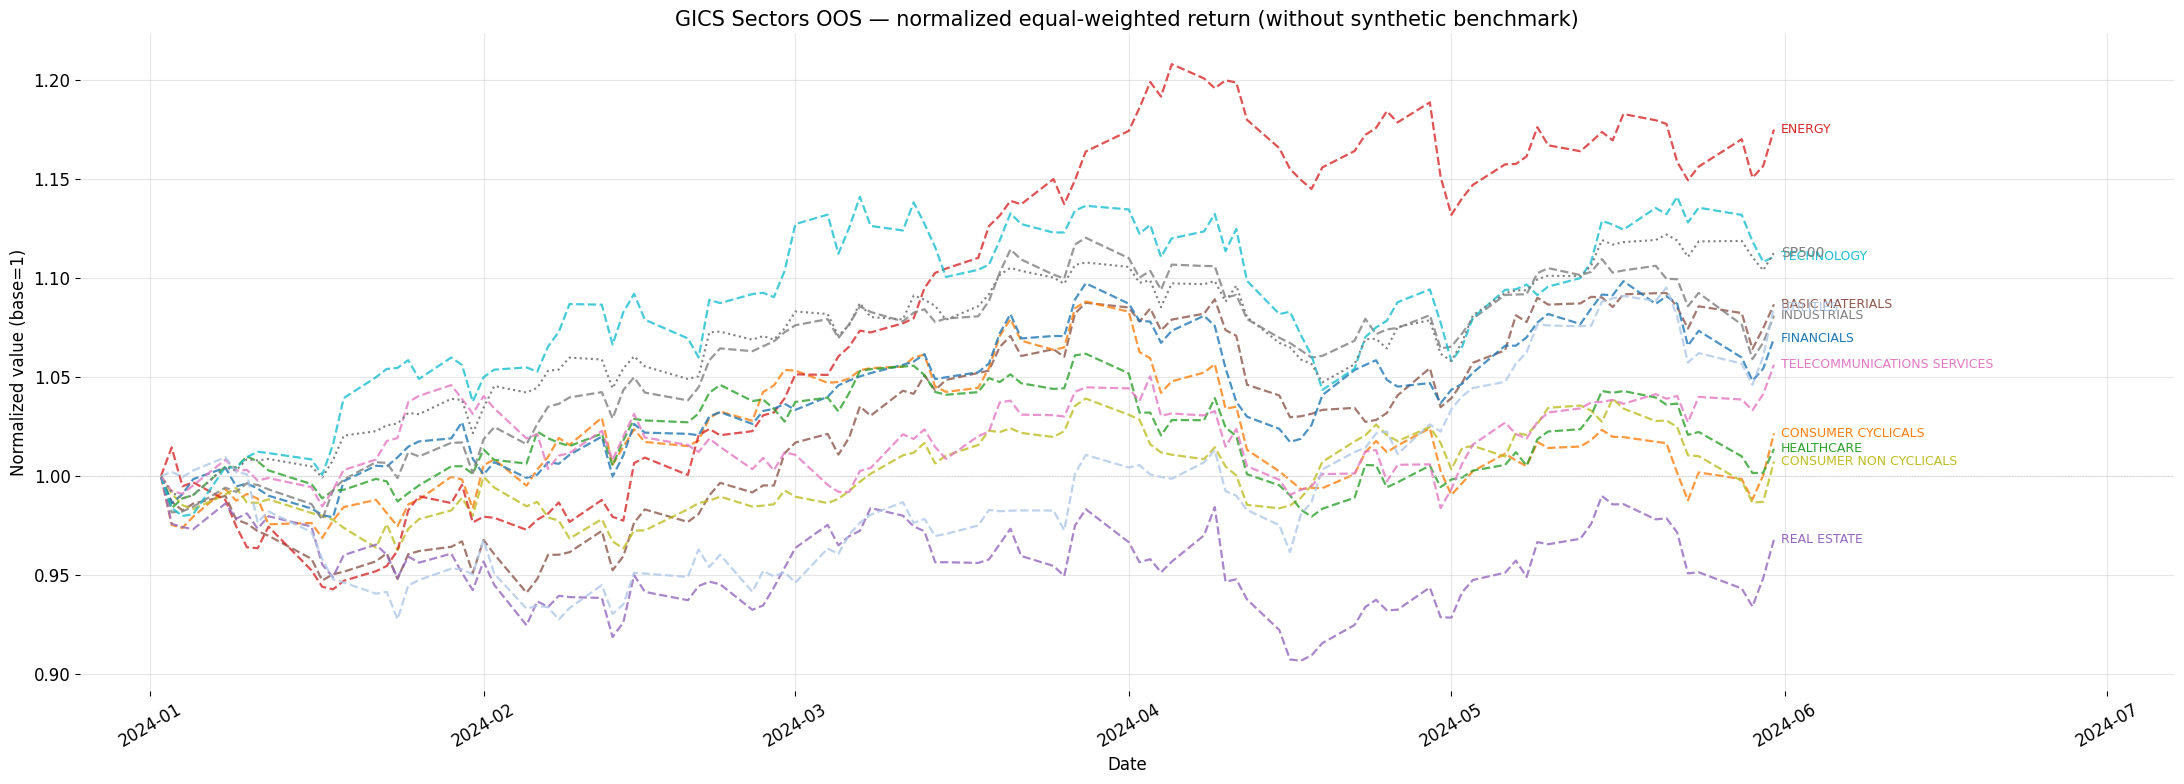

In [5]:
fig, ax = plt.subplots(figsize=(22, 8))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

for sector in AVAILABLE_SECTORS:
    norm  = sector_oos[sector]['norm']
    color = SECTOR_PALETTE[sector]
    ax.plot(norm.index, norm.values, linewidth=1.6, linestyle='--', color=color, alpha=0.8)
    ax.annotate(sector.replace('_', ' '), xy=(norm.index[-1], norm.iloc[-1]),
                xytext=(5, 0), textcoords='offset points', va='center',
                fontsize=9, color=color)


ax.plot(sp500_norm.index, sp500_norm.values, linewidth=1.5, color='gray', linestyle=':')
ax.annotate('SP500', xy=(sp500_norm.index[-1], sp500_norm.iloc[-1]),
            xytext=(5, 0), textcoords='offset points', va='center', fontsize=10, color='gray')

ax.axhline(1.0, color='lightgray', linewidth=0.8, linestyle=':')
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.18)
ax.set_title('GICS Sectors OOS — normalized equal-weighted return (without synthetic benchmark)', fontsize=15)
ax.set_xlabel('Date'); ax.set_ylabel('Normalized value (base=1)')
ax.tick_params(axis='x', rotation=30)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'sectors_overview_no_synth.pdf', bbox_inches='tight')
plt.show()


**Market context without the Synthetic Benchmark**

Same view as the previous chart, but without the synthetic envelope: the dominant black line is removed to highlight the dispersion across the 11 GICS sectors and the relative position of the SP500 (gray dotted). Without the envelope it becomes easier to read which sectors lead in each stretch of the OOS period — information that in the previous chart is visually compressed by the black Synthetic Benchmark line.

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_basic_materials.pdf


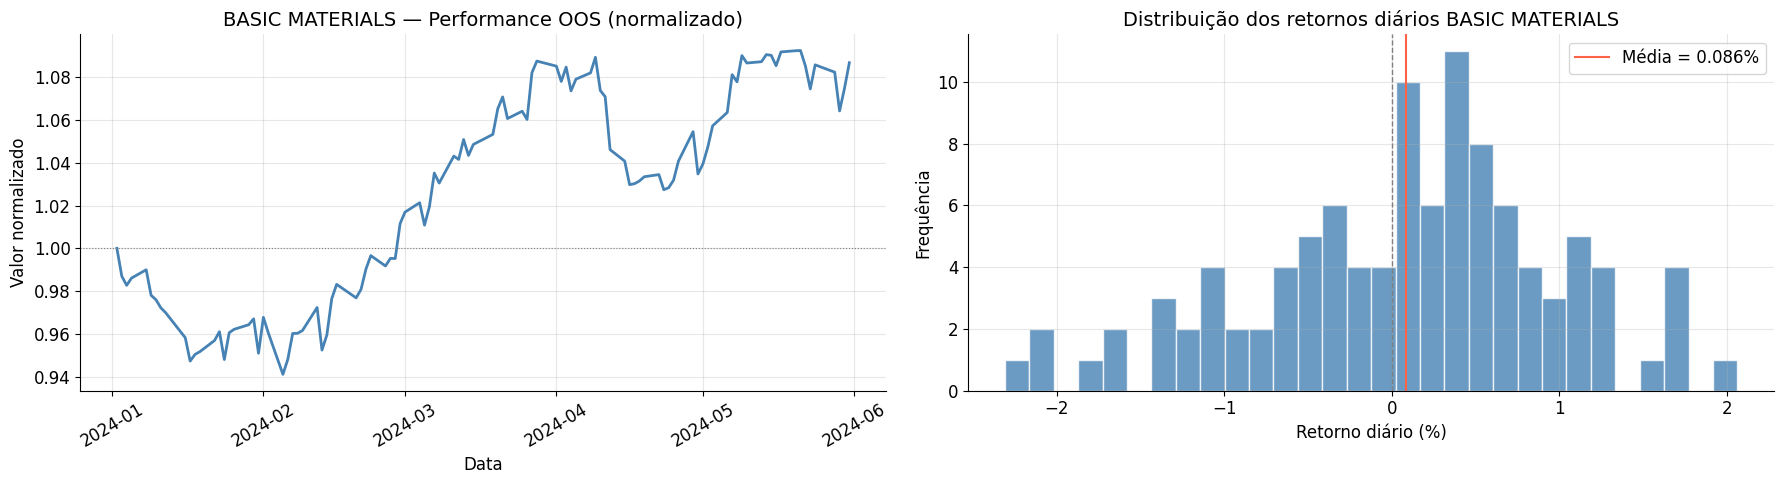

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_consumer_cyclicals.pdf


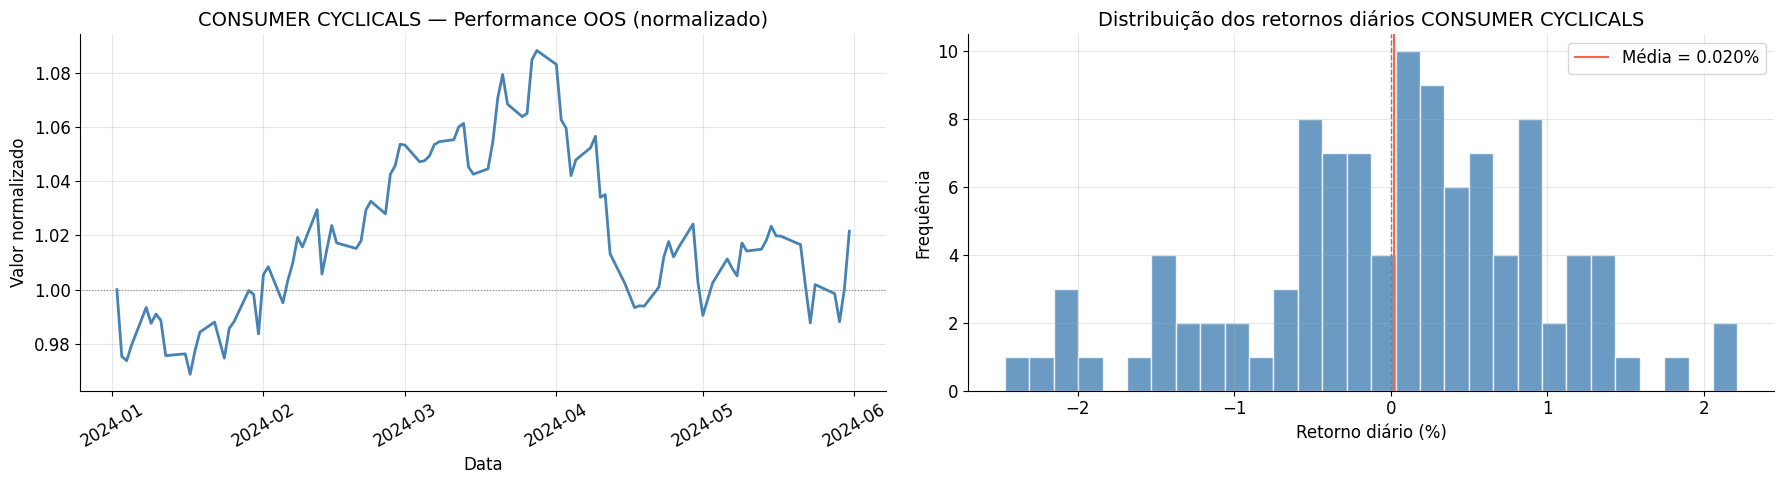

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_consumer_non_cyclicals.pdf


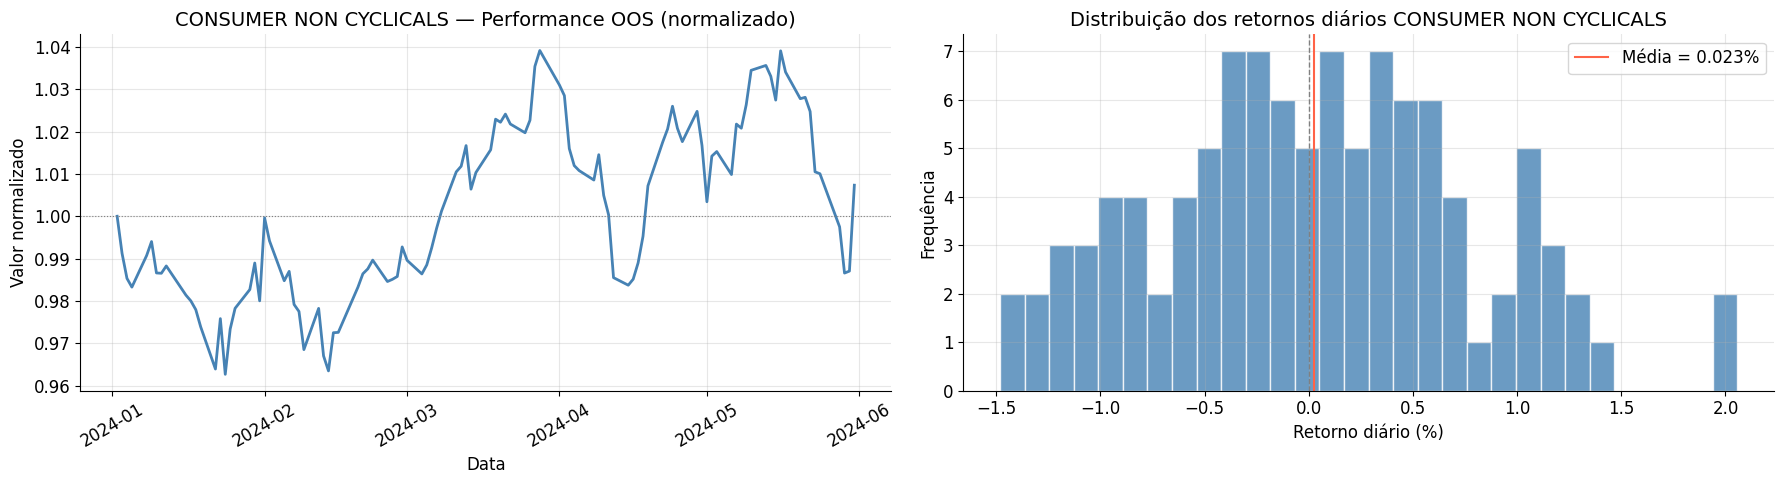

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_energy.pdf


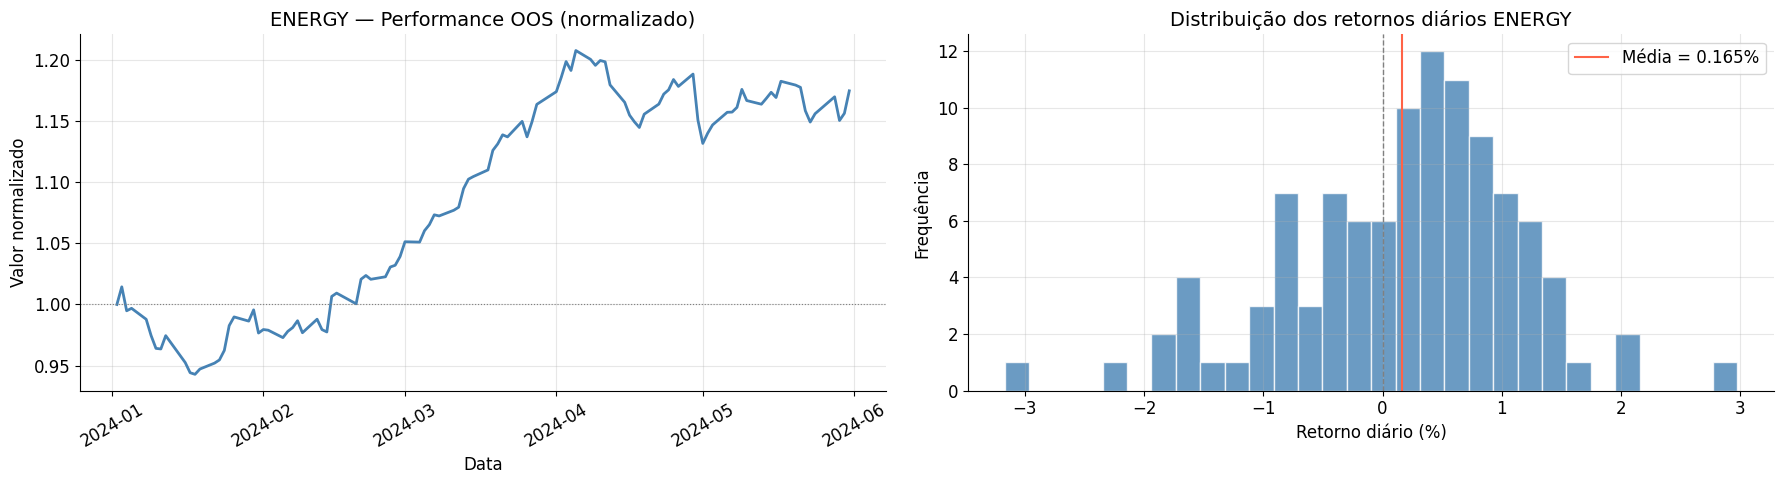

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_financials.pdf


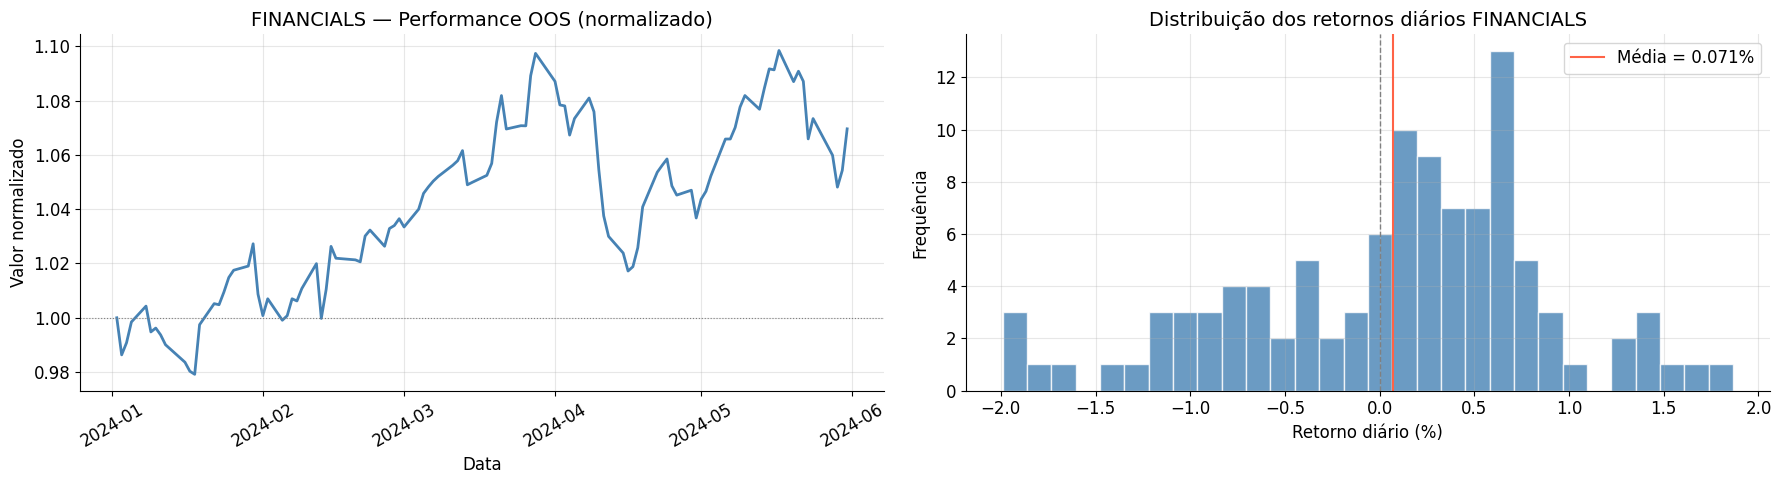

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_healthcare.pdf


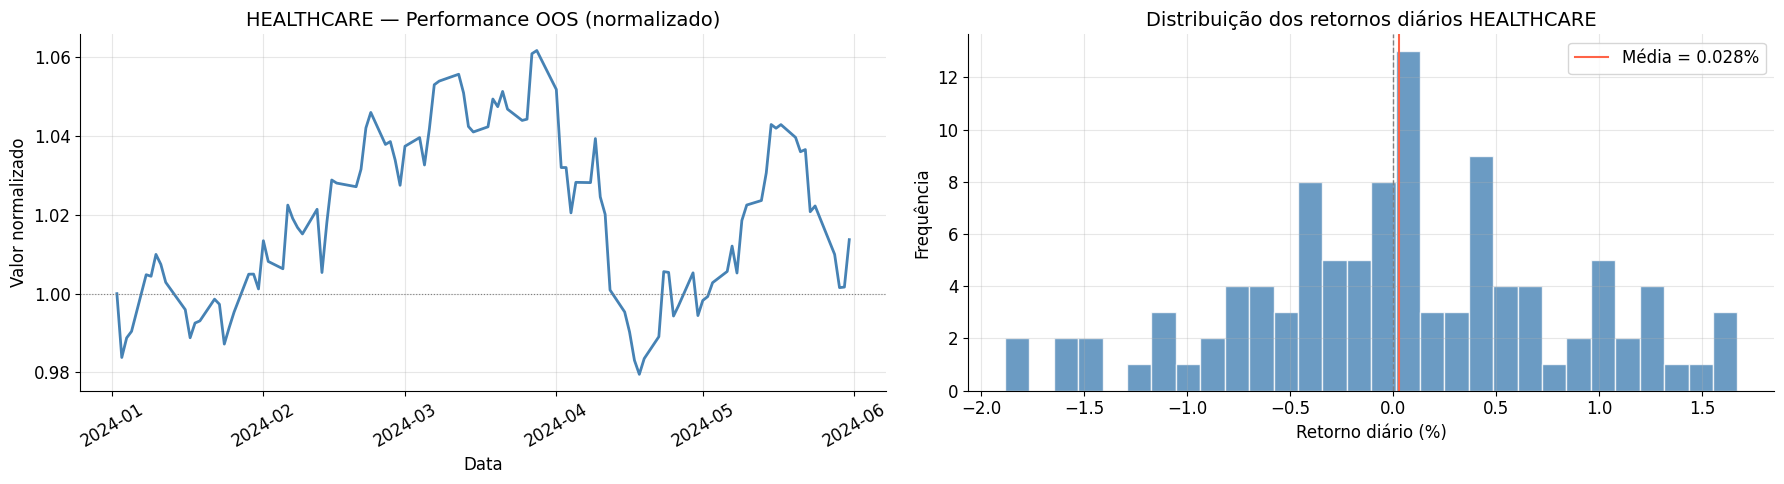

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_industrials.pdf


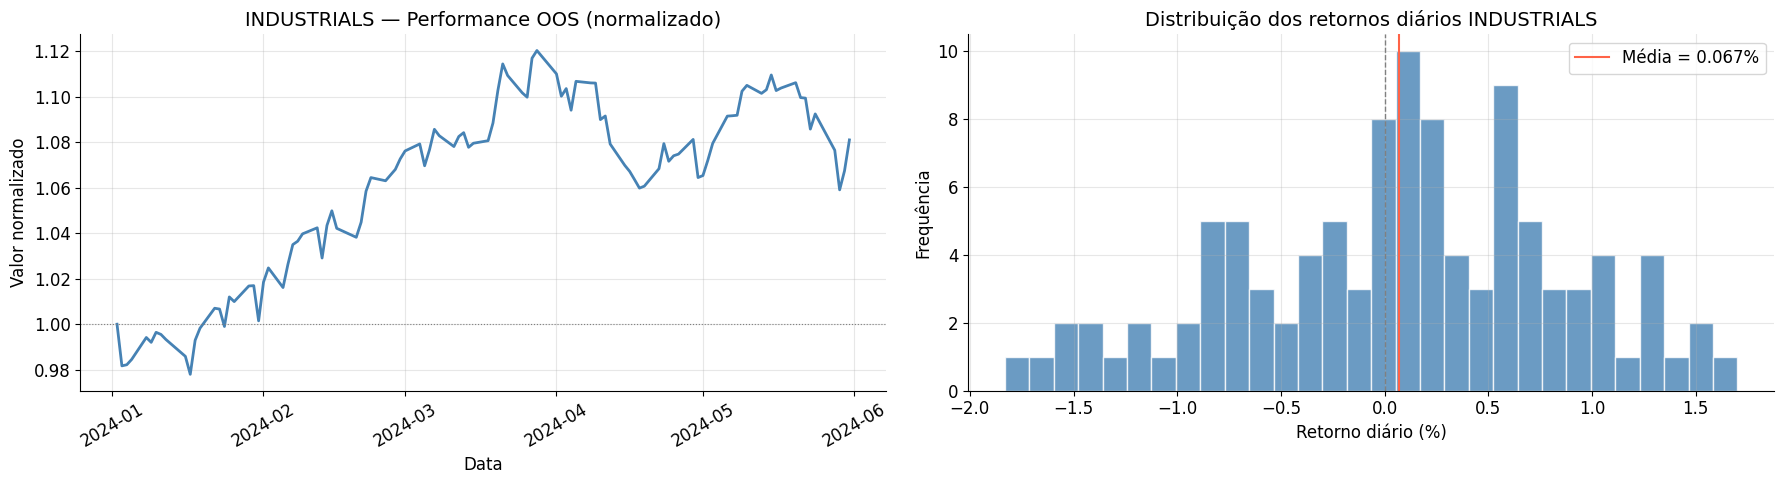

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_real_estate.pdf


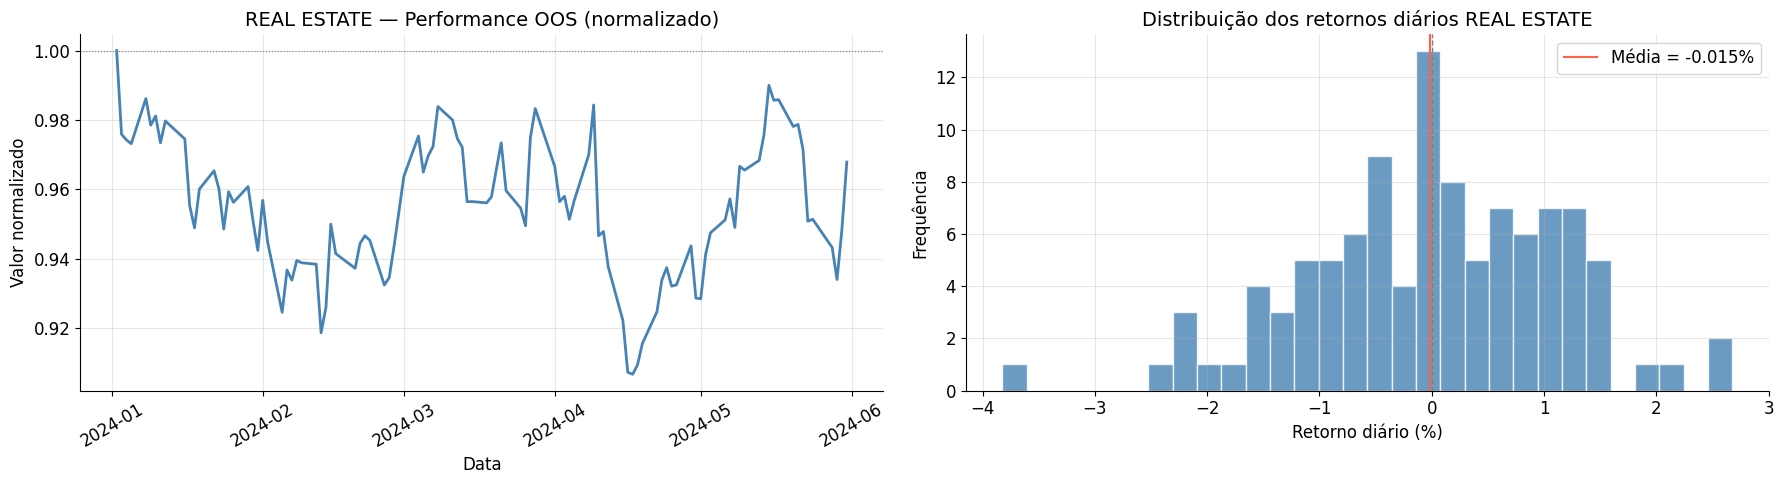

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_technology.pdf


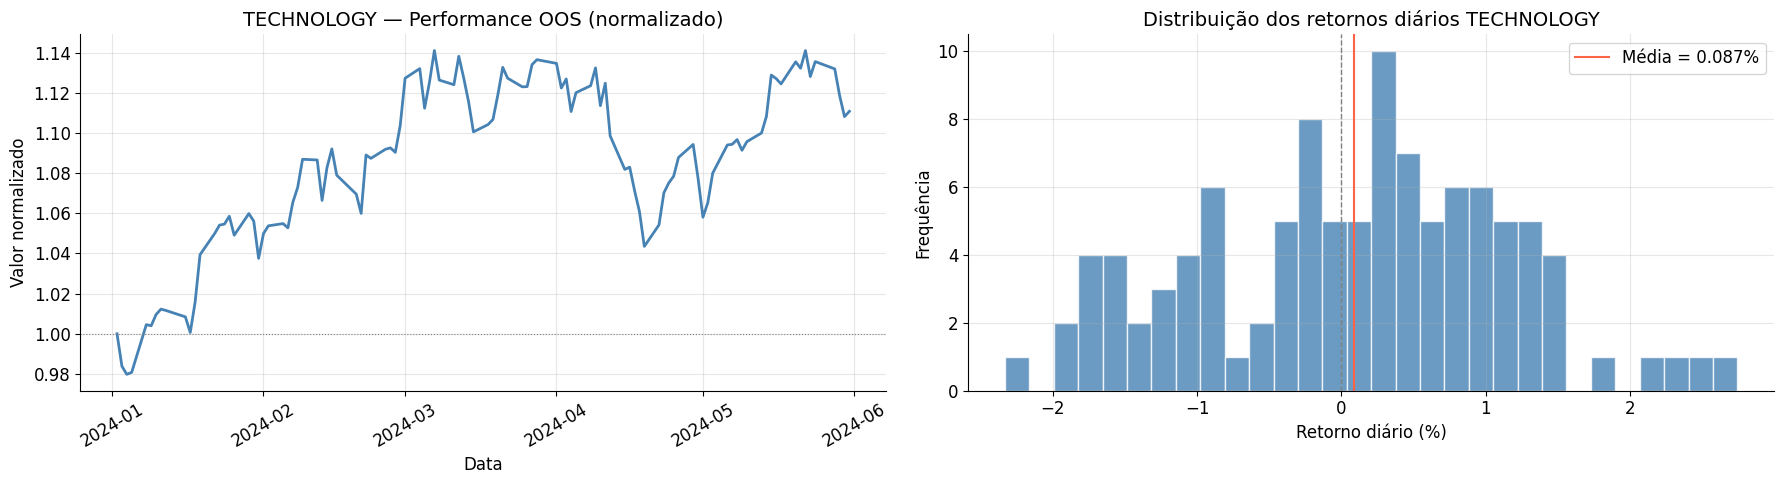

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_telecommunications_services.pdf


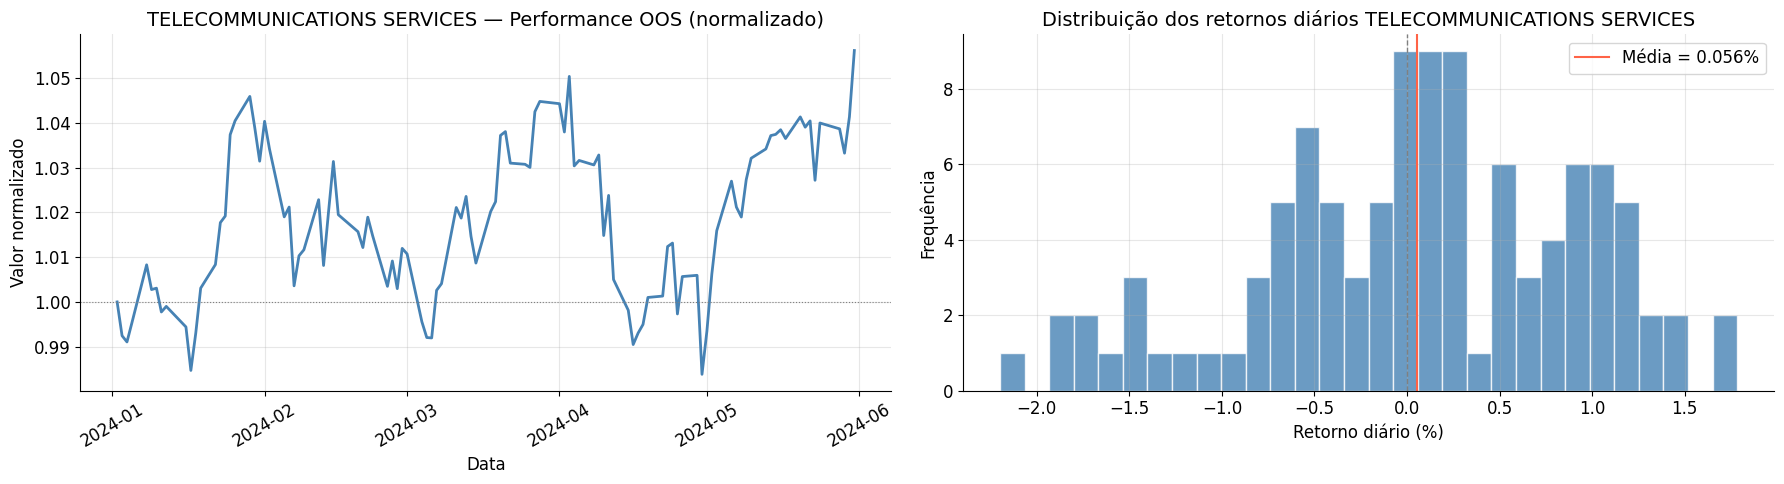

[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/market_context_utilities.pdf


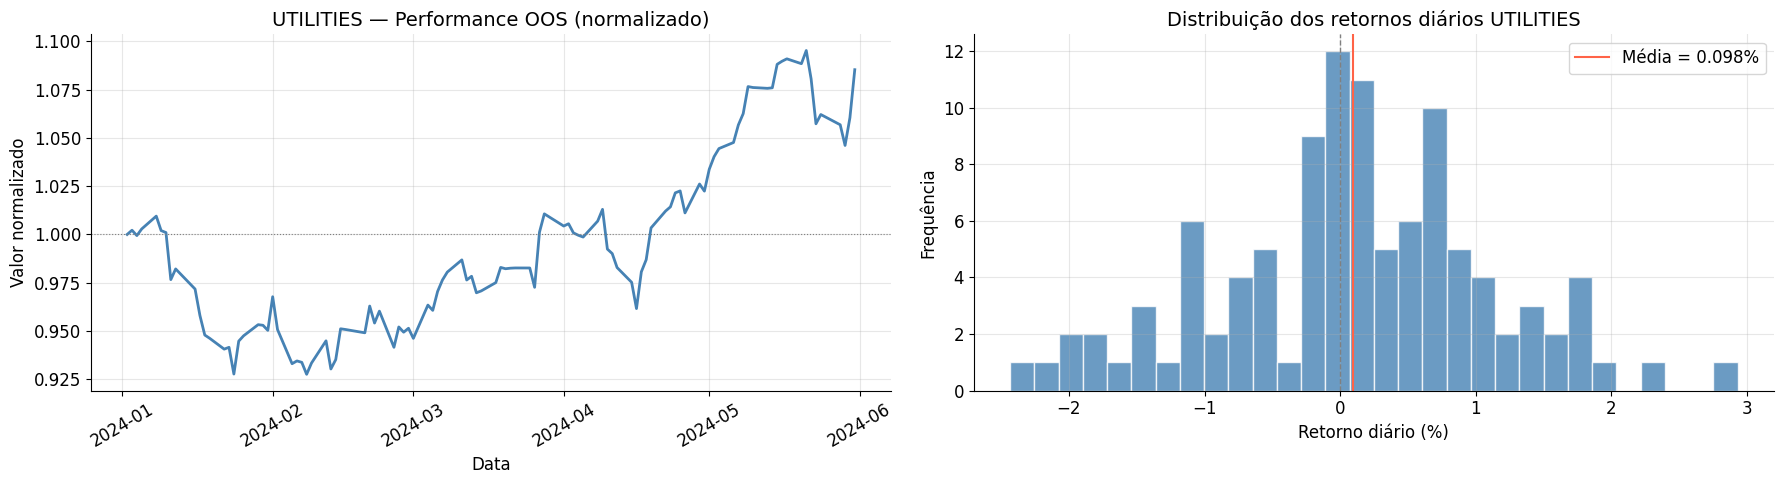

In [6]:
for sector in AVAILABLE_SECTORS:
    plot_market_context(
        sector_oos[sector]['norm'], sector_oos[sector]['ret'],
        benchmark_name=sector.replace('_', ' '),
        save_path=SECTORS_DIR_OUT / f'market_context_{sector.lower()}.pdf',
    )


**Individual market context per sector**

Each panel combines the normalized series with the daily return distribution of a sector. Sectors with fat tails in their returns create the most demanding SSD constraints: the portfolio must accumulate sufficient returns even in the worst scenarios of that sector, so that the cumulative integral of the portfolio's sorted returns dominates the corresponding integral of the sector. Sectors with a pronounced positive trend in the OOS period are the most likely candidates to have been the binding constraint of the Synthetic Benchmark in some training window. Sectors with persistently negative returns (series below 1.0) were rarely binding — the portfolio dominated them by a wide margin, making their SSD constraints virtually inactive during optimization.

---


---
## 3b. Dominant sector per OOS day
---


In [7]:
ret_df   = pd.DataFrame({s: sector_oos[s]['ret'] for s in AVAILABLE_SECTORS}).reindex(idx)
dom_day  = ret_df.idxmax(axis=1)

print('Daily dominance frequency (which sector has the highest return on each OOS day):')
for s, n in dom_day.value_counts().items():
    print(f'  {s:<38}  {n:3d} days  ({n/len(idx)*100:.1f}%)')


Daily dominance frequency (which sector has the highest return on each OOS day):
  ENERGY                                   23 days  (21.9%)
  TECHNOLOGY                               22 days  (21.0%)
  UTILITIES                                16 days  (15.2%)
  CONSUMER_NON_CYCLICALS                    9 days  (8.6%)
  CONSUMER_CYCLICALS                        8 days  (7.6%)
  REAL_ESTATE                               8 days  (7.6%)
  BASIC_MATERIALS                           6 days  (5.7%)
  FINANCIALS                                5 days  (4.8%)
  TELECOMMUNICATIONS_SERVICES               4 days  (3.8%)
  HEALTHCARE                                3 days  (2.9%)
  INDUSTRIALS                               1 days  (1.0%)


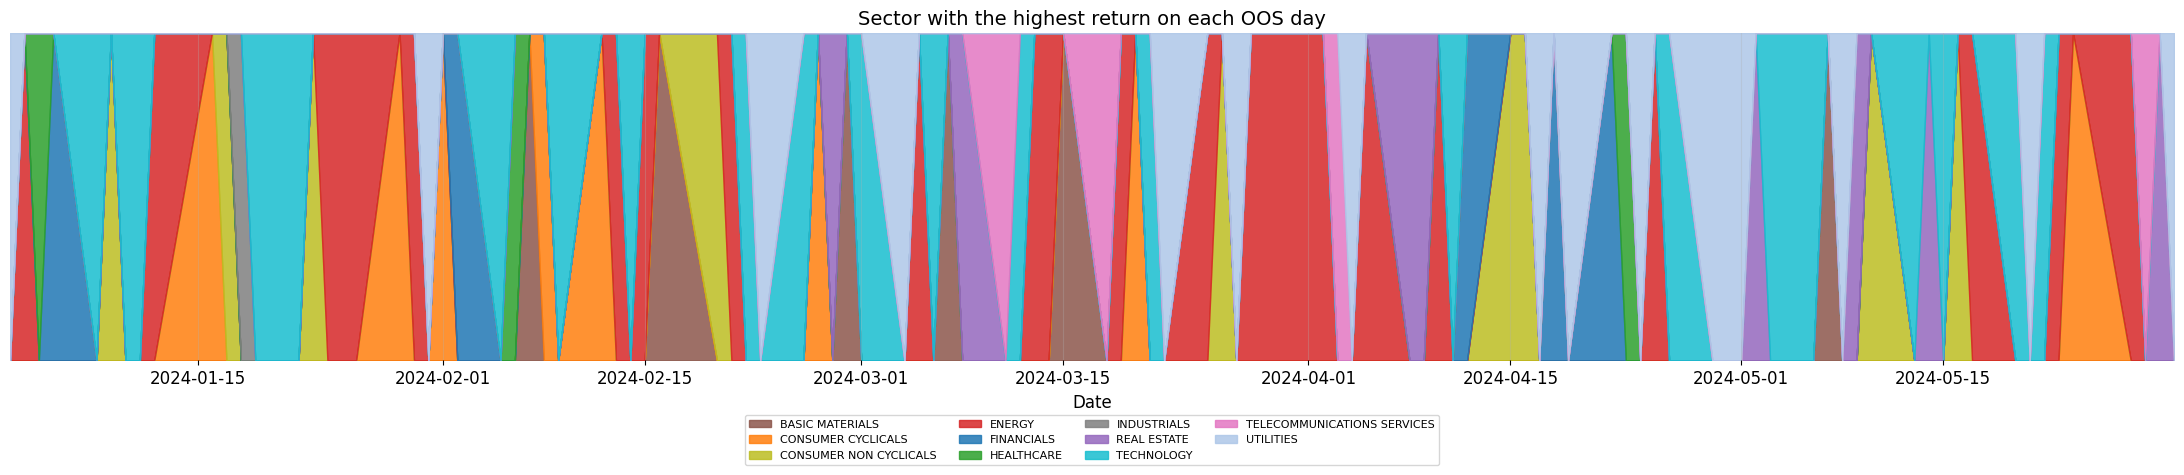

In [8]:
# Stacked area chart showing daily dominance
fig, ax = plt.subplots(figsize=(22, 5))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

bottom = np.zeros(len(idx))
for sector in AVAILABLE_SECTORS:
    mask = (dom_day == sector).astype(float).values
    ax.fill_between(idx, bottom, bottom + mask,
                    color=SECTOR_PALETTE[sector], alpha=0.85,
                    label=sector.replace('_', ' '))
    bottom += mask

ax.set_xlim(idx[0], idx[-1])
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_title('Sector with the highest return on each OOS day', fontsize=14)
ax.set_xlabel('Date')
ax.legend(fontsize=8, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.15))
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'dominant_sector_daily.pdf', bbox_inches='tight')
plt.show()


**Dominant sector per OOS day**

The stacked area chart reveals which sector had the highest return on each day of the OOS period, determining which component "pulled" the Synthetic Benchmark up on that day. When a single sector dominates an extended portion of the period (uniform color block), the Synthetic Benchmark is in practice mono-sectoral in the OOS — and the portfolio was essentially pressured by that specific benchmark. High fragmentation of colors indicates that leadership rotates among sectors: the Synthetic Benchmark is genuinely multi-sectoral, making SSD dominance harder to guarantee across the full distribution. Sectors with more than 40% of the days (as printed in the previous cell) tend to be the binding constraints during the walk-forward. Abrupt transitions in the dominant sector frequently coincide with market events — sectoral shocks, style rotations — that the model could not anticipate in-sample, which is a point of concern for OOS robustness.

---


---
## 4. Synthetic Benchmark OOS — detailed analysis

The OOS synthetic benchmark uses the same formulation as in-sample: τ_oos[s] = max_k(Tail_{s/S_k}(I_k)) over the OOS sector returns; the implied returns diff(S·τ) are dated by quantile matching against the cross-sector mean return.
In-sample, `synth_tau` (= max_k Tail) and the implied returns `synth_abs` are saved in `synthetic_bench-*.csv`.

---


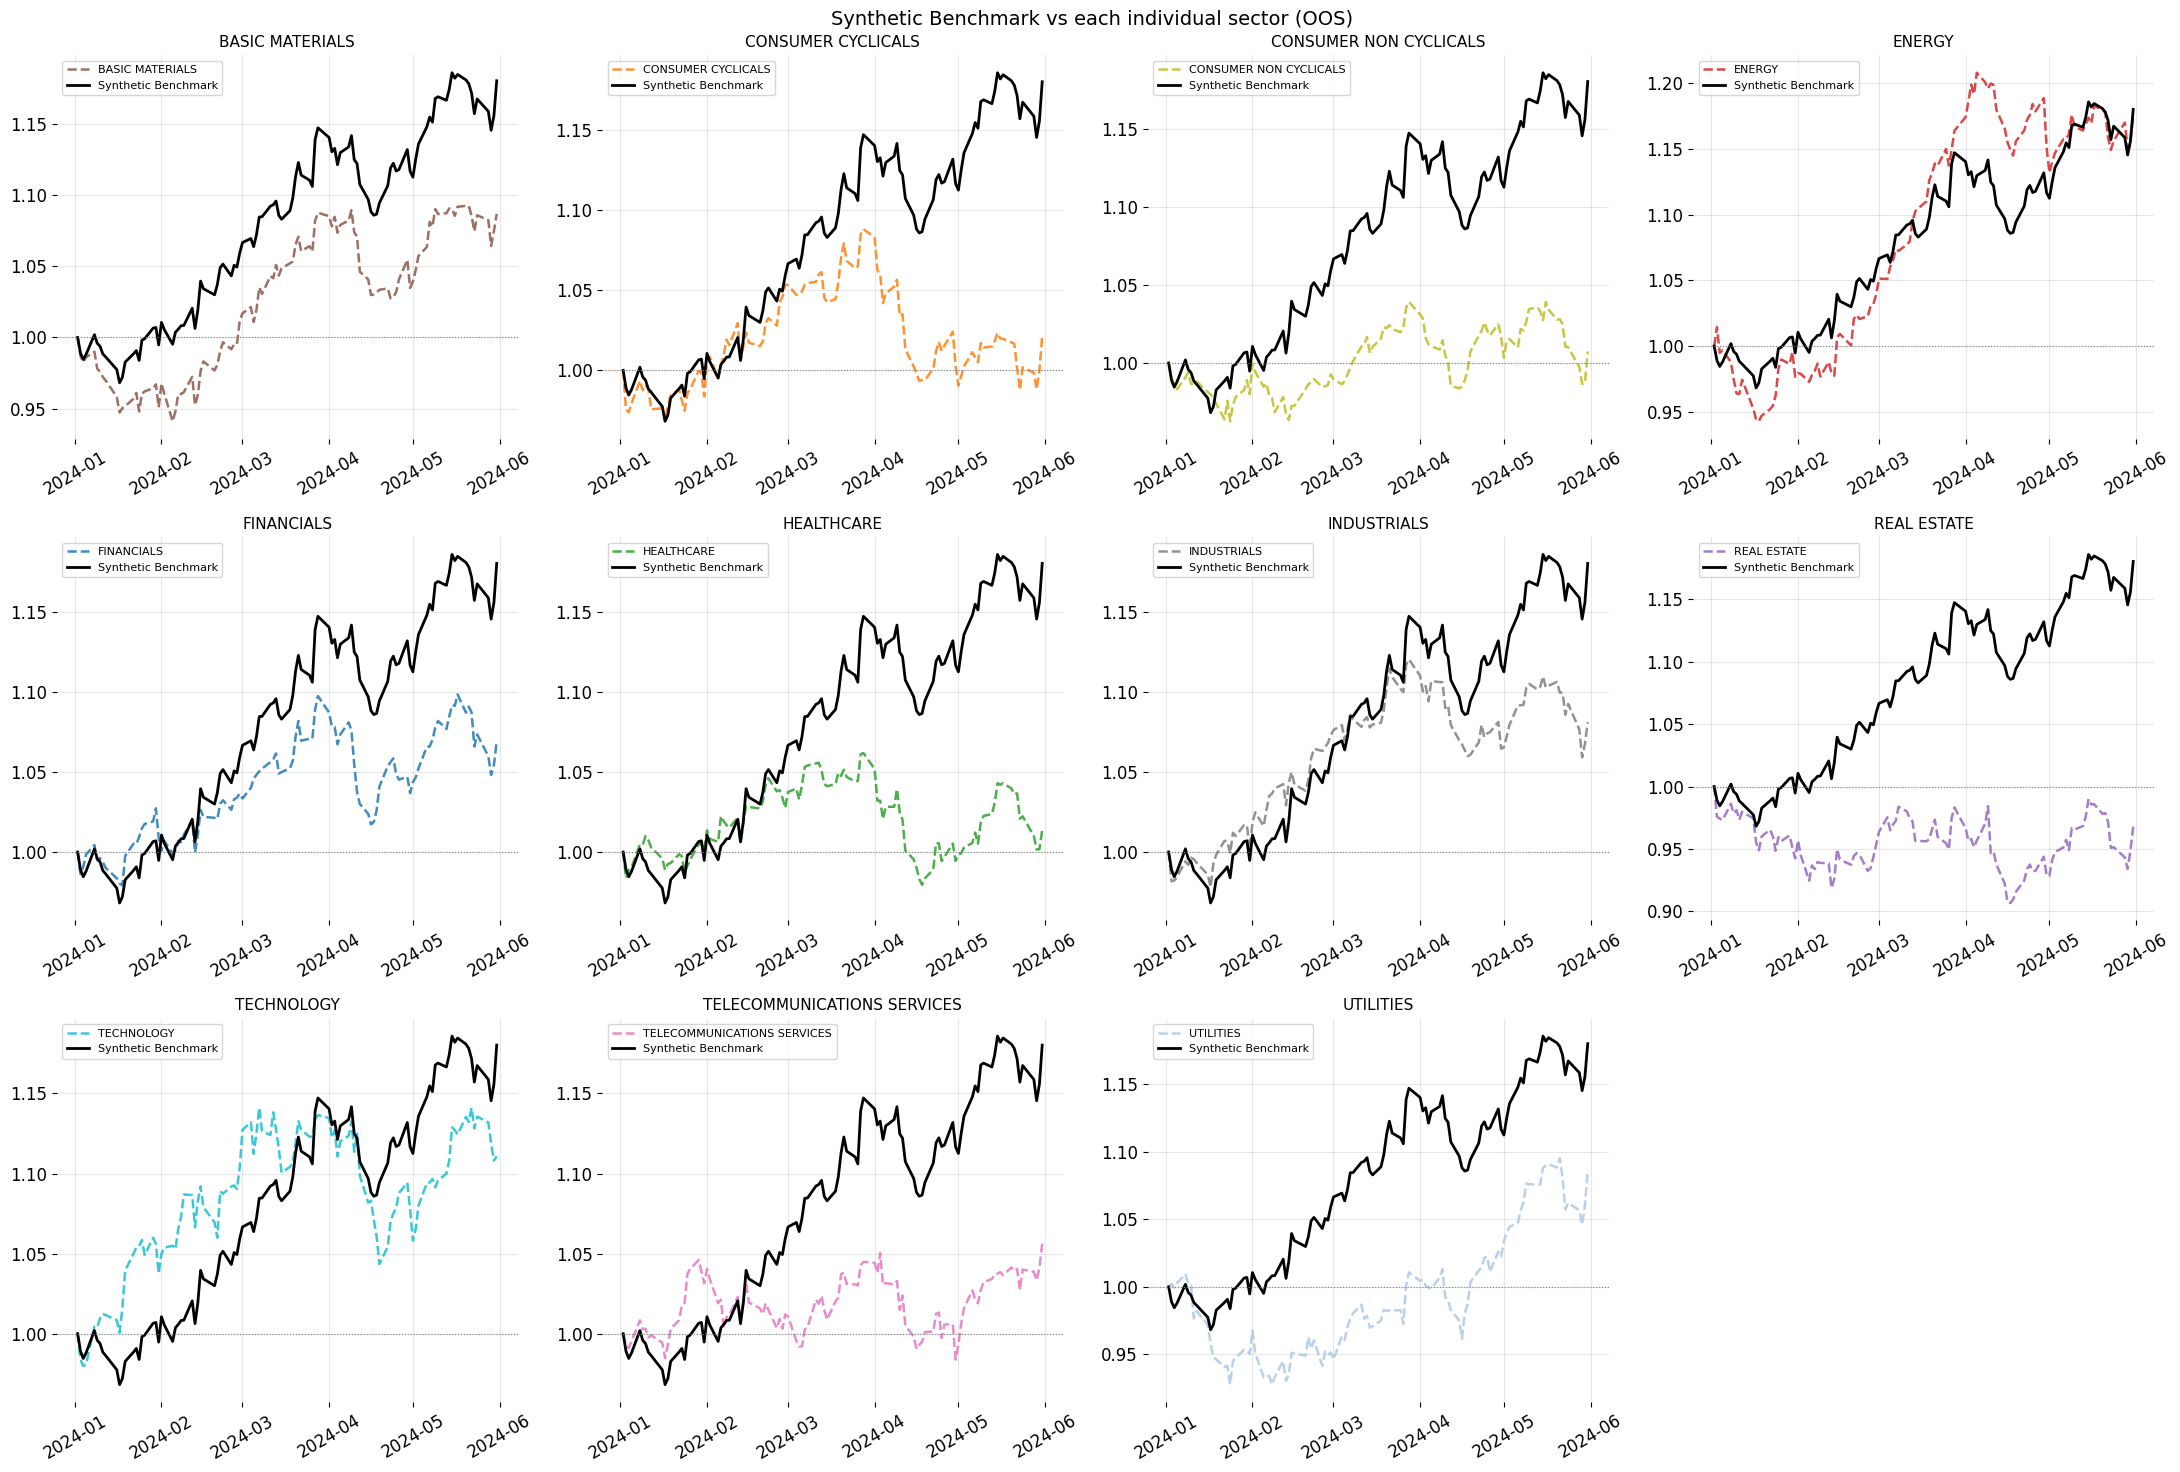

In [9]:
# Synthetic vs each sector (grid 3x4)
n_sectors = len(AVAILABLE_SECTORS)
n_cols_g  = 4
n_rows_g  = (n_sectors + n_cols_g - 1) // n_cols_g

fig, axes = plt.subplots(n_rows_g, n_cols_g, figsize=(22, n_rows_g * 5))
fig.patch.set_facecolor('white')
axes_flat = axes.flatten()

for i, sector in enumerate(AVAILABLE_SECTORS):
    ax = axes_flat[i]; ax.set_facecolor('white')
    norm  = sector_oos[sector]['norm']
    color = SECTOR_PALETTE[sector]
    ax.plot(norm.index, norm.values, color=color, linewidth=1.8, linestyle='--', alpha=0.85,
            label=sector.replace('_', ' '))
    ax.plot(synth_oos.index, synth_oos.values, color='black', linewidth=2.0, label='Synthetic Benchmark')
    ax.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_title(sector.replace('_', ' '), fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.legend(fontsize=8)

for ax in axes_flat[n_sectors:]:
    ax.set_visible(False)

plt.suptitle('Synthetic Benchmark vs each individual sector (OOS)', fontsize=14)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'synthetic_vs_sectors.pdf', bbox_inches='tight')
plt.show()


**Synthetic Benchmark vs each individual sector**

Each panel makes explicit the "slack" the model needed to cover in order to guarantee SSD dominance: the vertical distance between the Synthetic Benchmark (black) and the individual sector (colored) represents how far that sector fell below the synthetic benchmark at each point in time. Panels where the sector stays close to the Synthetic Benchmark identify the model's binding constraints — sectors that frequently determined the LP constraint level and therefore most influenced portfolio composition. Sectors far below the Synthetic Benchmark were rarely binding and the model dominated them with margin. The shape of the Synthetic Benchmark curve is especially informative: an ascending trajectory concentrated in the first days of the OOS implies in-sample constraints calibrated for early gains, while a curve rising at the end indicates that the most demanding scenario materialized only at the close of the period.

---


5 training windows found



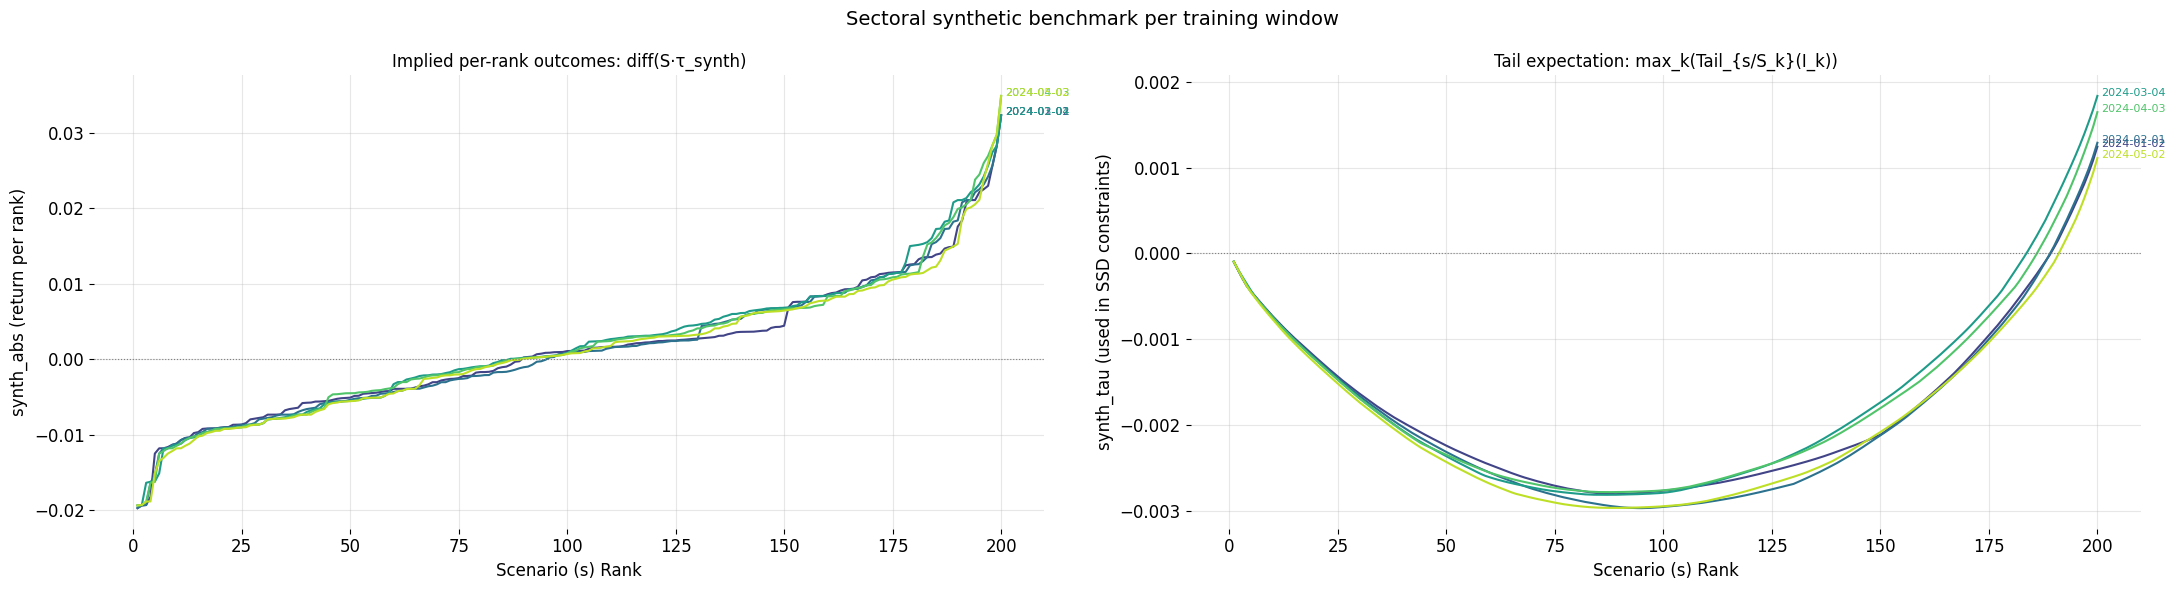

In [10]:
# Per-window synthetic benchmark curves
synth_files = sorted(SECTORS_DIR_OUT.glob('synthetic_bench-*.csv'))
print(f'{len(synth_files)} training windows found\n')

if synth_files:
    fig, axes = plt.subplots(1, 2, figsize=(22, 6))
    fig.patch.set_facecolor('white')
    colors_w = cm.viridis(np.linspace(0.2, 0.9, len(synth_files)))

    for color, f in zip(colors_w, synth_files):
        df   = pd.read_csv(f)
        date = f.stem.replace('synthetic_bench-', '')
        axes[0].plot(df['rank'], df['synth_abs'], linewidth=1.5, color=color)
        axes[1].plot(df['rank'], df['synth_tau'], linewidth=1.5, color=color)
        axes[0].annotate(date, xy=(df['rank'].iloc[-1], df['synth_abs'].iloc[-1]),
                         xytext=(3,0), textcoords='offset points', fontsize=8, color=color)
        axes[1].annotate(date, xy=(df['rank'].iloc[-1], df['synth_tau'].iloc[-1]),
                         xytext=(3,0), textcoords='offset points', fontsize=8, color=color)

    for ax, ttl, yl in zip(axes,
            ['Implied per-rank outcomes: diff(S·τ_synth)', 'Tail expectation: max_k(Tail_{s/S_k}(I_k))'],
            ['synth_abs (return per rank)', 'synth_tau (used in SSD constraints)']):
        ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
        ax.set_title(ttl, fontsize=12); ax.set_xlabel('Scenario (s) Rank')
        ax.set_ylabel(yl)
        for sp in ax.spines.values(): sp.set_visible(False)

    plt.suptitle('Sectoral synthetic benchmark per training window', fontsize=14)
    plt.tight_layout()
    plt.savefig(SECTORS_DIR_OUT / 'synthetic_bench_windows.pdf', bbox_inches='tight')
    plt.show()
else:
    print('[WARNING]: No synthetic_bench-*.csv file found. '
          'Run tafmSSD-sectors.py first.')


**Synthetic Benchmark per training window (absolute and cumulative curves)**

The left panel (`synth_abs`) shows the per-rank outcome implied by the synthetic envelope (first difference of the cumulative $S\cdot\tau_{\text{synth}}$) — from the worst to the best scenario within the training window. The right panel (`synth_tau`) displays the unconditional tail expectation, $\tau_{\text{synth}}[s] = \max_k(\mathrm{Tail}_{s/S^k})$, that enters directly into the LP's SSD constraints. Curves that cluster closely across distinct windows (overlapping viridis colors) indicate that the Synthetic Benchmark is stable over time, which favors consistency in the constraints at each rebalancing. The zero-crossing point in `synth_abs` delineates the boundary between loss and gain scenarios: a late crossing (many negative ranks) means that the worst scenarios of the Synthetic Benchmark concentrate significant losses, imposing very demanding constraints in the negative tails. The slope of `synth_tau` in the region of the worst ranks determines the "hardness" of the most difficult SSD constraints to satisfy — windows with a steep slope force the portfolio to maintain greater reserves of cumulative returns in downside scenarios. Divergence between windows signals qualitatively distinct market periods that generated different constraint structures for the solver.

---


---
## 5. Constraint tightness — τ_k per sector per training window

τ_k[s] = Tail_{s/S_k}(I_k) = (1/S_k)·cumsum(sorted(sector_k_returns))[s] for each sector k — the unconditional expectation of the s worst returns.
τ_synth[s] = max_k(τ_k[s]) — binding constraint at each rank s.

---


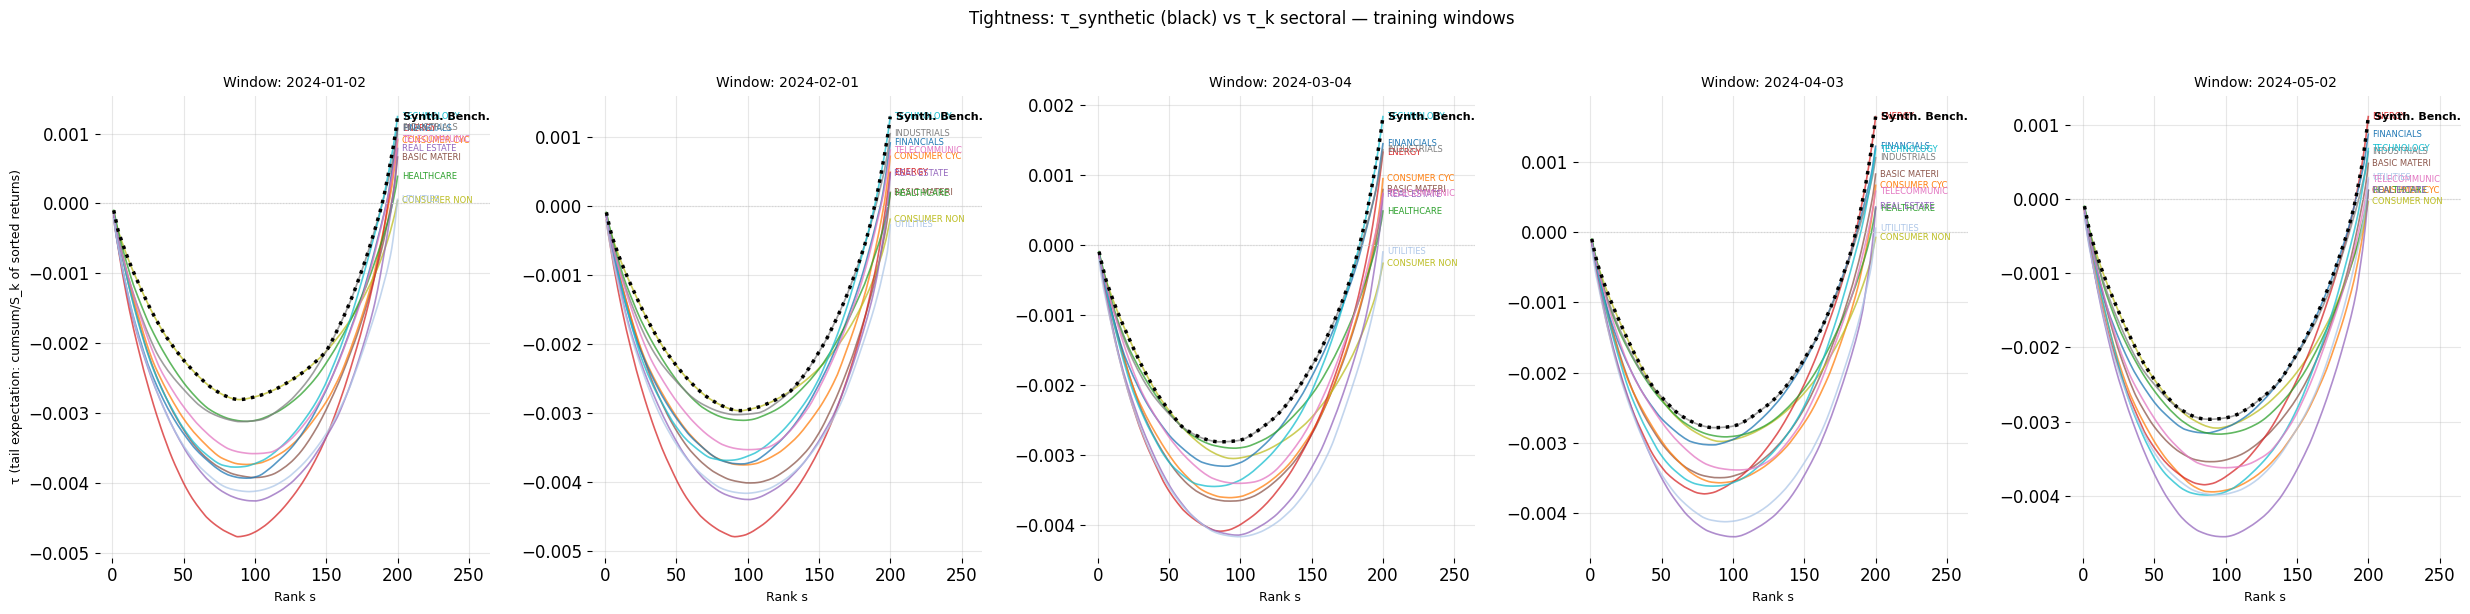

In [11]:
TRAIN_DAYS  = 200

synth_files = sorted(SECTORS_DIR_OUT.glob('synthetic_bench-*.csv'))
n_windows   = len(synth_files)

tau_by_window = {}

if n_windows > 0:
    fig, axes = plt.subplots(1, n_windows, figsize=(5 * n_windows, 6), sharey=False)
    if n_windows == 1:
        axes = [axes]
    fig.patch.set_facecolor('white')

    for ax, f in zip(axes, synth_files):
        date_str = f.stem.replace('synthetic_bench-', '')
        date     = pd.Timestamp(date_str)
        ax.set_facecolor('white')

        loc     = sector_returns.index.get_loc(date)
        train_b = sector_returns.iloc[max(0, loc - TRAIN_DAYS + 1): loc + 1]
        S       = len(train_b)
        ranks   = np.arange(1, S + 1)

        tau_matrix = {}
        for s in AVAILABLE_SECTORS:
            col = train_b[s].dropna()
            if len(col) > 0:
                tau_matrix[s] = np.cumsum(np.sort(col.values)) / len(col)
            else:
                tau_matrix[s] = np.zeros(S)

        tau_by_window[date_str] = tau_matrix
        synth_df = pd.read_csv(f)

        for sector, tau in tau_matrix.items():
            color = SECTOR_PALETTE[sector]
            ax.plot(ranks[:len(tau)], tau, linewidth=1.2, color=color, alpha=0.75)
            ax.annotate(sector.replace('_', ' ')[:12], xy=(ranks[len(tau)-1], tau[-1]),
                        xytext=(3, 0), textcoords='offset points',
                        va='center', fontsize=6, color=color)

        ax.plot(synth_df['rank'], synth_df['synth_tau'],
                linewidth=2.5, linestyle=':', color='black', zorder=5)
        ax.annotate('Synth. Bench.', xy=(synth_df['rank'].iloc[-1], synth_df['synth_tau'].iloc[-1]),
                    xytext=(4, 0), textcoords='offset points',
                    va='center', fontsize=8, color='black', fontweight='bold')

        ax.axhline(0, color='lightgray', linewidth=0.8, linestyle=':')
        x_min, x_max = ax.get_xlim()
        ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.25)
        ax.set_title(f'Window: {date_str}', fontsize=10)
        ax.set_xlabel('Rank s', fontsize=9)
        for sp in ax.spines.values(): sp.set_visible(False)

    axes[0].set_ylabel('τ (tail expectation: cumsum/S_k of sorted returns)', fontsize=9)
    fig.suptitle(
        'Tightness: τ_synthetic (black) vs τ_k sectoral — training windows',
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.savefig(SECTORS_DIR_OUT / 'constraint_tightness.pdf', bbox_inches='tight')
    plt.show()
else:
    print('[WARNING]: Run tafmSSD-sectors.py first.')


**Constraint tightness: τ_k per sector per training window**

For each training window, τ_k[s] = Tail_{s/S_k}(I_k) is the unconditional expectation of the s worst returns of sector k ((1/S_k)·Σ of the sorted returns), and τ_synth[s] = max_k(τ_k[s]) is the upper envelope that determines the LP's effective constraints. A narrow gap between τ_synth and a specific sector indicates that sector was the binding constraint for the corresponding ranks: small changes in its returns would shift the constraint level. The variation of the gap across ranks reveals whether a given sector is binding only in the tails (worst scenarios) or throughout the entire distribution — information relevant for understanding where the model concentrated its "optimization effort." τ_synth inevitably takes negative values at the first ranks (average of the worst returns), but the magnitude of this negativity matters: a very negative τ_synth in the tails makes the SSD constraints for the worst scenarios nearly intractable without sacrificing the middle ranks. Abrupt changes in τ_synth between consecutive windows signal instability in the constraints, which may translate into high portfolio turnover at each rebalancing.

---


---
## 6. Dominant sector by rank — which sector is binding at each rank s?
---


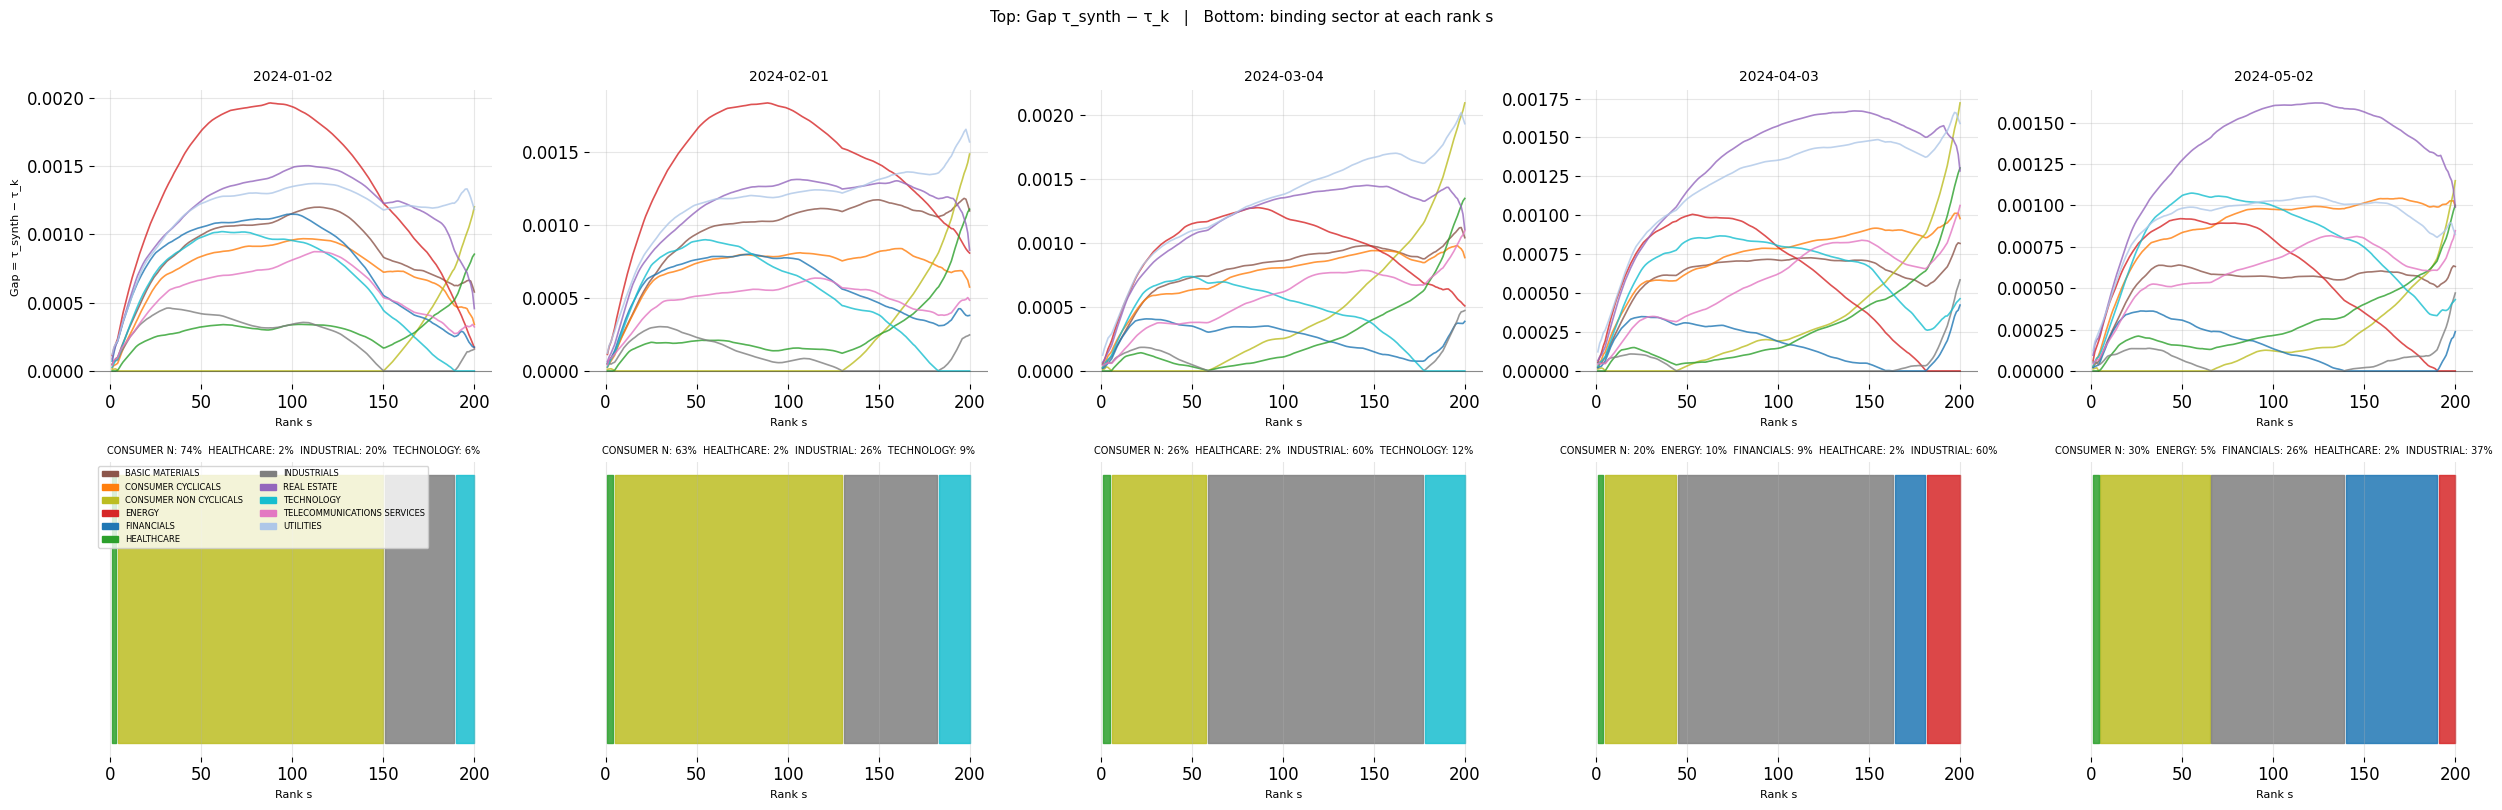

In [12]:
if tau_by_window:
    fig, axes = plt.subplots(2, n_windows, figsize=(5 * n_windows, 8))
    if n_windows == 1:
        axes = axes.reshape(2, 1)
    fig.patch.set_facecolor('white')

    for col_i, (f, date_str) in enumerate(
            [(f, f.stem.replace('synthetic_bench-', '')) for f in synth_files]):

        tau_matrix = tau_by_window[date_str]
        lens = [len(v) for v in tau_matrix.values()]
        S    = min(lens)
        stacked  = np.column_stack([tau_matrix[s][:S] for s in AVAILABLE_SECTORS])
        dom_idx  = np.argmax(stacked, axis=1)
        ranks    = np.arange(1, S + 1)
        synth_v  = stacked[np.arange(S), dom_idx]

        # Top: gap per sector
        ax_top = axes[0, col_i]; ax_top.set_facecolor('white')
        for i, sector in enumerate(AVAILABLE_SECTORS):
            gap = synth_v - stacked[:, i]
            ax_top.plot(ranks, gap, linewidth=1.2, color=SECTOR_PALETTE[sector], alpha=0.8)
        ax_top.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
        ax_top.set_title(date_str, fontsize=10)
        ax_top.set_xlabel('Rank s', fontsize=8)
        if col_i == 0:
            ax_top.set_ylabel('Gap = τ_synth − τ_k', fontsize=8)
        for sp in ax_top.spines.values(): sp.set_visible(False)

        # Bottom: color strip
        ax_bot = axes[1, col_i]; ax_bot.set_facecolor('white')
        for i, sector in enumerate(AVAILABLE_SECTORS):
            mask = (dom_idx == i)
            ax_bot.fill_between(ranks, 0, 1, where=mask,
                                color=SECTOR_PALETTE[sector], alpha=0.85)
        cnt     = Counter(int(j) for j in dom_idx)
        summary = '  '.join(
            f'{AVAILABLE_SECTORS[k].replace("_"," ")[:10]}: {cnt[k]/S*100:.0f}%'
            for k in sorted(cnt) if cnt[k] > 0
        )
        ax_bot.set_title(summary, fontsize=7)
        ax_bot.set_xlabel('Rank s', fontsize=8)
        ax_bot.set_yticks([])
        for sp in ax_bot.spines.values(): sp.set_visible(False)

    # Legend on first bottom panel
    from matplotlib.patches import Patch
    legend_patches = [Patch(color=SECTOR_PALETTE[s], label=s.replace('_', ' '))
                      for s in AVAILABLE_SECTORS]
    axes[1, 0].legend(handles=legend_patches, fontsize=6, loc='upper left', ncol=2)

    fig.suptitle(
        'Top: Gap τ_synth − τ_k   |   Bottom: binding sector at each rank s',
        fontsize=11, y=1.01,
    )
    plt.tight_layout()
    plt.savefig(SECTORS_DIR_OUT / 'constraint_dominance_by_rank.pdf', bbox_inches='tight')
    plt.show()


**Dominant sector by rank s (which sector is binding at each rank)**

The upper panel (gap τ_synth − τ_k) and the lower panel (binding sector at each rank) reveal the internal structure of the Synthetic Benchmark in each training window. When the lower color panel displays a single sector dominating most ranks (wide blocks of a single color), the Synthetic Benchmark is effectively uni-sectoral for that window — equivalent in practice to optimizing against that sector in isolation. High fragmentation indicates a genuinely multi-sectoral Synthetic Benchmark: the portfolio must simultaneously defend against the worst scenarios of one sector and the best scenarios of another, making the optimization problem more complex. When multiple sectors compete for the binding position at the same rank (small gap in several sectors simultaneously), the Synthetic Benchmark is especially "hard" in that region of the distribution. Finally, variation in the dominant sector between consecutive windows explains abrupt changes in portfolio composition: at rebalancing, the solver is reacting to a qualitatively different constraint structure.

---


---
## 7. Overview — portfolio vs sectors
---


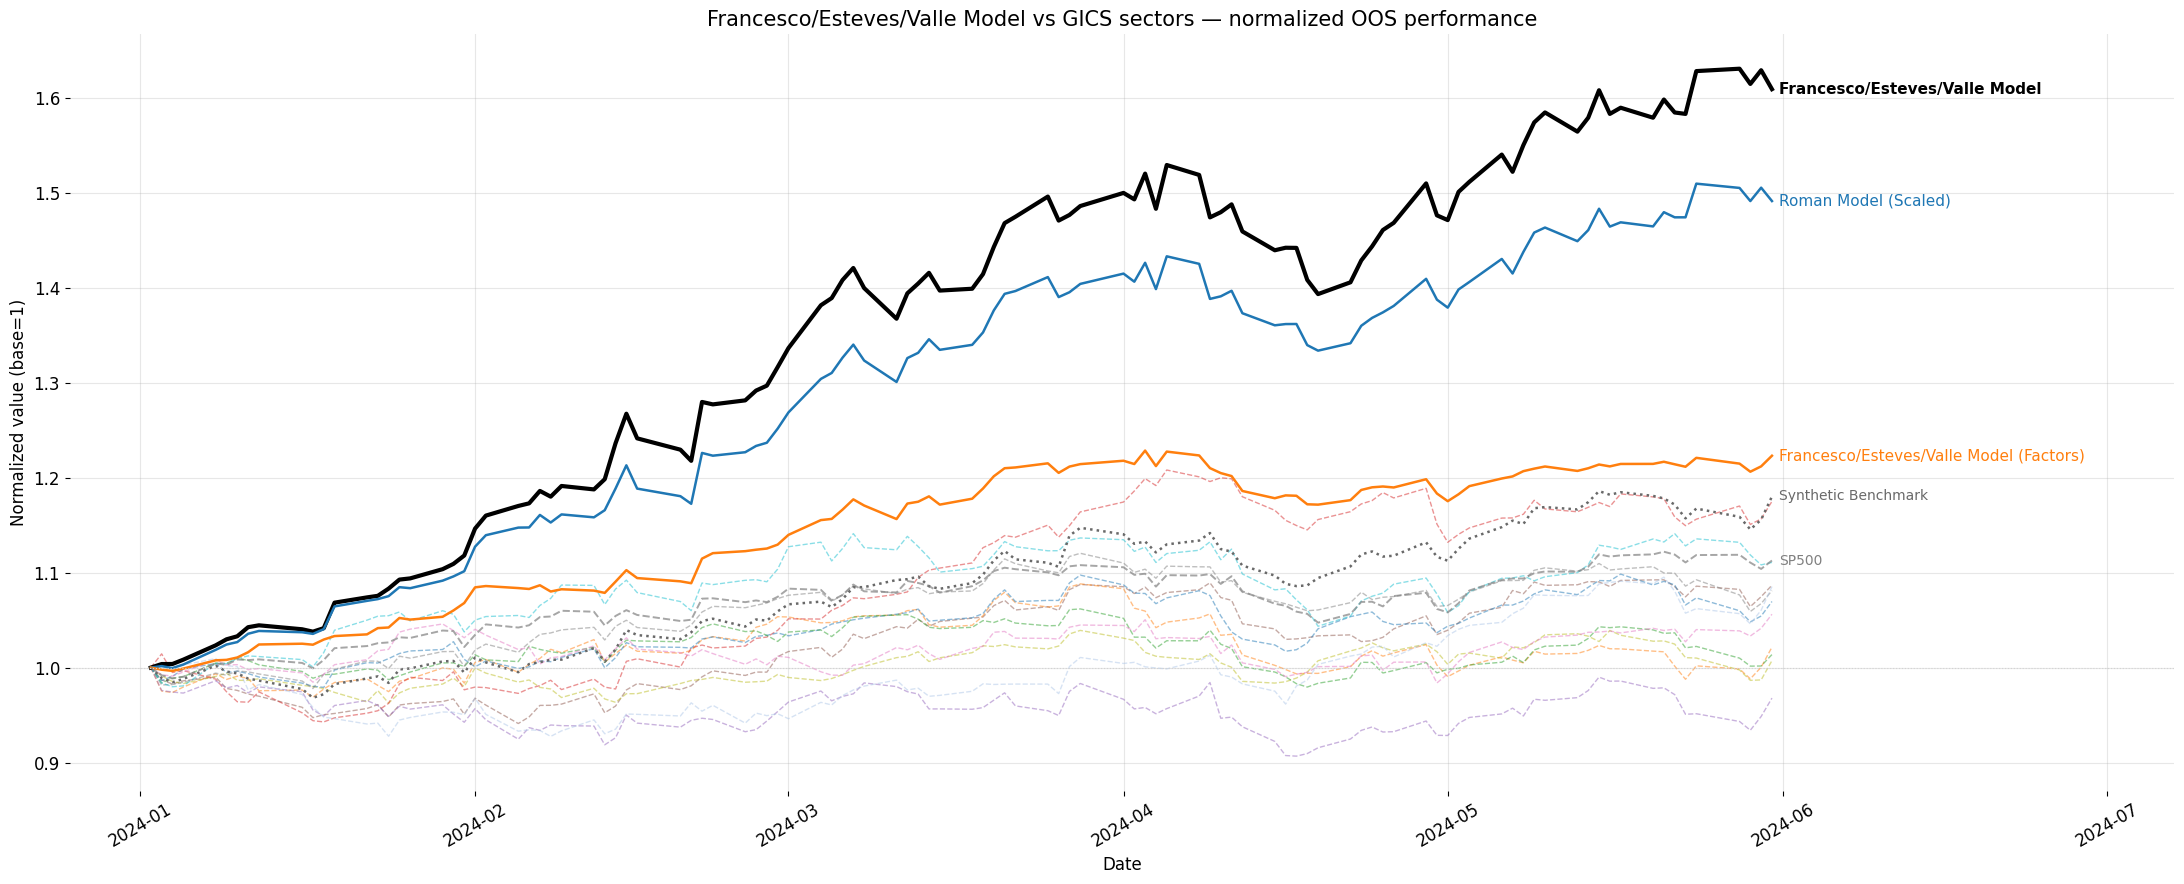

In [13]:
MODEL_COLORS = {
    'Francesco/Esteves/Valle Model': '#000000',
    'Roman Model (Scaled)':          '#1f77b4',
    'Francesco/Esteves/Valle Model (Factors)': '#ff7f0e',
}

fig, ax = plt.subplots(figsize=(22, 9))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

# Sector benchmarks (background, dashed)
for sector in AVAILABLE_SECTORS:
    norm  = sector_oos[sector]['norm']
    color = SECTOR_PALETTE[sector]
    ax.plot(norm.index, norm.values, linewidth=1.0, linestyle='--', color=color, alpha=0.5)

# Synthetic benchmark
ax.plot(synth_oos.index, synth_oos.values, linewidth=1.8, color='dimgray', linestyle=':')
ax.annotate('Synthetic Benchmark', xy=(synth_oos.index[-1], synth_oos.iloc[-1]),
            xytext=(5, 0), textcoords='offset points', va='center',
            fontsize=10, color='dimgray')

# Portfolio models (foreground, solid)
for label, series in models.items():
    color = MODEL_COLORS.get(label, '#999999')
    lw    = 3.0 if label == 'Francesco/Esteves/Valle Model' else 1.8
    ax.plot(idx, series.values, linewidth=lw, color=color, linestyle='-')
    ax.annotate(label, xy=(idx[-1], series.iloc[-1]),
                xytext=(5, 0), textcoords='offset points', va='center',
                fontsize=11, color=color,
                fontweight='bold' if label == 'Francesco/Esteves/Valle Model' else 'normal')

# SP500
ax.plot(sp500_norm.index, sp500_norm.values, linewidth=1.4, color='gray', linestyle='--', alpha=0.7)
ax.annotate('SP500', xy=(sp500_norm.index[-1], sp500_norm.iloc[-1]),
            xytext=(5, 0), textcoords='offset points', va='center',
            fontsize=10, color='gray')

ax.axhline(1.0, color='lightgray', linewidth=0.8, linestyle=':')
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min, x_max + (x_max - x_min) * 0.18)
ax.set_title('Francesco/Esteves/Valle Model vs GICS sectors — normalized OOS performance', fontsize=15)
ax.set_xlabel('Date'); ax.set_ylabel('Normalized value (base=1)')
ax.tick_params(axis='x', rotation=30)
for sp in ax.spines.values(): sp.set_visible(False)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'all_models_comparison.pdf', bbox_inches='tight')
plt.show()


**Overview: portfolio vs GICS sectors**

This chart consolidates the normalized performance of the Francesco/Esteves/Valle Model (thick black line) relative to all 11 sectors and the Synthetic Benchmark, and is the most important visualization of the experiment. The relative position of the portfolio with respect to the set of sectors is the primary evidence of the model's OOS validity: a trajectory consistently above the sectoral median confirms that in-sample SSD dominance transferred to the test period. The distance between the portfolio and the Synthetic Benchmark (theoretical ceiling) measures the combined cost of diversification and simultaneous satisfaction of all SSD constraints — an inevitable gap in the multi-benchmark approach. The comparison with the Roman Model (Scaled) and the FEV Model (Factors) allows isolating the effect of benchmark choice: significant differences between the three portfolios indicate that the type of benchmark substantially alters the optimization process and the resulting weights, while similar trajectories suggest robustness of the SSD approach regardless of the chosen benchmark.

---


---
## 8. Comparative drawdown
---


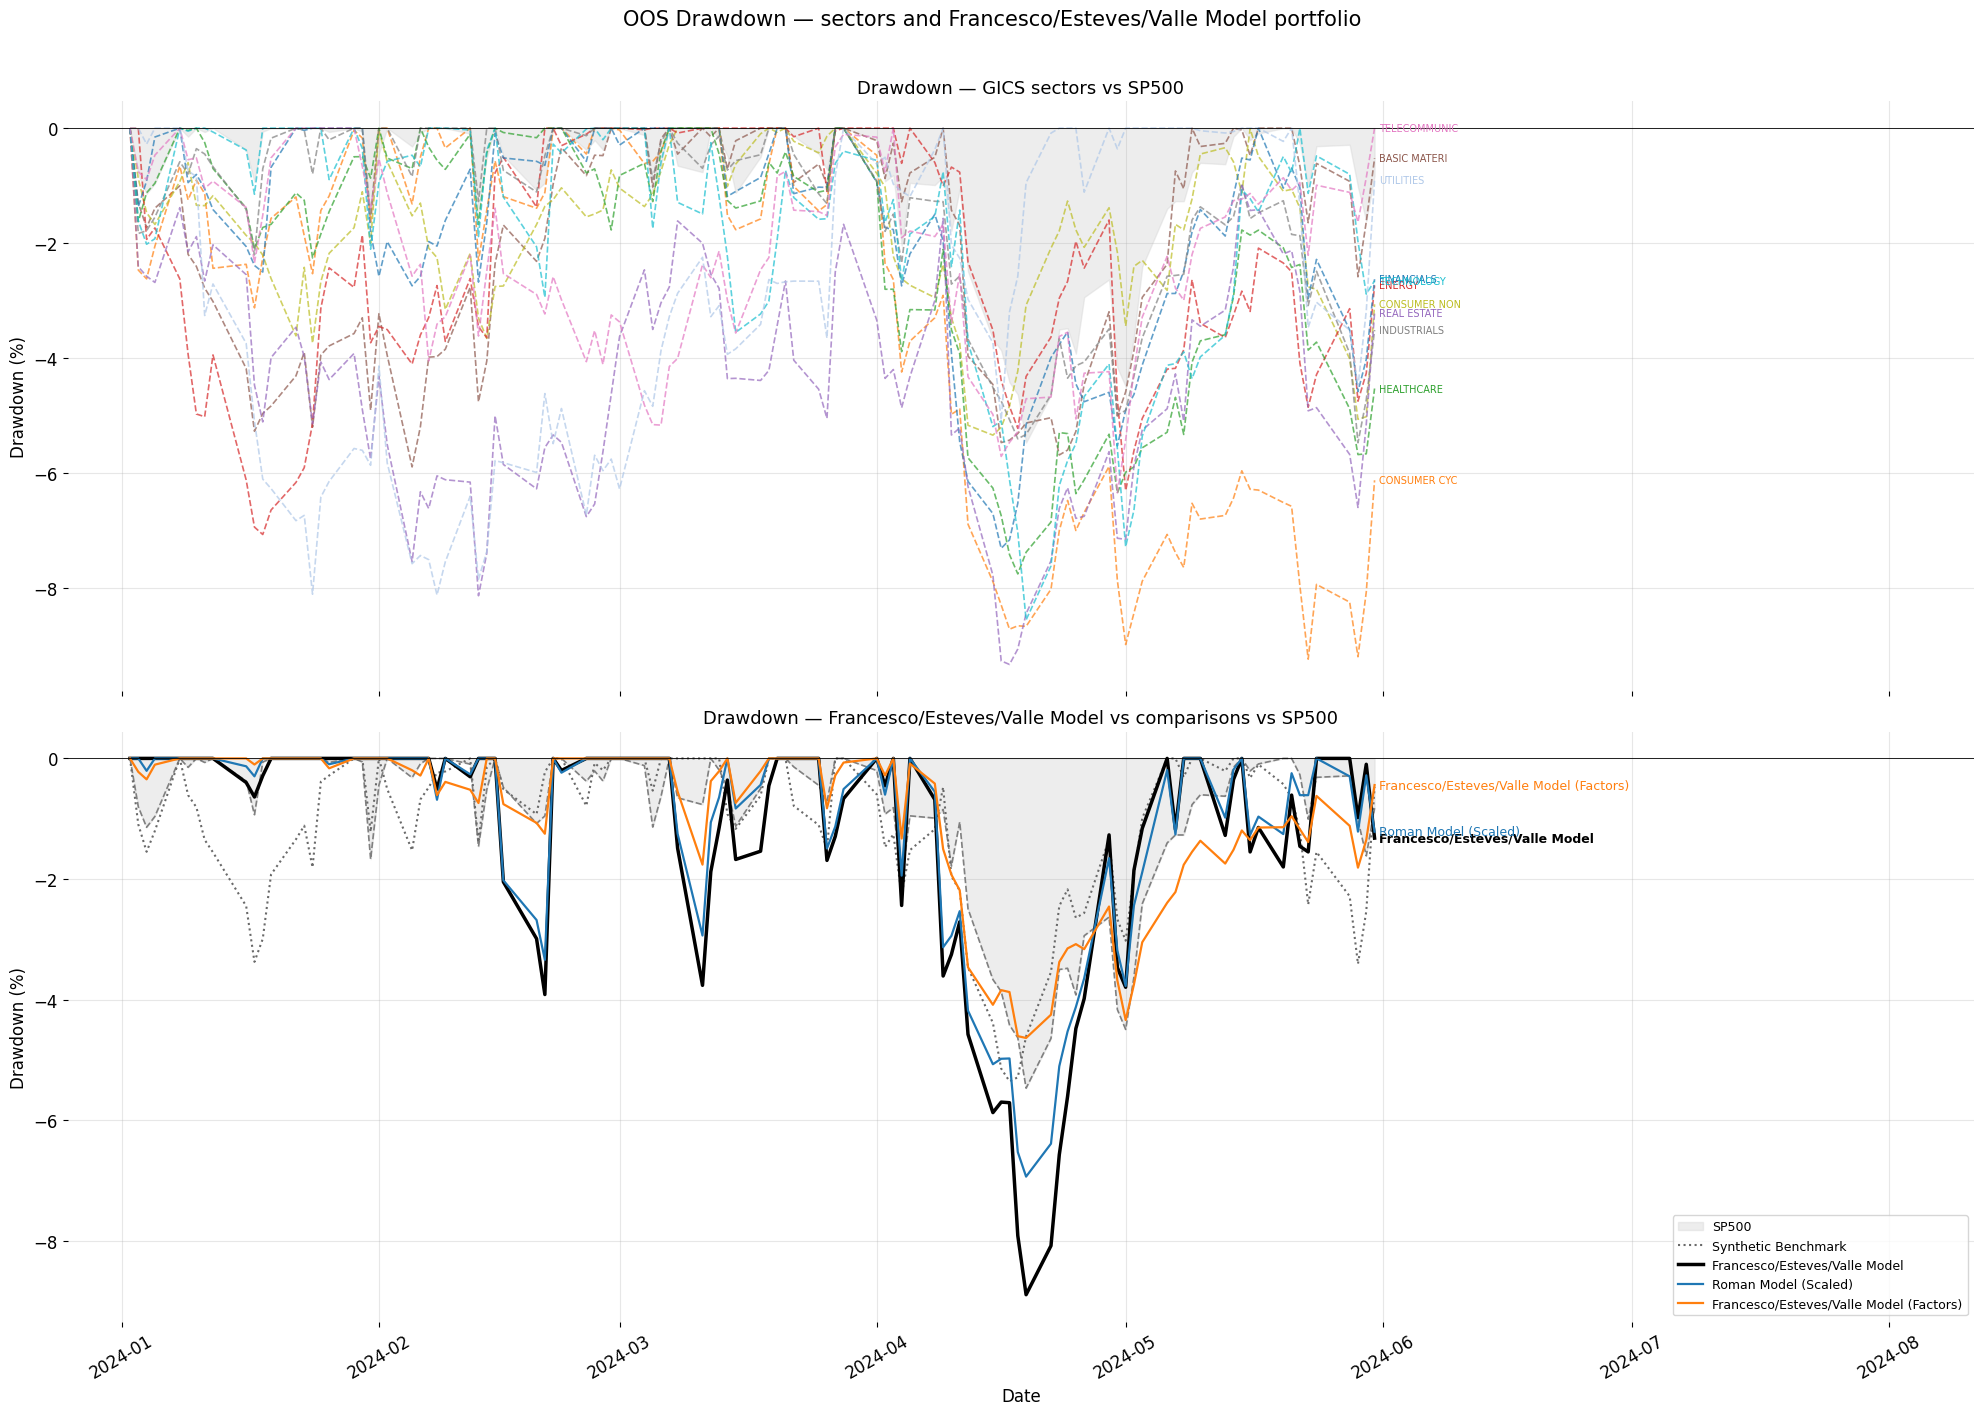

In [14]:
def compute_drawdown(series):
    roll_max = series.expanding().max()
    return (series / roll_max - 1) * 100

sp500_dd = compute_drawdown(sp500_norm)

fig, axes = plt.subplots(2, 1, figsize=(20, 14), sharex=True)
fig.patch.set_facecolor('white')

# Panel 1: sector benchmarks drawdown
ax1 = axes[0]; ax1.set_facecolor('white')
ax1.fill_between(idx, sp500_dd.values, 0, color='lightgray', alpha=0.4, label='SP500')
for sector in AVAILABLE_SECTORS:
    norm  = sector_oos[sector]['norm'].reindex(idx)
    dd    = compute_drawdown(norm)
    ax1.plot(idx, dd.values, linewidth=1.2, linestyle='--',
             color=SECTOR_PALETTE[sector], alpha=0.7)
    ax1.annotate(sector.replace('_', ' ')[:12], xy=(idx[-1], dd.iloc[-1]),
                 xytext=(3, 0), textcoords='offset points', va='center',
                 fontsize=7, color=SECTOR_PALETTE[sector])
ax1.axhline(0, color='black', linewidth=0.6)
ax1.set_title('Drawdown — GICS sectors vs SP500', fontsize=13)
ax1.set_ylabel('Drawdown (%)')
x_min, x_max = ax1.get_xlim()
ax1.set_xlim(x_min, x_max + (x_max - x_min) * 0.18)
for sp in ax1.spines.values(): sp.set_visible(False)

# Panel 2: portfolio drawdown
ax2 = axes[1]; ax2.set_facecolor('white')
ax2.fill_between(idx, sp500_dd.values, 0, color='lightgray', alpha=0.4, label='SP500')
ax2.plot(idx, sp500_dd.values, color='gray', linewidth=1.2, linestyle='--')

synth_dd = compute_drawdown(synth_oos)
ax2.plot(idx, synth_dd.values, linewidth=1.5, linestyle=':', color='dimgray', label='Synthetic Benchmark')

for label, series in models.items():
    color = MODEL_COLORS.get(label, '#999999')
    lw    = 2.5 if label == 'Francesco/Esteves/Valle Model' else 1.6
    dd    = compute_drawdown(series.reindex(idx))
    ax2.plot(idx, dd.values, linewidth=lw, color=color, label=label)
    ax2.annotate(label, xy=(idx[-1], dd.iloc[-1]), xytext=(3, 0),
                 textcoords='offset points', va='center', fontsize=9, color=color,
                 fontweight='bold' if label == 'Francesco/Esteves/Valle Model' else 'normal')

ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_title('Drawdown — Francesco/Esteves/Valle Model vs comparisons vs SP500', fontsize=13)
ax2.set_ylabel('Drawdown (%)'); ax2.set_xlabel('Date')
ax2.legend(fontsize=9, loc='lower right')
ax2.tick_params(axis='x', rotation=30)
x_min, x_max = ax2.get_xlim()
ax2.set_xlim(x_min, x_max + (x_max - x_min) * 0.18)
for sp in ax2.spines.values(): sp.set_visible(False)

plt.suptitle('OOS Drawdown — sectors and Francesco/Esteves/Valle Model portfolio', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'drawdown_comparison.pdf', bbox_inches='tight')
plt.show()


**Comparative drawdown**

The upper panel shows the drawdowns of the 11 sectors individually, providing the downside context of the benchmark universe. The lower panel compares the models with each other and with the Synthetic Benchmark. A portfolio optimized via SSD should exhibit smaller drawdowns than most individual sectors: the in-sample SSD dominance requirement forces diversification that tends to smooth out declines, though without an explicit maximum drawdown guarantee (this is not the objective of the formulation). The recovery speed after a drawdown is as informative as the depth: fast recoveries indicate a portfolio well-positioned to capture subsequent upside. The correlation of drawdowns between models is particularly relevant — simultaneous occurrence of maximum drawdowns in the Francesco/Esteves/Valle Model and the Roman Model suggests the event was systemic (independent of the benchmark), while divergence between the two models' drawdowns indicates that the choice of sectoral vs. SP500 benchmark makes a concrete difference in OOS downside behavior.

---


---
## 9. OOS metrics — complete table
---


In [15]:
rows = {}
rows['SP500']     = compute_metrics(sp500_norm, benchmark=sp500_norm, rf_annual=RISK_FREE)
rows['Synthetic Benchmark'] = compute_metrics(synth_oos,  benchmark=sp500_norm, rf_annual=RISK_FREE)

for label, series in models.items():
    rows[label] = compute_metrics(series.reindex(idx), benchmark=sp500_norm, rf_annual=RISK_FREE)

for sector in AVAILABLE_SECTORS:
    norm = sector_oos[sector]['norm'].reindex(idx)
    rows[sector.replace('_', ' ')] = compute_metrics(norm, benchmark=sp500_norm, rf_annual=RISK_FREE)

metrics_df = pd.DataFrame(rows).T
display(
    metrics_df.style
    .background_gradient(cmap='RdYlGn',
        subset=['Final value', 'CAGR (%)', 'Sharpe Ratio', 'Sortino Ratio'])
    .background_gradient(cmap='RdYlGn_r',
        subset=['Volatility (%)', 'Daily CVaR 5% (%)', 'Max Drawdown (%)'])
    .format(precision=4, na_rep='--')
)


,Final value,CAGR (%),Volatility (%),Daily CVaR 5% (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Portfolio beta
SP500,1.1127,29.5400,11.3400,1.4070,1.9096,3.5279,-5.4600,1.0000
Synthetic Benchmark,1.1802,49.3900,13.9100,1.3310,2.6066,7.3038,-5.3500,0.9013
Francesco/Esteves/Valle Model,1.6089,216.5500,22.0700,2.3830,5.1204,16.9911,-8.8900,1.1691
Roman Model (Scaled),1.4911,163.2900,18.2900,1.9300,5.1260,15.2550,-6.9300,1.0043
Francesco/Esteves/Valle Model (Factors),1.2230,62.8800,10.2900,1.1700,4.3224,9.3841,-4.6300,0.6071
BASIC MATERIALS,1.0867,22.3300,14.4600,1.9300,1.1288,1.8106,-5.8900,0.7860
CONSUMER CYCLICALS,1.0215,5.3000,15.3700,2.1660,0.0949,0.0273,-9.2300,1.0009
CONSUMER NON CYCLICALS,1.0073,1.7900,11.7300,1.3310,-0.2070,-0.4966,-5.3400,0.3211
ENERGY,1.1750,47.8000,15.8100,2.0990,2.2436,3.8203,-7.0600,0.5442
FINANCIALS,1.0696,17.7000,13.0200,1.7820,0.9421,1.3990,-7.3000,0.6215


**OOS metrics (complete table)**

The table consolidates the key performance metrics for all models, benchmarks, and sectors in the OOS period. The color gradient (red → yellow → green) facilitates identification of outliers. The Sharpe Ratio and Sortino Ratio are the most relevant risk-adjusted metrics: in-sample SSD dominance should imply Sharpe ≥ benchmark, but this is only guaranteed in distribution and only in-sample — OOS is the real test. The difference between Sharpe and Sortino (which penalizes only downside) reveals whether the portfolio has asymmetric risk: a Sortino much higher than Sharpe confirms less downside than upside, consistent with SSD optimization. Daily CVaR 5% measures the expected loss on the 5% worst days — less negative values confirm downside protection. A portfolio with lower CAGR than the Synthetic Benchmark may still be preferable if it presents significantly lower volatility; Sharpe captures this trade-off directly. Beta against SP500 proxies the degree of systemic correlation: values below 1 are expected in SSD-optimized portfolios, which tend to reduce market exposure in favor of diversification.

---


---
## 10. SSD dominance
---


Francesco/Esteves/Valle Model vs Synthetic Benchmark: min(SSD) = -0.115770  ✗ VIOLATES
Roman Model (Scaled) vs SP500: min(SSD) = -0.074537  ✗ VIOLATES
Francesco/Esteves/Valle Model (Factors) vs SP500: min(SSD) = +0.002830  ✓ DOMINATES
[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/ssd_home_dominance.pdf


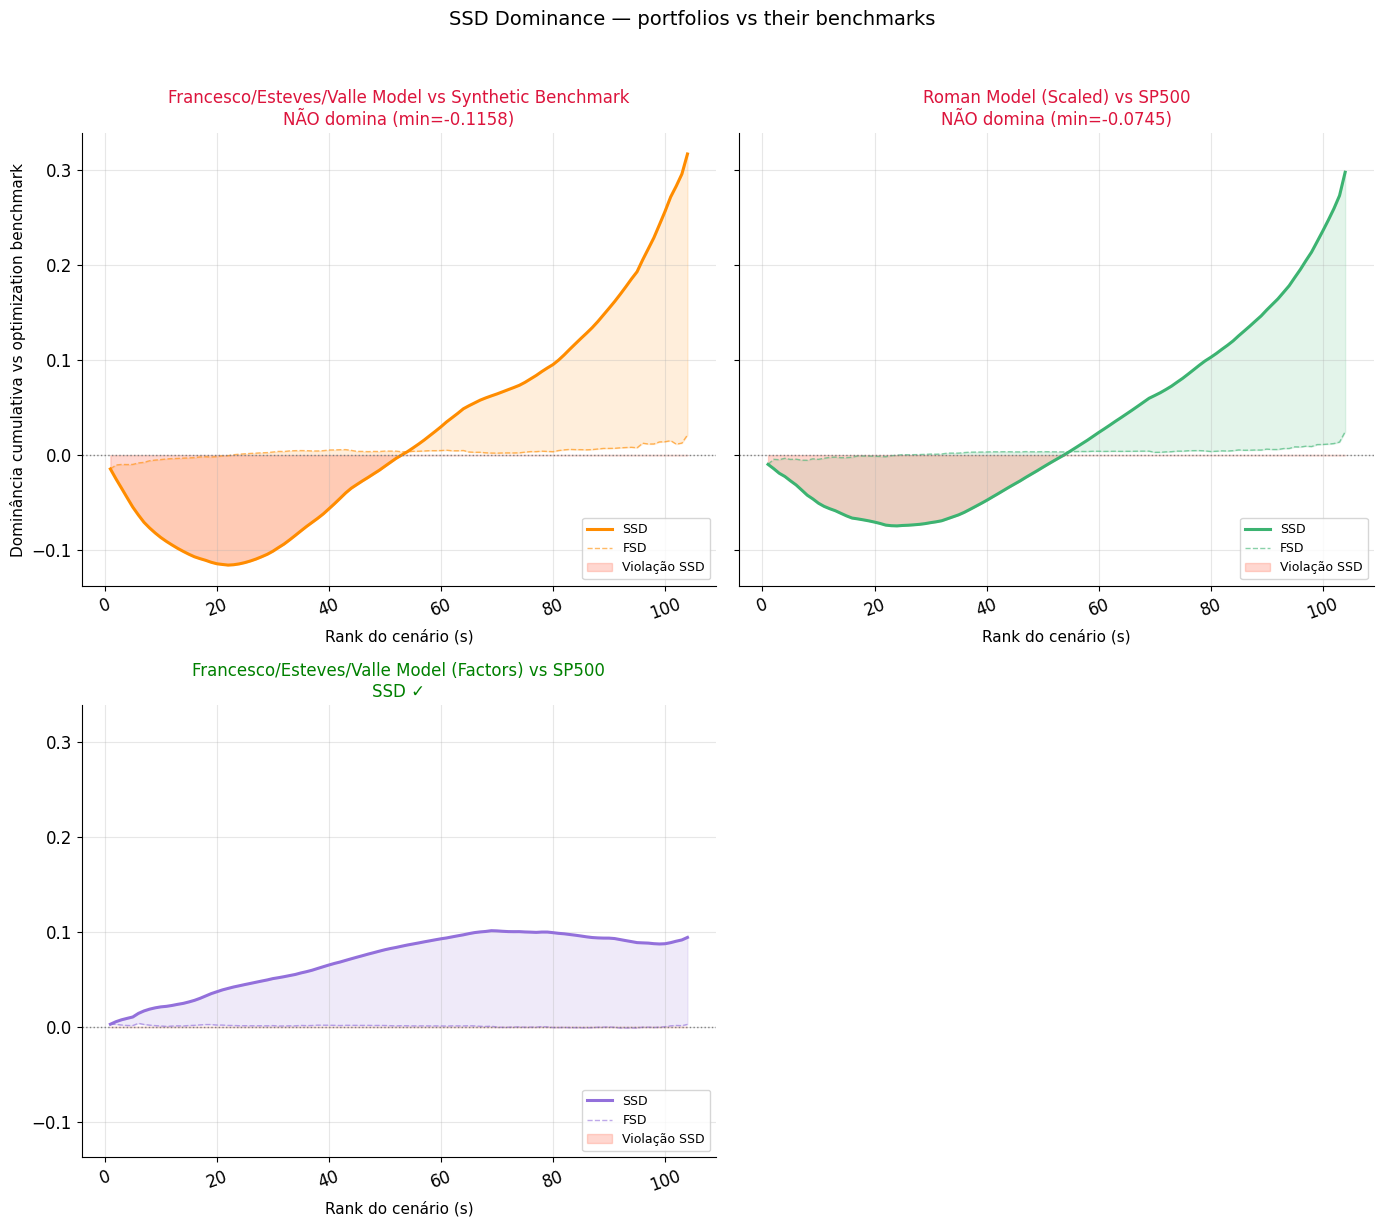

In [16]:
# Own-benchmark dominance: Francesco/Esteves/Valle Model vs synthetic sector benchmark
if 'Francesco/Esteves/Valle Model' in models:
    port_series = models['Francesco/Esteves/Valle Model'].reindex(idx)
    port_ret    = port_series.pct_change().dropna()
    synth_ret   = synth_oos.pct_change().dropna()
    common      = port_ret.index.intersection(synth_ret.index)
    s, fsd, ssd = compute_ssd_dominance(
        port_ret.loc[common].values, synth_ret.loc[common].values
    )
    tag = '✓ DOMINATES' if ssd.min() >= 0 else '✗ VIOLATES'
    print(f'Francesco/Esteves/Valle Model vs Synthetic Benchmark: min(SSD) = {ssd.min():+.6f}  {tag}')

    home_dom = {'Francesco/Esteves/Valle Model vs Synthetic Benchmark': (s, fsd, ssd)}

    # Also add comparison models vs SP500
    for label, series in models.items():
        if label == 'Francesco/Esteves/Valle Model':
            continue
        r_port = series.reindex(idx).pct_change().dropna()
        r_bench = sp500_ret.reindex(r_port.index).dropna()
        common2 = r_port.index.intersection(r_bench.index)
        s2, fsd2, ssd2 = compute_ssd_dominance(
            r_port.loc[common2].values, r_bench.loc[common2].values
        )
        home_dom[f'{label} vs SP500'] = (s2, fsd2, ssd2)
        tag2 = '✓ DOMINATES' if ssd2.min() >= 0 else '✗ VIOLATES'
        print(f'{label} vs SP500: min(SSD) = {ssd2.min():+.6f}  {tag2}')

    plot_dominance_panels(
        home_dom, n_cols=2,
        benchmark_name='optimization benchmark',
        title='SSD Dominance — portfolios vs their benchmarks',
        save_path=SECTORS_DIR_OUT / 'ssd_home_dominance.pdf',
    )


**SSD dominance: portfolios vs their optimization benchmarks**

This panel verifies whether each portfolio SSD-dominates its optimization benchmark in the OOS period. In-sample SSD dominance is guaranteed by the LP — the test here is generalization. For the Francesco/Esteves/Valle Model, the SSD curve should be ≥ 0 at all points to confirm OOS dominance against the sectoral Synthetic Benchmark; violations (negative regions) locate exactly where the benchmark outperformed the portfolio in the cumulative distribution. Violations in the left tails (worst scenarios) are the most concerning, as they indicate that the portfolio lost more than the benchmark on the worst OOS days — contrary to the fundamental objective of the formulation. Mild violations (min SSD close to zero) are acceptable given the temporal gap between in-sample and OOS. The comparison with the Roman Model (Scaled) vs SP500 provides the baseline: if the sectoral model shows OOS dominance similar to or better than the Roman Model, the use of sectoral benchmarks adds value without deteriorating the dominance property.

---



=== Francesco/Esteves/Valle Model: cross-dominance vs each sector ===
  Sector                                    min(SSD)    min(FSD)  Status
  ------------------------------------------------------------------------
  BASIC_MATERIALS                          -0.057552   -0.006333  ✗ VIOLATES
  CONSUMER_CYCLICALS                       -0.026649   -0.004765  ✗ VIOLATES
  CONSUMER_NON_CYCLICALS                   -0.115770   -0.014613  ✗ VIOLATES
  ENERGY                                   -0.047126   -0.005627  ✗ VIOLATES
  FINANCIALS                               -0.078432   -0.009530  ✗ VIOLATES
  HEALTHCARE                               -0.100124   -0.010578  ✗ VIOLATES
  INDUSTRIALS                              -0.100464   -0.011128  ✗ VIOLATES
  REAL_ESTATE                              +0.000250   -0.002238  ✓ DOMINATES
  TECHNOLOGY                               -0.035246   -0.006119  ✗ VIOLATES
  TELECOMMUNICATIONS_SERVICES              -0.072064   -0.007440  ✗ VIOLATES
  UTILITIE

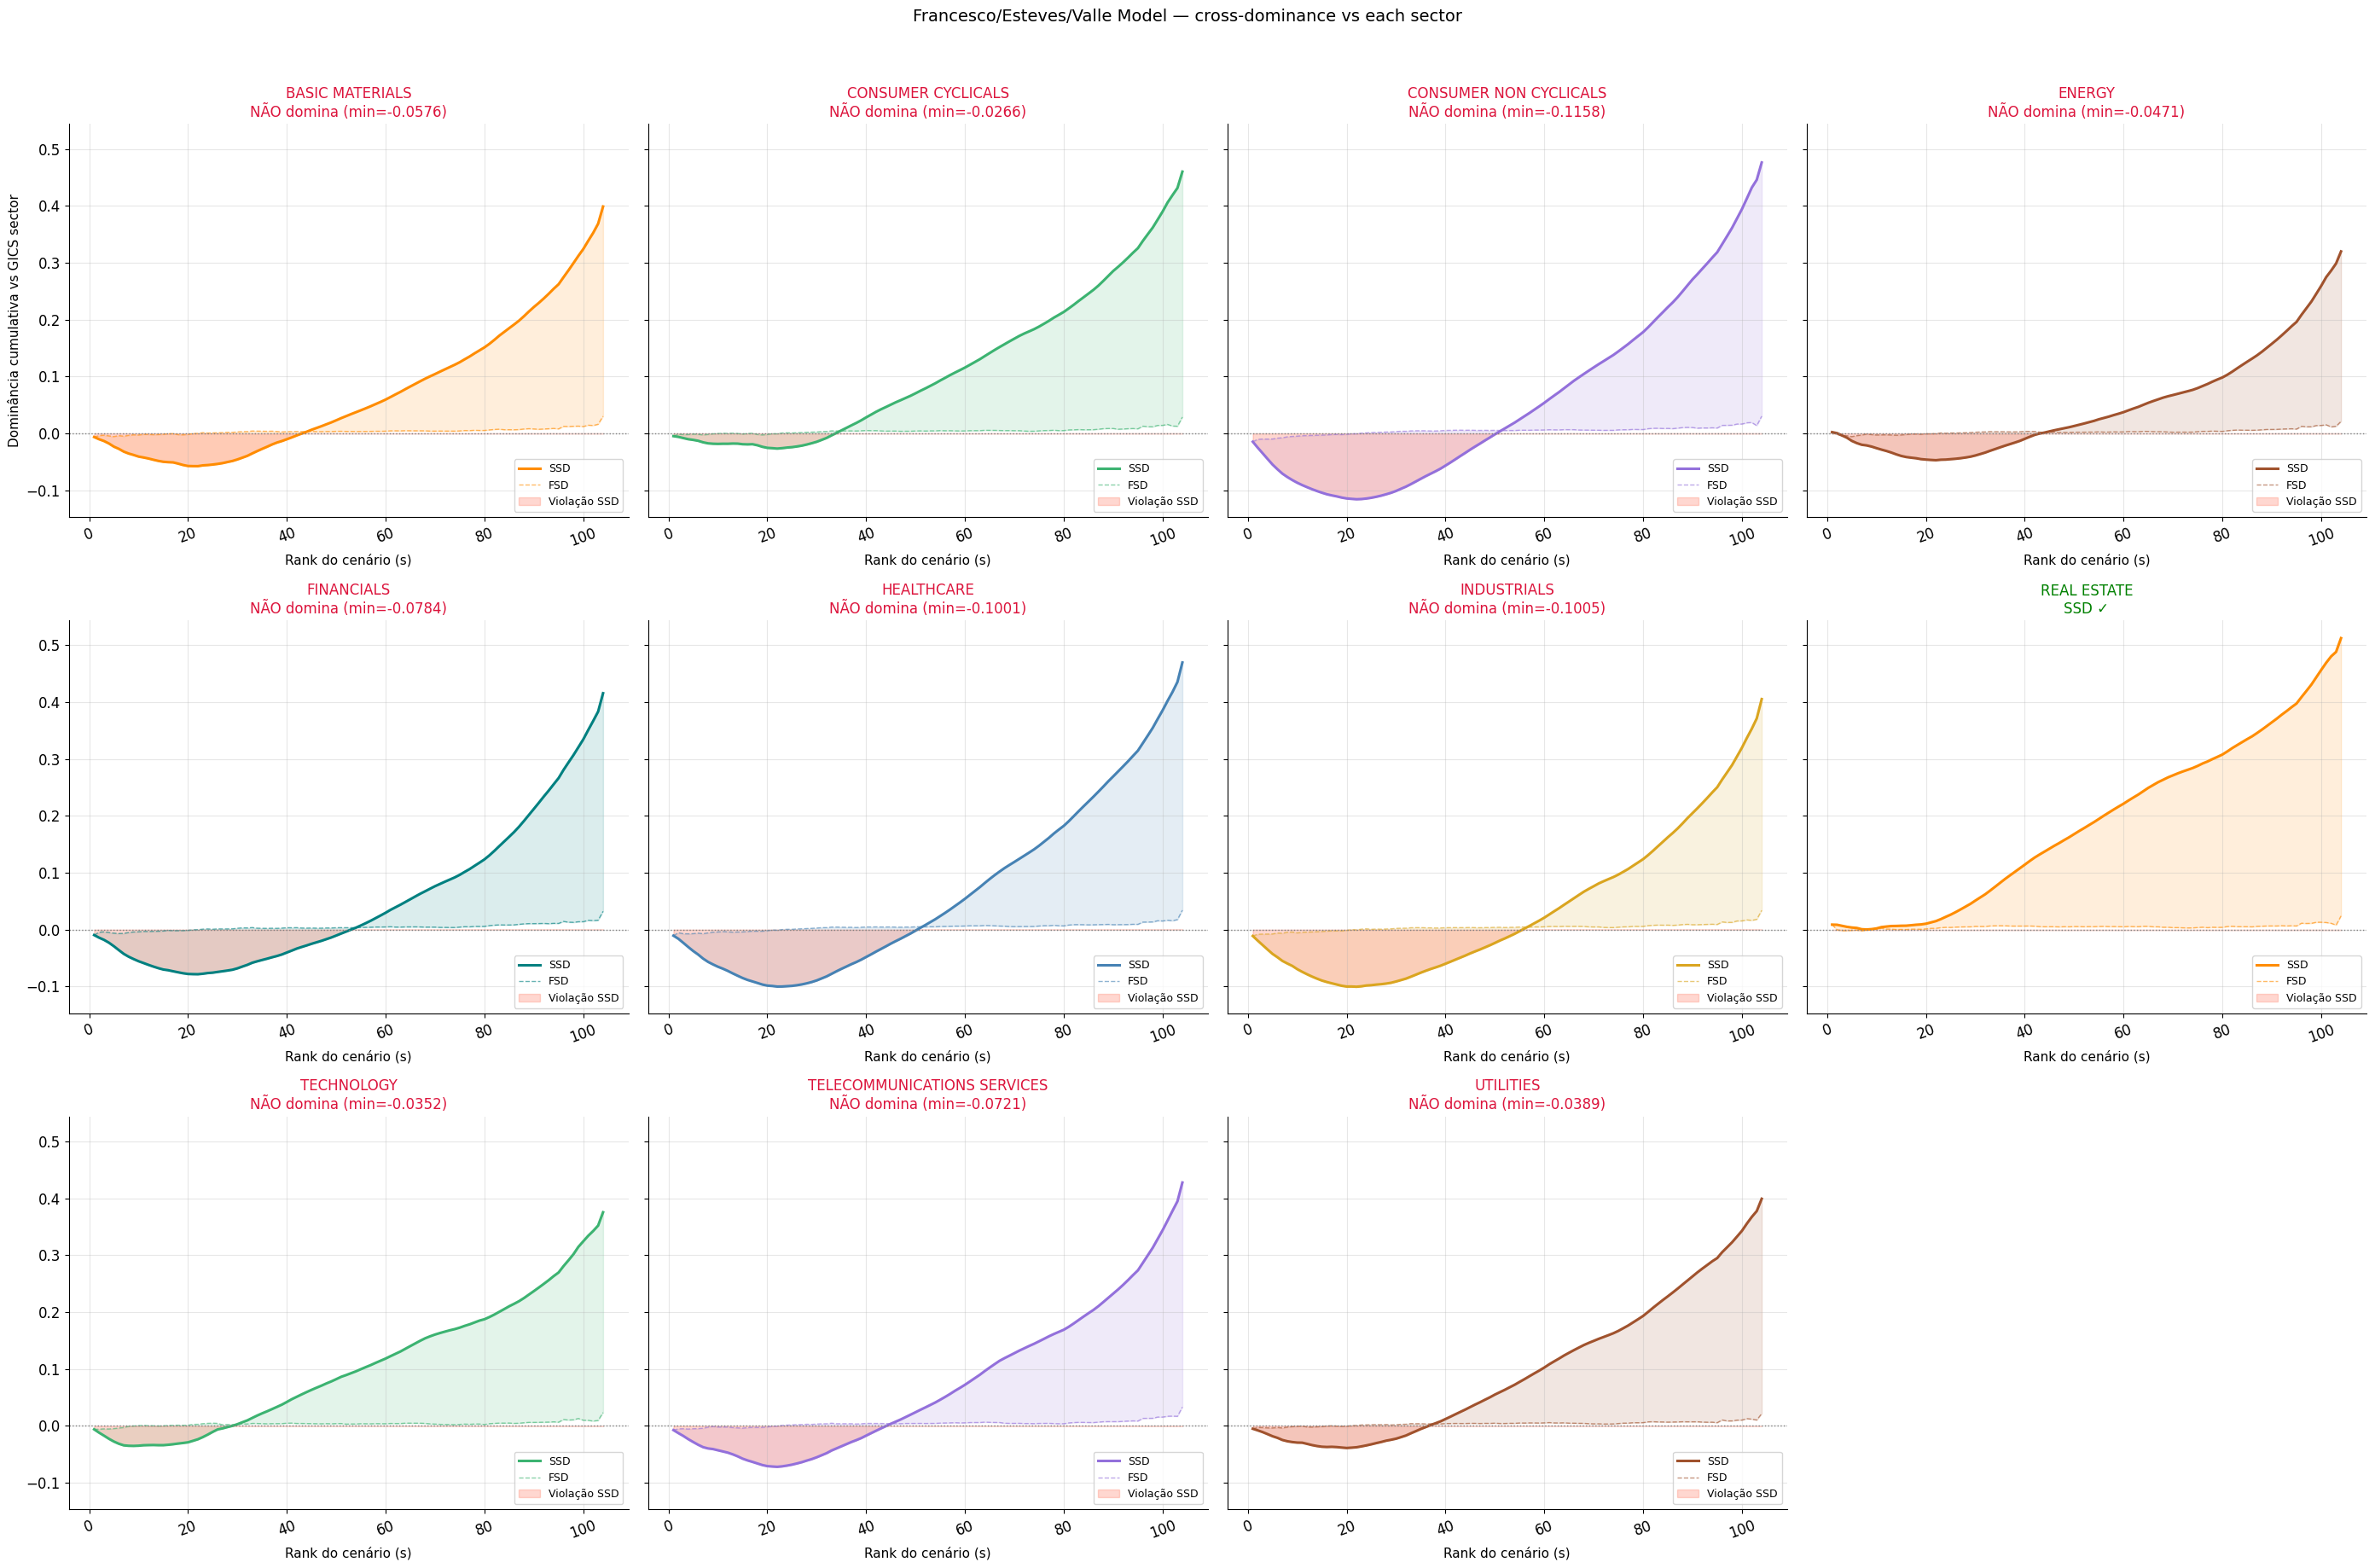

In [17]:
# Cross-dominance: Francesco/Esteves/Valle Model vs each sector benchmark
if 'Francesco/Esteves/Valle Model' in models:
    port_ret  = models['Francesco/Esteves/Valle Model'].reindex(idx).pct_change().dropna()
    cross_dom = {}

    print(f'\n=== Francesco/Esteves/Valle Model: cross-dominance vs each sector ===')
    print(f'  {"Sector":<38}  {"min(SSD)":>10}  {"min(FSD)":>10}  Status')
    print('  ' + '-' * 72)

    for sector in AVAILABLE_SECTORS:
        bench_ret = sector_oos[sector]['ret'].reindex(port_ret.index).dropna()
        common    = port_ret.index.intersection(bench_ret.index)
        s, fsd, ssd = compute_ssd_dominance(
            port_ret.loc[common].values, bench_ret.loc[common].values
        )
        cross_dom[sector.replace('_', ' ')] = (s, fsd, ssd)
        tag = '✓ DOMINATES' if ssd.min() >= 0 else '✗ VIOLATES'
        print(f'  {sector:<38}  {ssd.min():+10.6f}  {fsd.min():+10.6f}  {tag}')

    plot_dominance_panels(
        cross_dom, n_cols=4,
        benchmark_name='GICS sector',
        title='Francesco/Esteves/Valle Model — cross-dominance vs each sector',
        save_path=SECTORS_DIR_OUT / 'ssd_cross_dominance_sectors.pdf',
    )


**Cross-dominance: Francesco/Esteves/Valle Model vs each individual sector**

Cross-dominance is the most revealing check on the generality of the model. If the portfolio SSD-dominates each of the 11 sectors separately — including sectors that were not the binding constraint during optimization — this confirms that the Synthetic Benchmark imposes sufficiently rigid constraints to guarantee generalized dominance. Failing to dominate all sectors is expected and acceptable: the model was optimized to dominate the tail-expectation envelope, and a specific sector may exceed that envelope in distribution due to short-term deviations not capturable in-sample. The most informative result is the comparison of min(SSD) across sectors: sectors with more severe violations were the hardest to dominate OOS and are natural candidates for problematic benchmarks in the subsequent period. The correlation between the non-dominated sectors here and the sectors that dominated most days in the frequency chart (section 3b) confirms the coherence of the analysis — sectors with the best OOS performance are the hardest to SSD-dominate.

---


---
## 10b. SSD dominance — CDFs and cumulative integrals (Francesco/Esteves/Valle Model)

Compares F(x) (portfolio CDF) vs G(x) (sectoral Synthetic Benchmark CDF):
- **Green**: G ≥ F → portfolio dominates in this region
- **Pink**: G < F → benchmark dominates in this region
- **I₂(x)**: left cumulative integral of G−F (SSD condition: I₂ ≥ 0 everywhere confirms second-order dominance)

---


In [18]:
def plot_cdf_dominance(r_port, r_bench, port_name='Portfolio', bench_name='Synthetic Benchmark',
                       save_path=None):
    n_pts  = 1000
    lo     = min(r_port.min(), r_bench.min()) - 0.002
    hi     = max(r_port.max(), r_bench.max()) + 0.002
    x_grid = np.linspace(lo, hi, n_pts)
    dx     = x_grid[1] - x_grid[0]

    F = np.array([np.mean(r_port  <= x) for x in x_grid])
    G = np.array([np.mean(r_bench <= x) for x in x_grid])

    diff = G - F
    I2   = np.cumsum(diff) * dx   # SSD: running left integral (I₂ ≥ 0 everywhere ⟺ SSD)

    fig, (ax_cdf, ax_diff) = plt.subplots(1, 2, figsize=(18, 6))
    fig.patch.set_facecolor('white')

    # ── Left: CDFs ─────────────────────────────────────────────────────────────
    ax_cdf.set_facecolor('white')
    ax_cdf.step(x_grid, F, color='#ff7f0e', linewidth=2,
                label=f'F(x) — {port_name}', where='post')
    ax_cdf.step(x_grid, G, color='black', linewidth=2, linestyle='--',
                label=f'G(x) — {bench_name}', where='post')
    ax_cdf.fill_between(x_grid, F, G, where=(G >= F), alpha=0.25, color='#2ca02c',
                         label='G≥F: portfolio dominates', step='post')
    ax_cdf.fill_between(x_grid, F, G, where=(G <  F), alpha=0.25, color='#d62728',
                         label='G<F: benchmark dominates', step='post')
    ax_cdf.set_ylim(0, 1.05)
    ax_cdf.set_xlabel('Daily return x', fontsize=11)
    ax_cdf.set_ylabel('P(return ≤ x)', fontsize=11)
    ax_cdf.set_title(f'F (portfolio) vs G ({bench_name})', fontsize=12)
    ax_cdf.legend(fontsize=9, loc='upper left')
    for sp in ax_cdf.spines.values(): sp.set_visible(False)

    # ── Right: G-F + SSD integral ──────────────────────────────────────────────
    ax_diff.set_facecolor('white')
    ax_diff.step(x_grid, diff, color='black', linewidth=1.5,
                 label='G(x)−F(x)', where='post', zorder=3)
    ax_diff.fill_between(x_grid, diff, 0, where=(diff >= 0), alpha=0.25,
                          color='#2ca02c', step='post', label='G−F ≥ 0')
    ax_diff.fill_between(x_grid, diff, 0, where=(diff <  0), alpha=0.25,
                          color='#d62728', step='post', label='G−F < 0')
    ax_diff.axhline(0, color='black', linewidth=0.4, alpha=0.3)
    ax_diff.set_xlabel('Daily return x', fontsize=11)
    ax_diff.set_ylabel('G(x) − F(x)', fontsize=11)
    ax_diff.set_title('G(x)−F(x) and cumulative integral I₂(x)', fontsize=12)
    for sp in ax_diff.spines.values(): sp.set_visible(False)

    ax2 = ax_diff.twinx()
    ax2.plot(x_grid, I2, color='steelblue', linewidth=2, linestyle='--',
             label='I₂(x) — SSD condition (left ∫)')
    ax2.axhline(0, color='lightgray', linewidth=0.5)
    ax2.set_ylabel('I₂(x) — cumulative integral', fontsize=9)
    for sp in ax2.spines.values(): sp.set_visible(False)

    lines1, labels1 = ax_diff.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax_diff.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower right')

    plt.suptitle(f'{port_name} vs {bench_name} — CDF analysis and SSD dominance',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


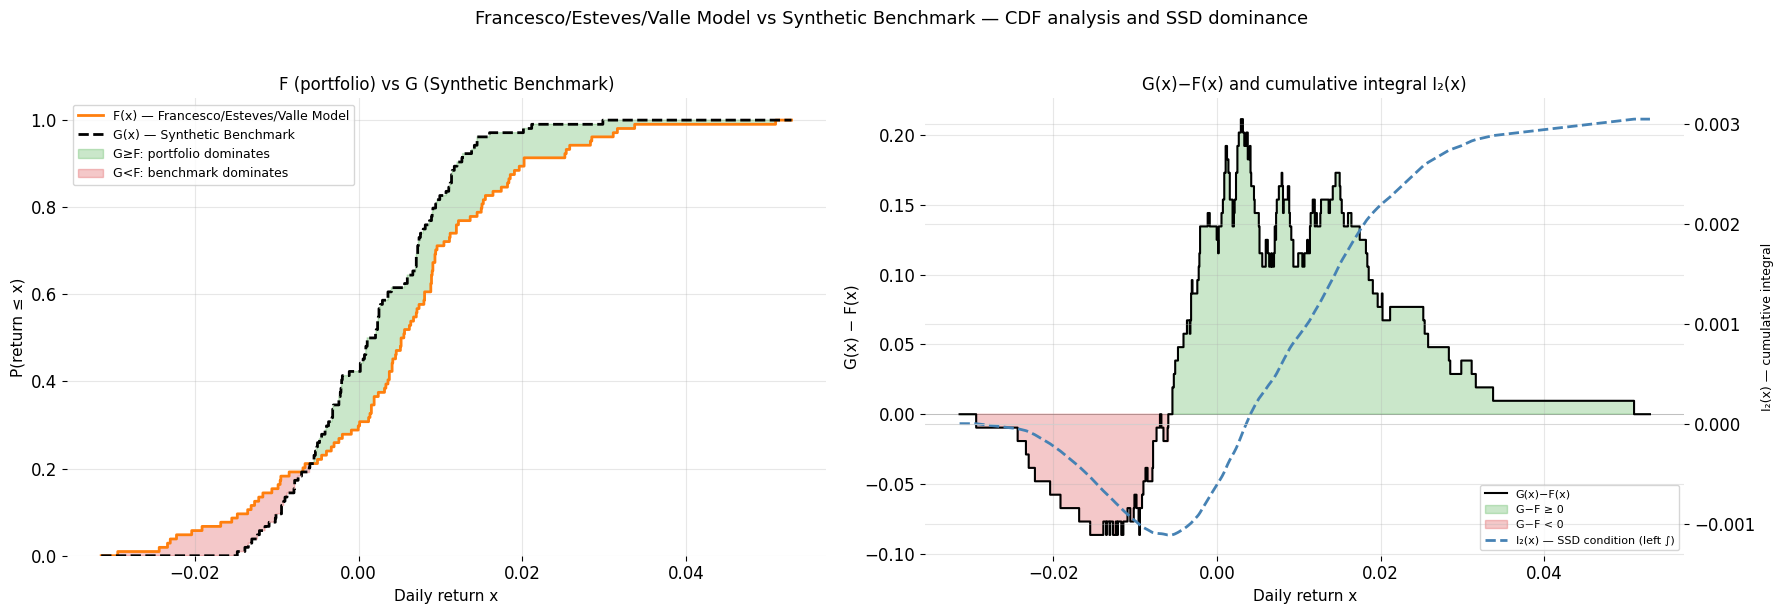

In [19]:
if 'Francesco/Esteves/Valle Model' in models:
    port_series = models['Francesco/Esteves/Valle Model'].reindex(idx)
    r_p    = port_series.pct_change().dropna()
    r_b    = synth_oos.pct_change().dropna().reindex(r_p.index).dropna()
    common = r_p.index.intersection(r_b.index)

    plot_cdf_dominance(
        r_p.loc[common].values, r_b.loc[common].values,
        port_name='Francesco/Esteves/Valle Model',
        bench_name='Synthetic Benchmark',
        save_path=SECTORS_DIR_OUT / 'cdf_dominance_fev_model.pdf',
    )


**CDFs and SSD integral: Francesco/Esteves/Valle Model vs Synthetic Benchmark**

The left panel overlays the empirical CDFs of the portfolio F(x) and the Synthetic Benchmark G(x). The relative position of the two curves in the left tail (small x) is the most direct evidence of downside protection: F(x) below G(x) in this region means the portfolio has lower probability of very negative returns — the SSD constraint in the tails materialized OOS. The right panel displays G(x)−F(x) and the cumulative integral I₂(x), which is the necessary and sufficient condition for SSD dominance: I₂(x) ≥ 0 at all points confirms dominance. In the colored regions, green (G ≥ F) indicates where the portfolio dominates in the marginal distribution; pink (G < F) indicates where the benchmark dominates — some alternation is normal, as what matters is the sign of the cumulative integral, not the pointwise sign. A violation of I₂ < 0 locates exactly where SSD dominance did not transfer to the OOS; violations near the left tail are more concerning. The point where I₂ reaches its maximum generally coincides with the median of the benchmark distribution, indicating where the portfolio's accumulated advantage is greatest.

---


---
## 10c. r\_P vs r\_B by quantile — tail analysis (Francesco/Esteves/Valle Model)

For each quantile threshold, separates OOS days into:
- **Worst benchmark days (blue)**: the k days with the lowest benchmark returns → measures downside protection
- **Best benchmark days (orange)**: the remaining days → measures upside capture

The β of each regression measures the sensitivity of the portfolio return to the benchmark in that region.
The portfolio is compared against the **sectoral Synthetic Benchmark**, which is its optimization benchmark in the model.

---


In [20]:
def plot_tail_scatter(r_port, r_bench, quantiles=(0.1, 0.3, 0.5, 0.7, 0.9),
                      port_name='Portfolio', bench_name='Synthetic Benchmark', save_path=None):
    n          = len(r_port)
    sorted_idx = np.argsort(r_bench)

    fig, axes = plt.subplots(1, len(quantiles), figsize=(22, 5))
    fig.patch.set_facecolor('white')

    for ax, q in zip(axes, quantiles):
        k         = max(1, int(np.floor(q * n)))
        n_upper   = n - k
        lower_idx = sorted_idx[:k]
        upper_idx = sorted_idx[k:]

        ax.set_facecolor('white')
        ax.scatter(r_bench[lower_idx], r_port[lower_idx],
                   color='steelblue', alpha=0.65, s=30, zorder=3,
                   label=f'Worst benchmark days (k={k})')
        ax.scatter(r_bench[upper_idx], r_port[upper_idx],
                   color='#ff7f0e', alpha=0.65, s=30, zorder=3,
                   label=f'Best benchmark days (n={n_upper})')

        all_v = np.concatenate([r_bench, r_port])
        lim   = max(abs(all_v.min()), abs(all_v.max())) * 1.1
        ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.8, alpha=0.5, label='r_P = r_B')
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.axhline(0, color='gray', linewidth=0.4, alpha=0.5)
        ax.axvline(0, color='gray', linewidth=0.4, alpha=0.5)

        for x_data, y_data, color, tx, ty, ha, va in [
            (r_bench[lower_idx], r_port[lower_idx], 'steelblue', 0.05, 0.93, 'left',  'top'),
            (r_bench[upper_idx], r_port[upper_idx], '#ff7f0e',   0.95, 0.07, 'right', 'bottom'),
        ]:
            if len(x_data) > 2:
                coeffs = np.polyfit(x_data, y_data, 1)
                beta   = coeffs[0]
                x_fit  = np.linspace(x_data.min(), x_data.max(), 100)
                ax.plot(x_fit, np.polyval(coeffs, x_fit),
                        color=color, linewidth=2, linestyle='--')
                ax.text(tx, ty, f'β={beta:.2f}', transform=ax.transAxes,
                        color=color, fontsize=9, ha=ha, va=va, fontweight='bold')

        ax.set_title(f'Quantile = {q}', fontsize=12)
        ax.set_xlabel(f'r_B ({bench_name})', fontsize=10)
        if ax is axes[0]:
            ax.set_ylabel('r_P (portfolio)', fontsize=10)
        ax.legend(fontsize=7, loc='upper left')
        for sp in ax.spines.values(): sp.set_visible(False)

    fig.suptitle(
        f'r_P vs r_B by OOS quantile — {port_name} vs {bench_name}\n'
        'Blue = worst benchmark days | Orange = best benchmark days',
        fontsize=13, y=1.05,
    )

    interp = (
        'Interpretation: the beta (β) annotated on each regression line measures the sensitivity '
        'of the portfolio return to the benchmark in that region. '
        'β < 1 on worst days indicates downside protection (portfolio loses proportionally less). '
        'β > 1 on best days indicates upside capture (portfolio gains proportionally more). '
        'The portfolio is compared against the sectoral Synthetic Benchmark — its optimization benchmark in the model.'
    )
    fig.text(0.5, -0.06, interp, ha='center', va='top', fontsize=8.5,
             style='italic', multialignment='left',
             transform=fig.transFigure)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


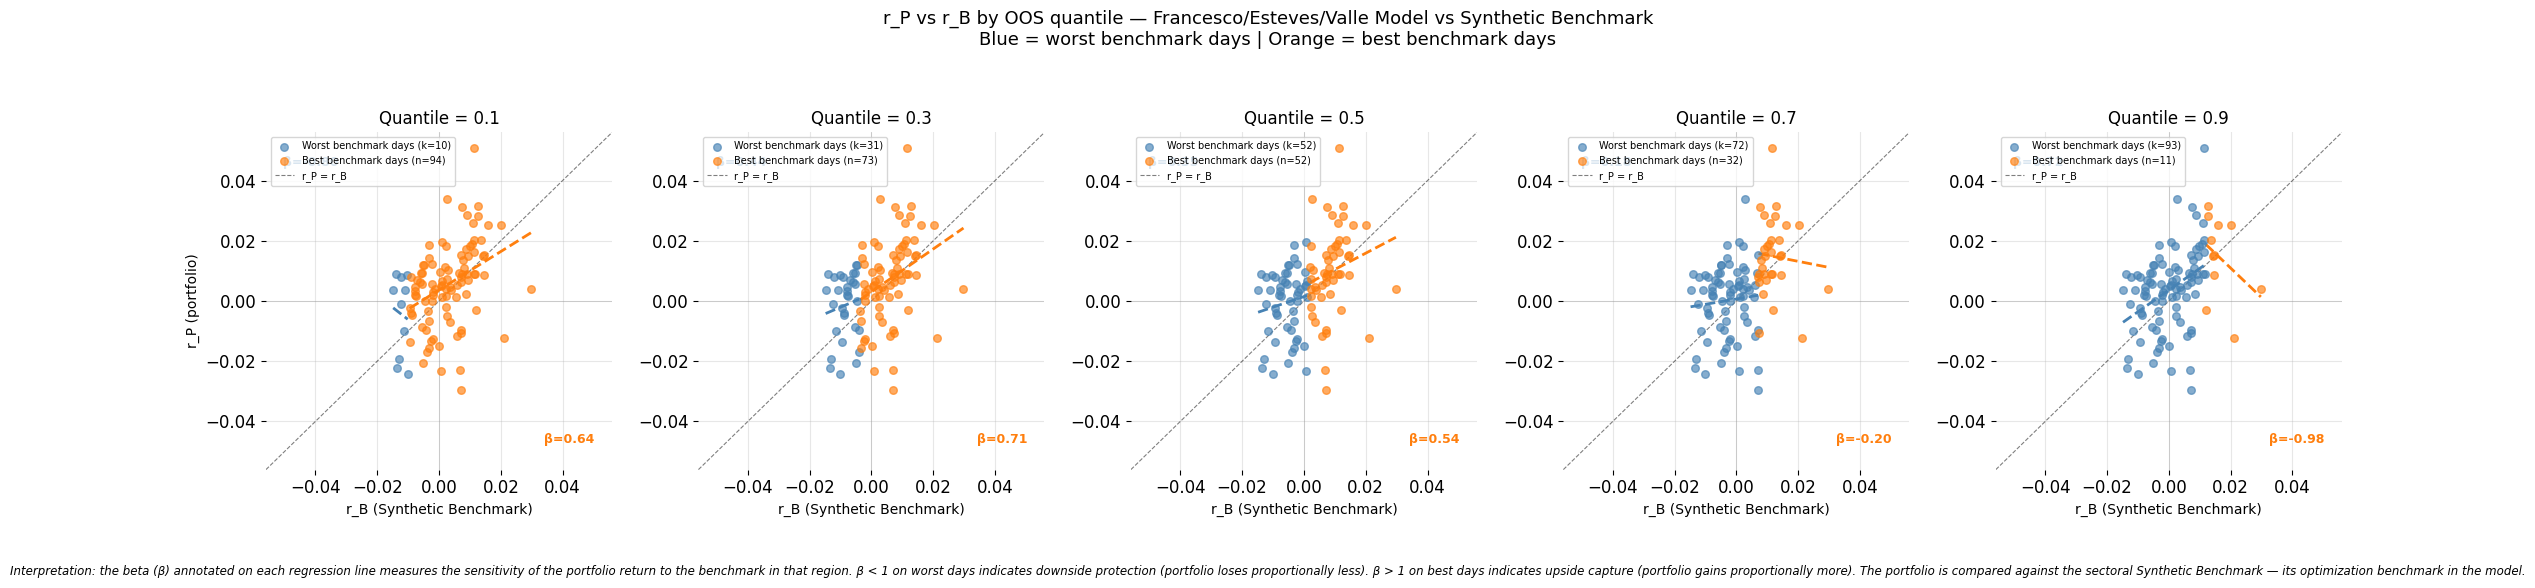

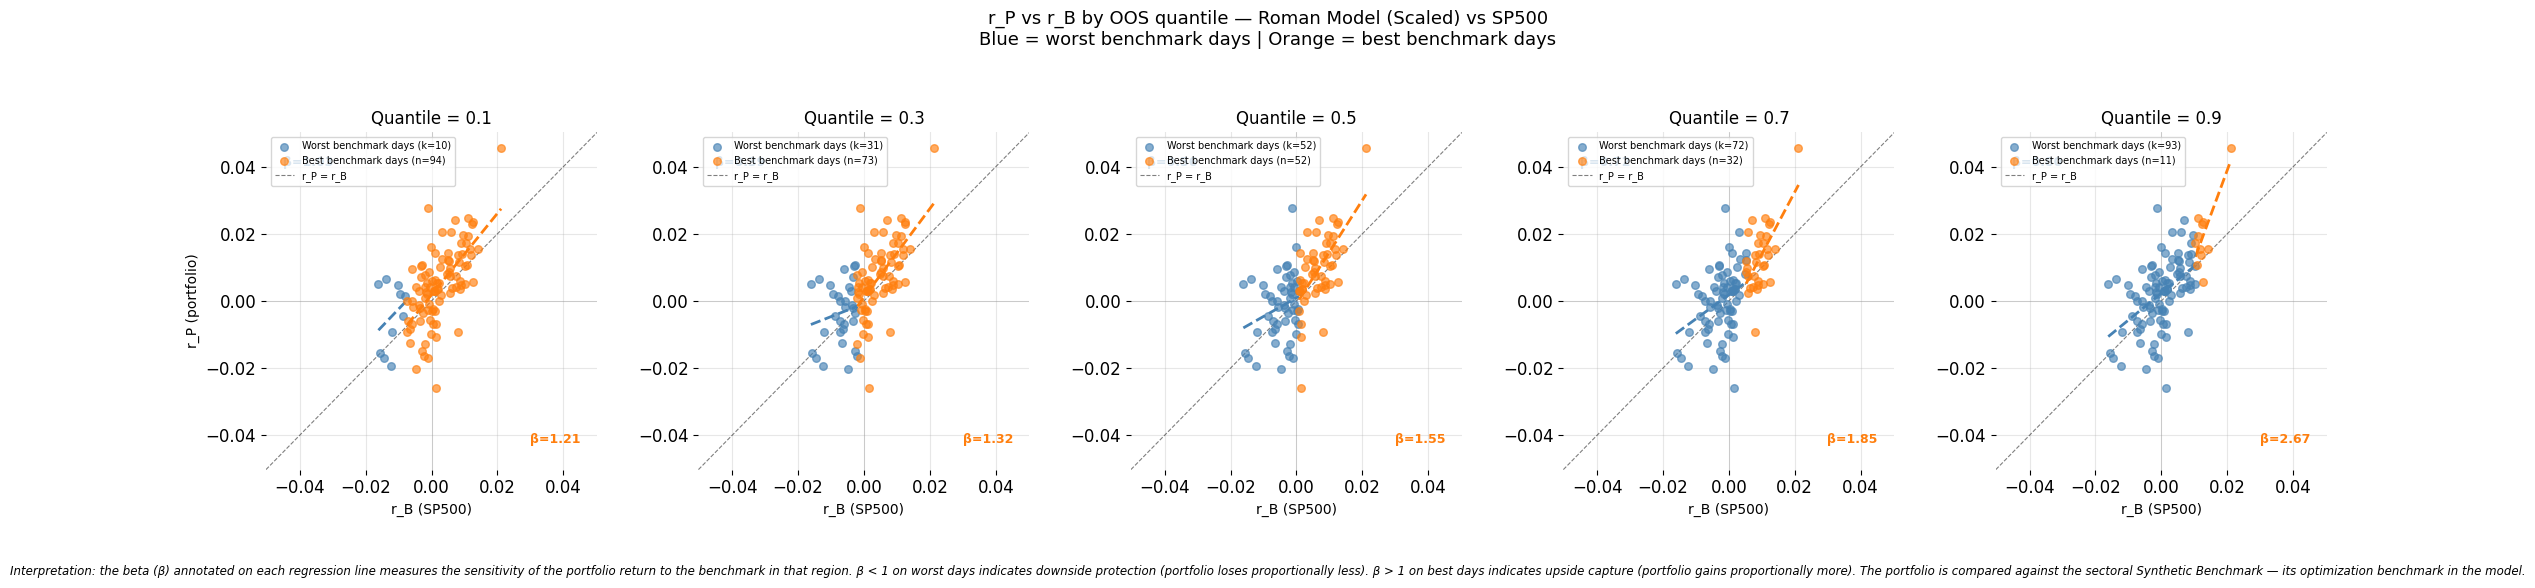

In [21]:
if 'Francesco/Esteves/Valle Model' in models:
    port_series = models['Francesco/Esteves/Valle Model'].reindex(idx)
    r_p    = port_series.pct_change().dropna()
    r_b    = synth_oos.pct_change().dropna().reindex(r_p.index).dropna()
    common = r_p.index.intersection(r_b.index)

    plot_tail_scatter(
        r_p.loc[common].values, r_b.loc[common].values,
        quantiles=(0.1, 0.3, 0.5, 0.7, 0.9),
        port_name='Francesco/Esteves/Valle Model',
        bench_name='Synthetic Benchmark',
        save_path=SECTORS_DIR_OUT / 'tail_scatter_fev_model.pdf',
    )

if 'Roman Model (Scaled)' in models:
    port_rm   = models['Roman Model (Scaled)'].reindex(idx)
    r_p_rm    = port_rm.pct_change().dropna()
    r_b_rm    = sp500_ret.reindex(r_p_rm.index).dropna()
    common_rm = r_p_rm.index.intersection(r_b_rm.index)

    plot_tail_scatter(
        r_p_rm.loc[common_rm].values, r_b_rm.loc[common_rm].values,
        quantiles=(0.1, 0.3, 0.5, 0.7, 0.9),
        port_name='Roman Model (Scaled)',
        bench_name='SP500',
        save_path=SECTORS_DIR_OUT / 'tail_scatter_roman_model.pdf',
    )


**r_P vs r_B by quantile: tail analysis**

For each quantile threshold, OOS days are divided into "worst benchmark days" (blue) and "best benchmark days" (orange). The slope β of each regression measures the portfolio's sensitivity to the benchmark in that region of the distribution. In the Francesco/Esteves/Valle Model vs Synthetic Benchmark, β < 1 on the worst days is the most direct evidence of downside protection: the portfolio falls proportionally less when the Synthetic Benchmark falls, consistent with the SSD constraint on the negative tails of the in-sample distribution. β on the best days tends to be ≈ 1 or lower — SSD optimization includes no upside incentive, so low β here is the expected cost of the pure SSD approach, not a failure. The high dispersion of points indicates that the portfolio is independent of the Synthetic Benchmark on a day-to-day basis, which is expected given that the optimization is distributional (over the empirical distribution), not daily. If blue β increases as the quantile varies from 10% to 50%, downside protection is strongest in the extreme tails — exactly where it is most valuable. The comparison of the Roman Model (Scaled) vs SP500 provides the baseline to assess whether the nature of the benchmark — sectoral vs market index — alters tail behavior.

---


---
## 11. Risk × return analysis
---


[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/risk_return_all.pdf


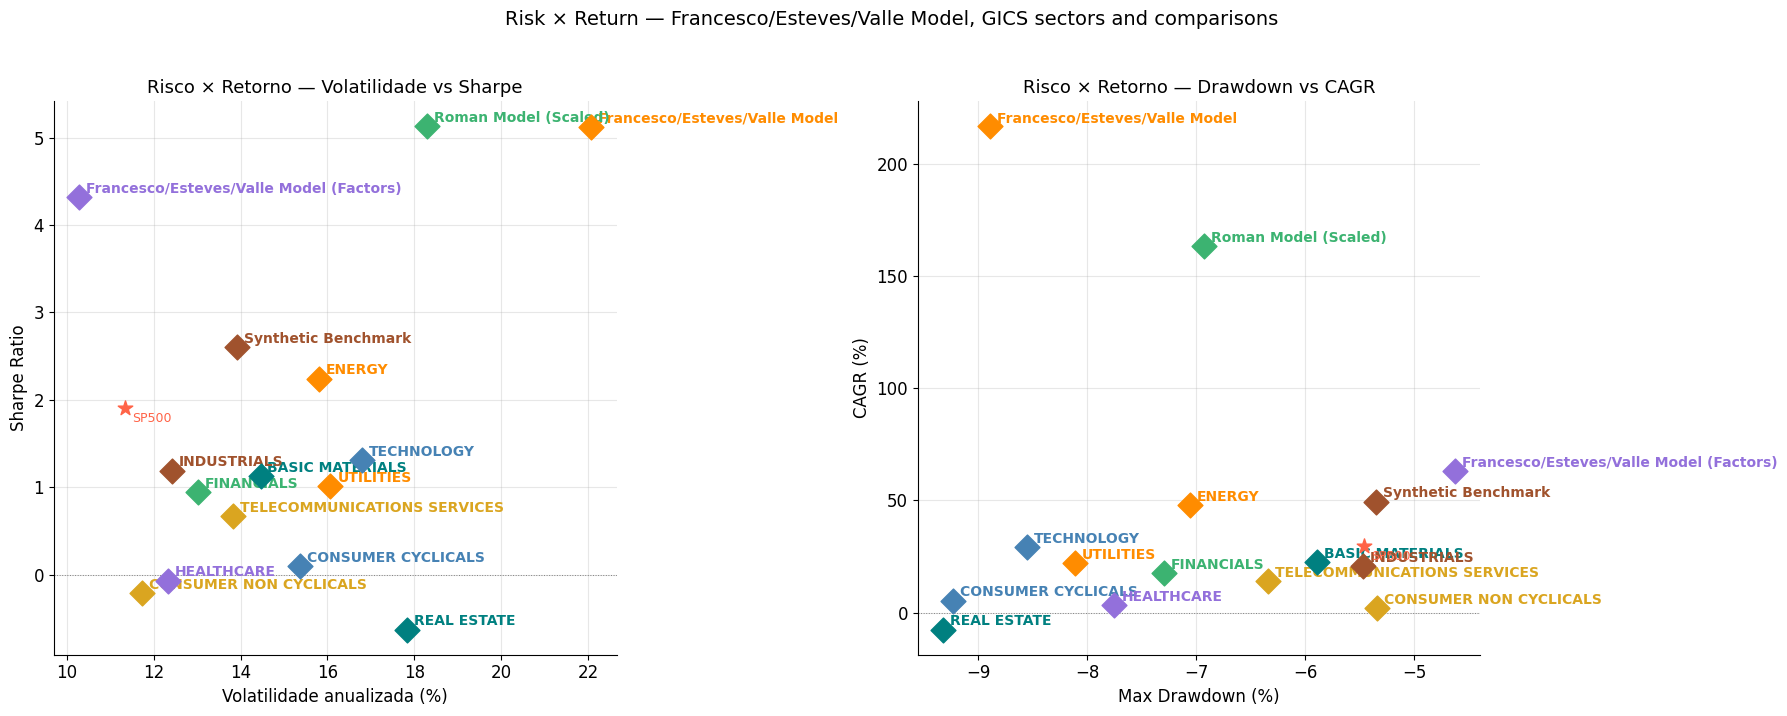

In [22]:
all_for_scatter = dict(models)
all_for_scatter['Synthetic Benchmark'] = synth_oos
for sector in AVAILABLE_SECTORS:
    all_for_scatter[sector.replace('_', ' ')] = sector_oos[sector]['norm'].reindex(idx)

plot_risk_return_scatter(
    all_for_scatter, sp500_norm,
    rf_annual=RISK_FREE,
    title='Risk × Return — Francesco/Esteves/Valle Model, GICS sectors and comparisons',
    save_path=SECTORS_DIR_OUT / 'risk_return_all.pdf',
)


**Risk × Return (scatter)**

The scatter plot positions each model and sector in the annualized volatility × return (CAGR) space. The SP500 Sharpe line divides the chart between portfolios/sectors that delivered better or worse risk-return ratios than the market in the OOS period. The Francesco/Esteves/Valle Model should ideally position itself above this line and to the left (lower volatility) of most sectors, confirming that SSD optimization reduced risk without excessively sacrificing return. The cloud of sectors reveals the heterogeneity of the benchmark universe: sectors in the upper-left quadrant (high return, low risk) are the hardest to dominate via SSD.
The Synthetic Benchmark, being the maximum of sectors on each day, tends to show high return but also high volatility — Sharpe below the best individual sectors is the expected behavior. The relative position of the Francesco/Esteves/Valle Model vs Roman Model in the scatter is the most direct indicator of whether the use of sectoral benchmarks was beneficial: a better position (higher Sharpe) confirms added value from the benchmark choice.

---


---
## 12. Return distribution and correlation
---


[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/return_dist_models.pdf


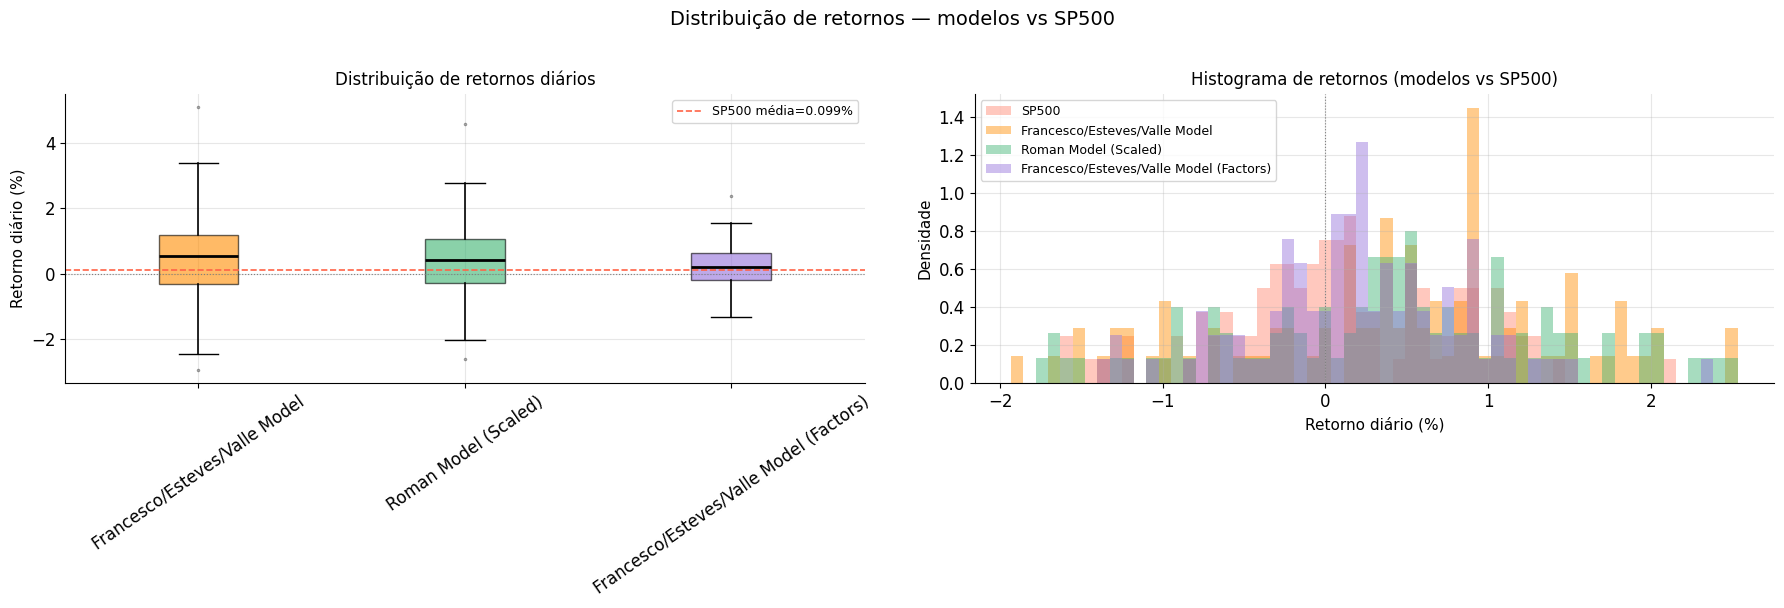

In [23]:
# Return distribution: portfolio models only
plot_return_distribution(
    models, sp500_ret,
    highlight_keys=list(models.keys()),
    save_path=SECTORS_DIR_OUT / 'return_dist_models.pdf',
)


**Daily return distribution**

The histograms show the empirical distribution of daily returns for each model, with SP500 as reference. SSD-optimized portfolios tend to show distributions with a lighter left tail (fewer days of extreme losses) than the benchmark — the objective of the formulation is precisely to shift probability mass away from the worst regions. Positive skewness (skewness > 0) and lower kurtosis in the left tail of the Francesco/Esteves/Valle Model, compared to SP500, confirms that downside protection translates into a return distribution with a shorter "left tail." The position of the median vs. that of SP500 indicates whether the model delivers daily returns systematically above or below the market. More concentrated distributions (lower standard deviation) correspond to the lower volatility already visible in the risk-return scatter — consistency between metrics confirms the coherence of the analysis.

---


[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/correlation_all.pdf


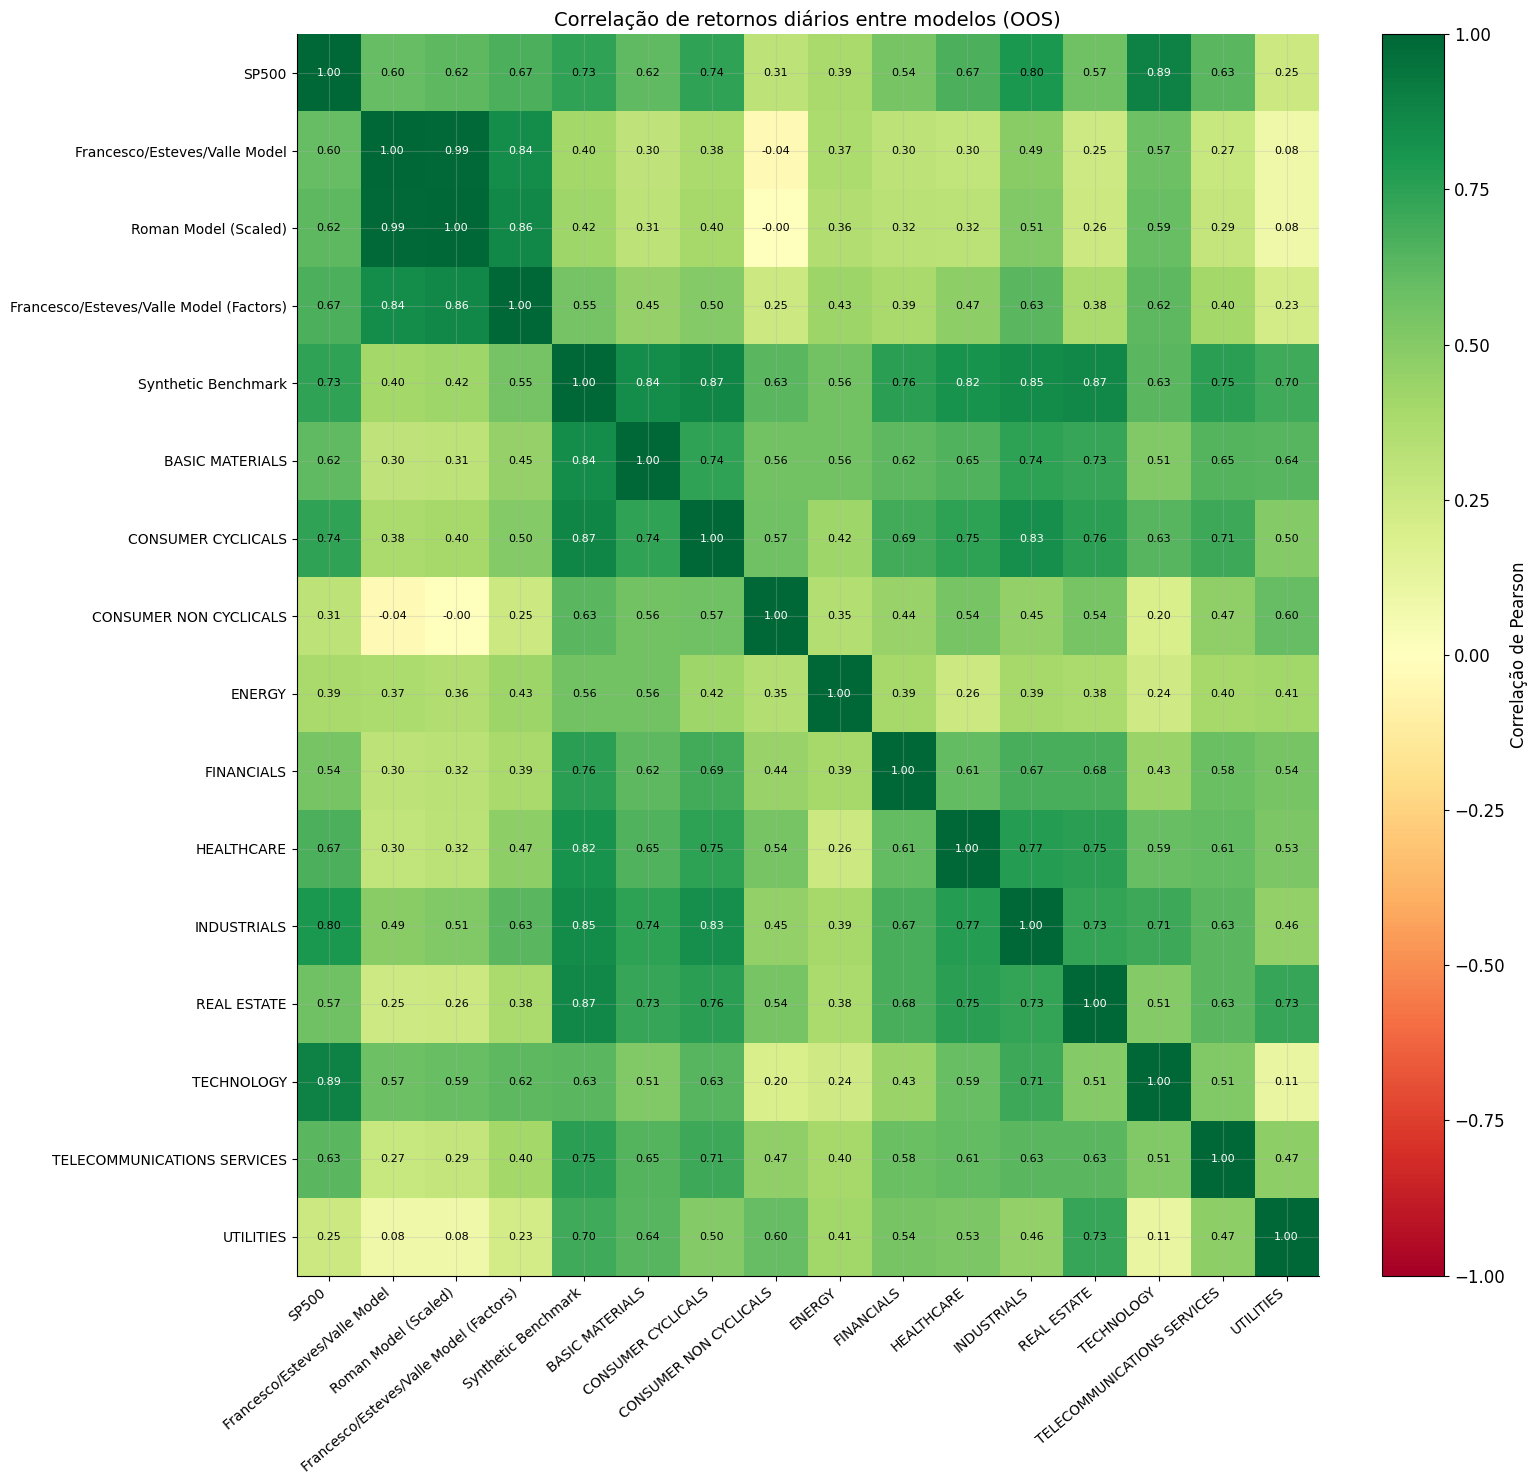

In [24]:
# Correlation: models + sector benchmarks
all_corr = dict(models)
all_corr['Synthetic Benchmark'] = synth_oos
for sector in AVAILABLE_SECTORS:
    all_corr[sector.replace('_', ' ')] = sector_oos[sector]['norm'].reindex(idx)

plot_correlation_matrix(
    all_corr, sp500_ret,
    benchmark_name='SP500',
    save_path=SECTORS_DIR_OUT / 'correlation_all.pdf',
)


**Correlation matrix**

The heatmap reveals the correlations between daily returns of all models and sectors. Low correlation of the Francesco/Esteves/Valle Model with an individual sector indicates that the portfolio did not replicate that benchmark — probably because different sectors were binding in different training windows, generating a portfolio with diversified sectoral exposure over time. Moderate correlation with the Synthetic Benchmark is the expected pattern: high correlation would indicate that the portfolio tracks the sectoral envelope (clone behavior); very low correlation would indicate near-total independence — an aggressive diversification strategy that maximizes the gap relative to the benchmark. The block of inter-sector correlations identifies groups that share cycles (e.g., Financials and Real Estate), which may create instability in SSD constraints when rotation between them occurs. High correlation between the Francesco/Esteves/Valle Model and the Roman Model suggests that both converge to similar portfolios despite distinct benchmarks — evidence of robustness in the SSD approach; low correlation indicates that the benchmark genuinely differentiates the resulting portfolio.

---


---
## 13. Rolling returns (21 days)
---


[INFO]: Plot saved → /media/toni/Dados/Git/ssd-multi/src/output/tafmssd-sectors/rolling_returns.pdf


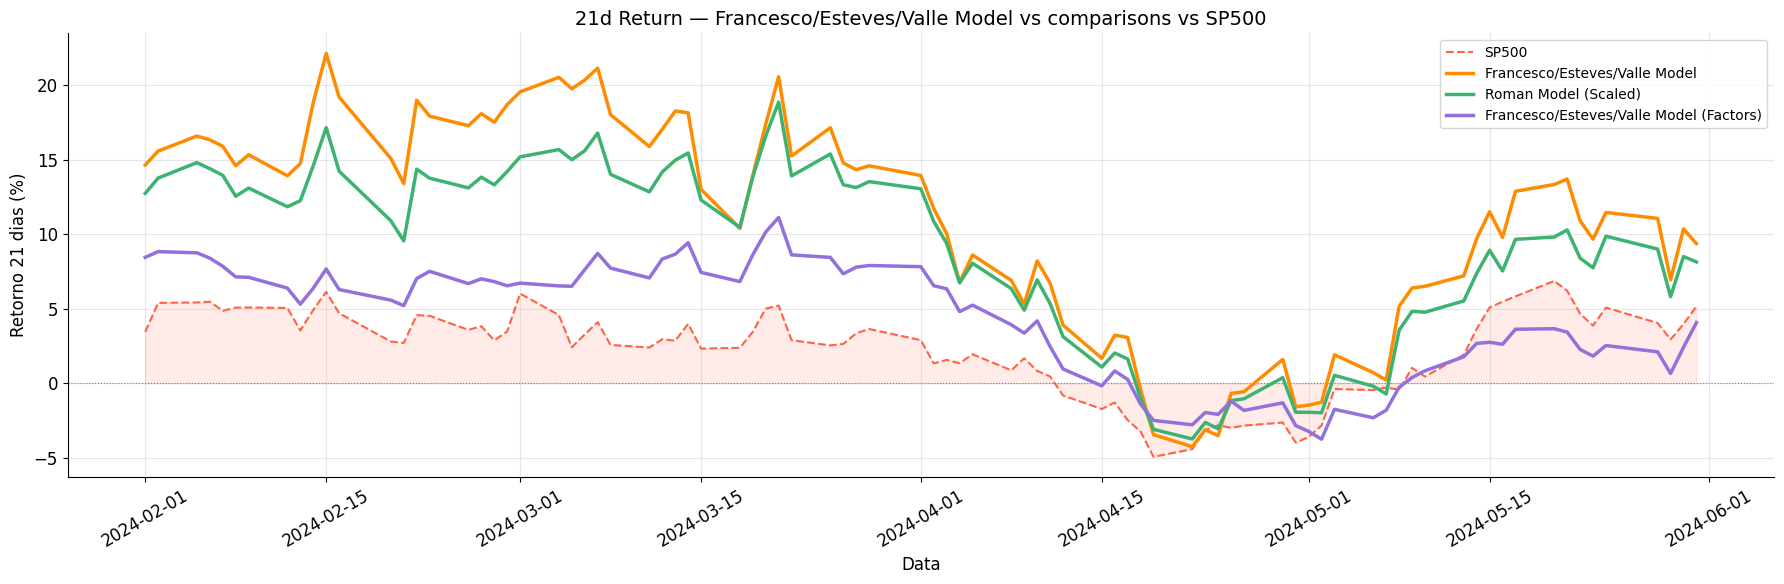

In [25]:
plot_rolling_returns(
    models, sp500_norm, window=21,
    title='21d Return — Francesco/Esteves/Valle Model vs comparisons vs SP500',
    save_path=SECTORS_DIR_OUT / 'rolling_returns.pdf',
)


**21-day rolling returns**

The 21-day rolling return series smooths daily noise and highlights medium-term trends, revealing portfolio behavior at the time horizon that coincides with the rebalancing frequency. An SSD-robust portfolio should show monthly returns that are rarely very negative: the downside protection guaranteed in-sample should be visible on a monthly scale, not just in daily returns. Declines just before a rebalancing followed by recovery just after are expected — the model adjusts weights for the regime prevailing in the new training window. If the Francesco/Esteves/Valle Model has fewer periods with negative monthly returns than the Roman Model, the sectoral benchmark generated greater stability; the opposite would indicate that sectoral constraints reduced exposure to positive market months. Large divergences between models in specific windows point to periods where benchmark choice made a concrete difference — correlate these moments with the dominant sector in section 3b to understand whether sectoral rotation created opportunity or exposure not captured by the model.

---


---
## 14. Executive Summary
---


In [26]:
print('=' * 100)
print('  EXECUTIVE SUMMARY — Francesco/Esteves/Valle Model')
print(f'  OOS Period: {OOS_START} → {OOS_END}')
print('=' * 100)

m_sp = compute_metrics(sp500_norm, benchmark=sp500_norm, rf_annual=RISK_FREE)
hdr  = (f"  {'Model':<42}  {'Final':>7}  {'CAGR':>8}  {'Vol':>7}  "
        f"{'Sharpe':>8}  {'Sortino':>9}  {'MaxDD':>8}  {'Beta':>7}")
print(hdr)
print('  ' + '-' * 104)
ref  = (f"  {'SP500 (ref)':<42}  {m_sp['Final value']:>7.4f}  {m_sp['CAGR (%)']:>+7.2f}%  "
        f"{m_sp['Volatility (%)']:>6.2f}%  {m_sp['Sharpe Ratio']:>8.4f}  "
        f"{m_sp['Sortino Ratio']:>9.4f}  {m_sp['Max Drawdown (%)']:>+7.2f}%  {'1.0000':>7}")
print(ref)
print('  ' + '-' * 104)

for label in list(models.keys()) + ['Synthetic Benchmark']:
    series = synth_oos if label == 'Synthetic Benchmark' else models[label].reindex(idx)
    m      = compute_metrics(series, benchmark=sp500_norm, rf_annual=RISK_FREE)
    beta   = f"{m['Portfolio beta']:.4f}" if not pd.isna(m['Portfolio beta']) else '--'
    beat   = ' ◄' if m['Sharpe Ratio'] > m_sp['Sharpe Ratio'] else ''
    row    = (f"  {label:<42}  {m['Final value']:>7.4f}  {m['CAGR (%)']:>+7.2f}%  "
              f"{m['Volatility (%)']:>6.2f}%  {m['Sharpe Ratio']:>8.4f}  "
              f"{m['Sortino Ratio']:>9.4f}  {m['Max Drawdown (%)']:>+7.2f}%  {beta:>7}{beat}")
    print(row)

print('=' * 100)


  EXECUTIVE SUMMARY — Francesco/Esteves/Valle Model
  OOS Period: 2024-01-01 → 2024-06-01
  Model                                         Final      CAGR      Vol    Sharpe    Sortino     MaxDD     Beta
  --------------------------------------------------------------------------------------------------------
  SP500 (ref)                                  1.1127   +29.54%   11.34%    1.9096     3.5279    -5.46%   1.0000
  --------------------------------------------------------------------------------------------------------
  Francesco/Esteves/Valle Model                1.6089  +216.55%   22.07%    5.1204    16.9911    -8.89%   1.1691 ◄
  Roman Model (Scaled)                         1.4911  +163.29%   18.29%    5.1260    15.2550    -6.93%   1.0043 ◄
  Francesco/Esteves/Valle Model (Factors)      1.2230   +62.88%   10.29%    4.3224     9.3841    -4.63%   0.6071 ◄
  Synthetic Benchmark                          1.1802   +49.39%   13.91%    2.6066     7.3038    -5.35%   0.9013 ◄


In [27]:
# Sector benchmarks performance summary
print('\n' + '=' * 80)
print('  GICS SECTORS — OOS PERFORMANCE')
print('=' * 80)
print(f"  {'Sector':<38}  {'Final':>7}  {'CAGR':>8}  {'Sharpe':>8}")
print('  ' + '-' * 65)

sector_metrics = []
for sector in AVAILABLE_SECTORS:
    norm = sector_oos[sector]['norm'].reindex(idx)
    m    = compute_metrics(norm, benchmark=sp500_norm, rf_annual=RISK_FREE)
    sector_metrics.append((sector, m))
    print(f"  {sector.replace('_', ' '):<38}  {m['Final value']:>7.4f}  "
          f"{m['CAGR (%)']:>+7.2f}%  {m['Sharpe Ratio']:>8.4f}")

print('=' * 80)



  GICS SECTORS — OOS PERFORMANCE
  Sector                                    Final      CAGR    Sharpe
  -----------------------------------------------------------------
  BASIC MATERIALS                          1.0867   +22.33%    1.1288
  CONSUMER CYCLICALS                       1.0215    +5.30%    0.0949
  CONSUMER NON CYCLICALS                   1.0073    +1.79%   -0.2070
  ENERGY                                   1.1750   +47.80%    2.2436
  FINANCIALS                               1.0696   +17.70%    0.9421
  HEALTHCARE                               1.0137    +3.36%   -0.0671
  INDUSTRIALS                              1.0810   +20.78%    1.1896
  REAL ESTATE                              0.9679    -7.60%   -0.6279
  TECHNOLOGY                               1.1108   +28.98%    1.3094
  TELECOMMUNICATIONS SERVICES              1.0562   +14.16%    0.6739
  UTILITIES                                1.0853   +21.94%    1.0106


---

## 14b. Solver diagnostics (CPLEX)

In [28]:
# ── Solver diagnostics (CPLEX) ────────────────────────────────────────────────
solver_stats = pd.read_csv(SECTORS_DIR_OUT / 'solver_stats_tafmssd_sectors.csv',
                           parse_dates=['date'], index_col='date')

print(f'Windows solved (WFV days): {len(solver_stats)}')
print(f'Status: {solver_stats["status"].unique().tolist()}')
print(f'Max MIP gap: {solver_stats["mip_gap"].max():.3e}')
print(f'Lazy cuts — total: {solver_stats["n_lazy_cuts"].sum()}, '
      f'mean/day: {solver_stats["n_lazy_cuts"].mean():.1f}')
print(f'Solver time — total: {solver_stats["solve_time_s"].sum():.1f}s, '
      f'mean/day: {solver_stats["solve_time_s"].mean():.2f}s')

rebal = solver_stats.iloc[::21]
print('\nRebalancing days:')
display(rebal[['status', 'objective', 'best_bound', 'mip_gap', 'n_lazy_calls',
               'n_lazy_cuts', 'n_iterations', 'n_nodes', 'solve_time_s']].round(6))

Windows solved (WFV days): 105
Status: ['integer optimal solution']
Max MIP gap: 0.000e+00
Lazy cuts — total: 26808, mean/day: 255.3
Solver time — total: 170.3s, mean/day: 1.62s

Rebalancing days:


,status,objective,best_bound,mip_gap,n_lazy_calls,n_lazy_cuts,n_iterations,n_nodes,solve_time_s
date,,,,,,,,,
2024-01-02,integer optimal solution,0.001462,0.001462,0.0,276,275,203,0,1.786404
2024-02-01,integer optimal solution,0.001917,0.001917,0.0,179,178,470,0,1.072931
2024-03-04,integer optimal solution,0.002079,0.002079,0.0,275,274,204,0,1.859135
2024-04-03,integer optimal solution,0.002202,0.002202,0.0,180,179,206,0,1.063515
2024-05-02,integer optimal solution,0.002147,0.002147,0.0,202,201,204,0,1.216140


**Solver statistics per rebalancing day**

The table consolidates the CPLEX diagnostics recorded in `solver_stats_tafmssd_sectors.csv` (one row per WFV window; above, only the rebalancing days). `objective` is the optimal value $V^*$ — the worst difference between the portfolio tail expectation and the synthetic benchmark $\tau_s$; positive values indicate the in-sample portfolio SSD-dominates the synthetic benchmark. `best_bound` and `mip_gap` certify solution quality (gap 0 = proven optimal). `n_lazy_calls`/`n_lazy_cuts` measure the cost of the cutting-plane scheme — how many times the separation callback fired and how many violated constraints were actually added — while `n_iterations`/`n_nodes`/`solve_time_s` capture the computational effort of each solve.

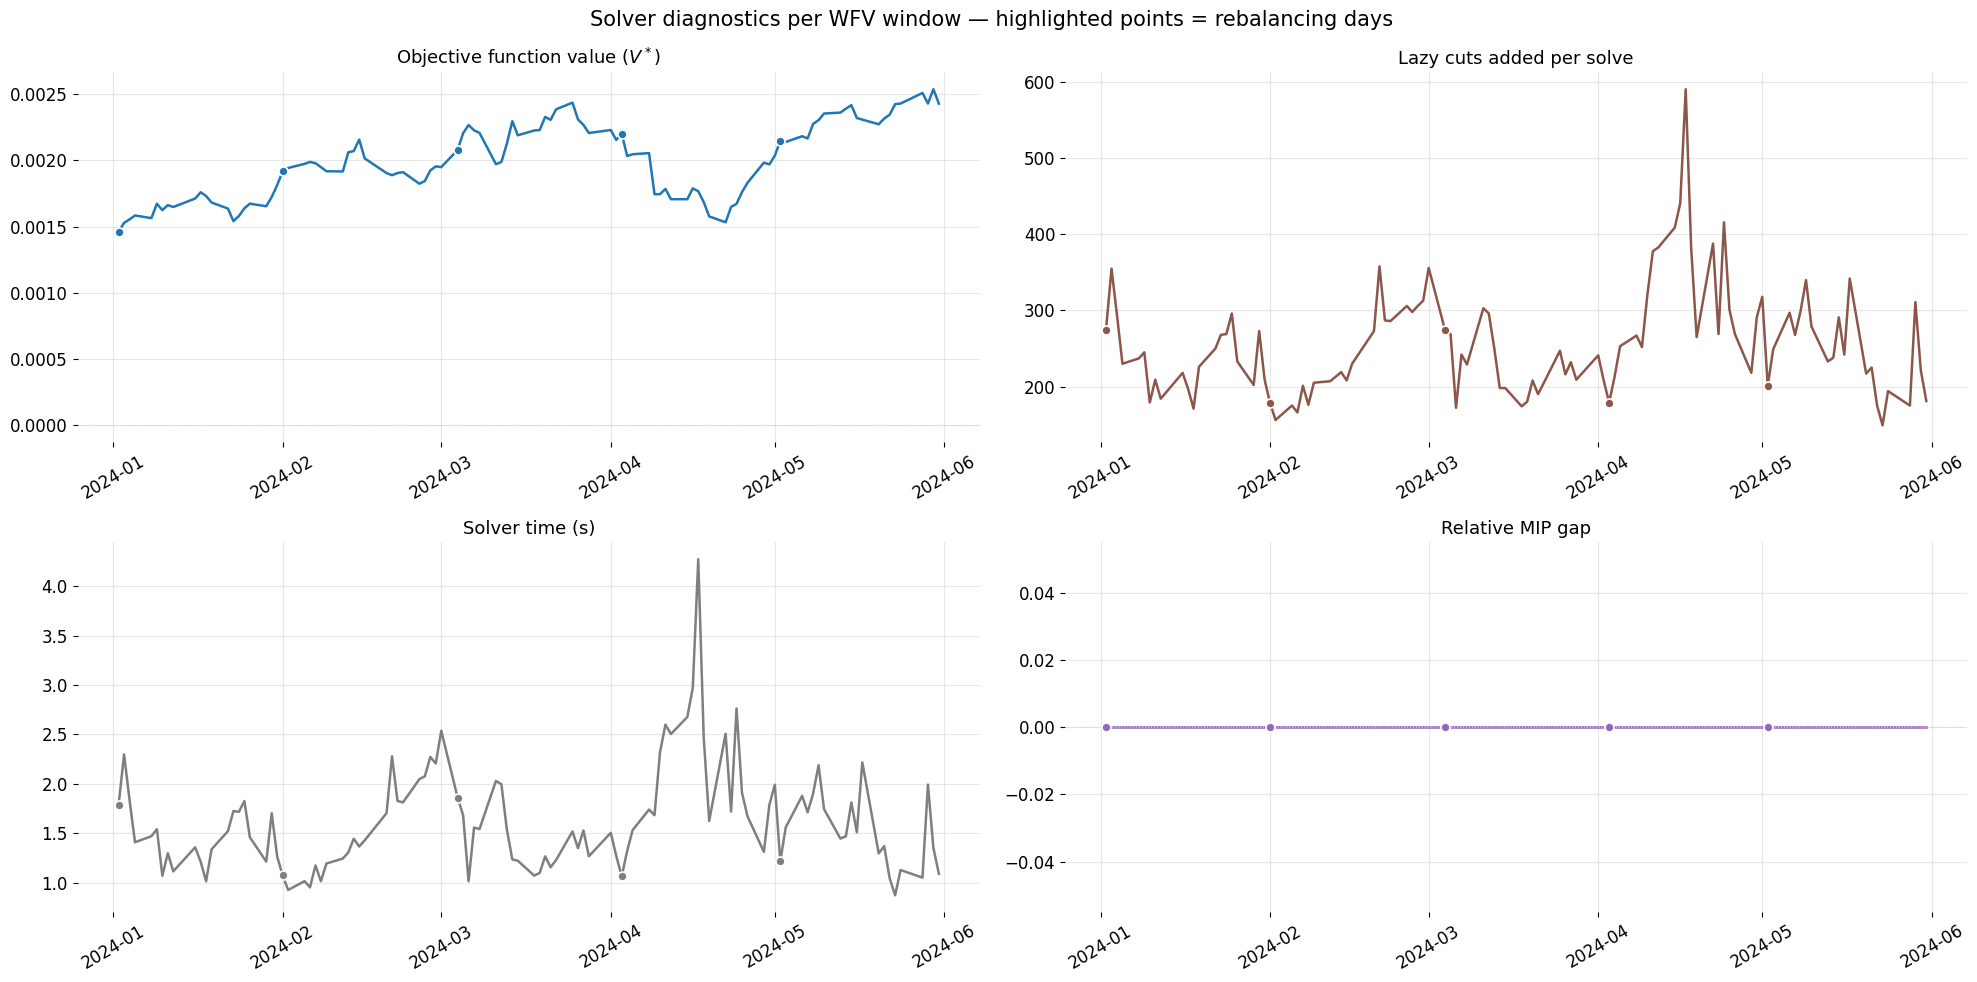

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
fig.patch.set_facecolor('white')

rebal_dates = solver_stats.index[::21]
panels = [
    (axes[0, 0], 'objective',    'Objective function value ($V^*$)', '#1f77b4'),
    (axes[0, 1], 'n_lazy_cuts',  'Lazy cuts added per solve', '#8c564b'),
    (axes[1, 0], 'solve_time_s', 'Solver time (s)', '#7f7f7f'),
    (axes[1, 1], 'mip_gap',      'Relative MIP gap', '#9467bd'),
]

for ax, col, title, color in panels:
    ax.set_facecolor('white')
    ax.plot(solver_stats.index, solver_stats[col], linewidth=1.8, color=color)
    ax.scatter(rebal_dates, solver_stats.loc[rebal_dates, col], s=42, color=color,
               zorder=3, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13)
    ax.tick_params(axis='x', rotation=30)
    for sp in ax.spines.values(): sp.set_visible(False)

axes[0, 0].axhline(0, color='lightgray', linewidth=0.8, linestyle=':')
axes[1, 1].axhline(0, color='lightgray', linewidth=0.8, linestyle=':')

fig.suptitle('Solver diagnostics per WFV window — highlighted points = rebalancing days', fontsize=15)
plt.tight_layout()
plt.savefig(SECTORS_DIR_OUT / 'solver_diagnostics.pdf', bbox_inches='tight')
plt.show()

**Evolution of the diagnostics across WFV windows**

Each point is a full model solve on one day of the walk-forward validation (highlighted points = rebalancing days). The objective panel shows how the dominance slack $V^*$ varies as the training window slides; the lazy cuts, solve time and MIP gap panels characterize the computational difficulty of each window — a gap constant at zero means every solution was proven optimal within the time limit.

---
## 15. Consolidated Analysis of the Experiment
---


### Francesco/Esteves/Valle Model with Sector Benchmarks

---

#### 1. About the model and the formulation

The **Francesco/Esteves/Valle Model (TAF-MultiSSD with sectoral Synthetic Benchmark)** is a natural extension of the second-order stochastic dominance (SSD) model to the multi-benchmark context. Instead of requiring the portfolio to dominate each of the 11 GICS sectors individually (which would require K separate sets of Vs variables and K lazy callbacks), the model uses a **single Synthetic Benchmark** defined as the upper envelope of the unconditional tail expectations of each sector:

$$\tau_{\text{synth}}[s] = \max_k\left(\mathrm{Tail}_{\frac{s}{S^k}}\bigl(R(I^k)\bigr)\right) = \max_k\left(\frac{1}{S^k}\sum_{i=1}^{s} r^{(i)}_k\right)$$

where $r^{(i)}_k$ is the i-th smallest return of sector k in the training period and $S^k$ is its number of scenarios — each component is the unconditional expectation $\mathrm{Tail}_{s/S^k}$ of the $s$ worst returns, not a simple cumulative scalar. This compresses K constraints into a single one, preserving the mathematical coherence of SSD dominance (if the portfolio dominates the Synthetic Benchmark, it dominates any convex combination of the sectors with the same cumulative worst-case).

The solution uses **CPLEX lazy constraint callbacks**: instead of adding all S constraints `Vs_t ≤ Σ R_port − τ_synth[t]` explicitly, only the most violated are added iteratively. This is critical for scalability when S = 200 (training days) and N ≈ 505 (assets).

---

#### 2. Validity of in-sample dominance

In-sample SSD dominance is **guaranteed by construction** when the solver finds the optimal solution (V* is the maximum V such that `(t+1)V ≤ Vs_t` and `Vs_t ≤ Σ R_port − τ_synth[t]` for all t). The fundamental question is: **how much of this dominance generalizes to the OOS period?**

Factors favoring generalization:
- The Synthetic Benchmark is the maximum of 11 sectors — it imposes much stricter constraints than a single benchmark (SP500), forcing genuine diversification.
- The 200-day sliding window captures recent market regimes, making SSD constraints relevant for the near future.
- With 5 rebalancings, the portfolio adapts to regime changes during the OOS period.

Factors limiting generalization:
- The OOS period (104 days) may be dominated by a single sector that was not the binding constraint in-sample.
- The OOS Synthetic Benchmark is built with the same formulation as in-sample — `max_k(Tail_{s/S^k})` over the OOS sector returns, dated by quantile matching. The portfolio was not optimized on this window, so OOS dominance is not guaranteed.

---

#### 3. Interpretation of cross-dominance results

The cross-dominance analysis (section 10, second panel) is particularly informative. If the portfolio dominates only some of the 11 sectors individually in OOS, this is **expected and acceptable**: the model was optimized to dominate the Synthetic Benchmark (the maximum), not each sector individually. A sector that outperformed the Synthetic Benchmark in-sample in some window would, by definition, be dominant over the portfolio.

The most favorable result would be: the portfolio SSD-dominates most sectors individually (e.g., 8/11 or more), confirming that the Synthetic Benchmark constraint is sufficiently rigid to guarantee generalized dominance.

---

#### 4. Tail analysis and asymmetric behavior

The r_P vs r_B scatter (section 10c) reveals the portfolio's asymmetric behavior relative to the Synthetic Benchmark. The ideal interpretation is:

- **β < 1 on the worst benchmark days**: the portfolio falls less when the Synthetic Benchmark falls — direct downside protection, consistent with the SSD constraint on the negative tails of the in-sample distribution.
- **β ≈ 1 or < 1 on the best days**: SSD optimization includes no upside incentive — unlike a return-maximization portfolio. β < 1 on the best days is an expected cost of the pure SSD approach.

This β asymmetry (low in downside, close to 1 in upside) confirms that the model fulfills its fundamental objective: reducing exposure to the worst scenarios without actively maximizing upside.

---

#### 5. Comparison with alternative models

| Aspect | Francesco/Esteves/Valle Model (sectors) | Roman Model (Scaled) | FEV Model (Factors) |
|--------|----------------------------------------|---------------------|---------------------|
| Benchmark | 11 GICS sectors (Synthetic) | SP500 | Fama-French factors (Synthetic) |
| SSD constraints | 1 set vs Synthetic | 1 set vs SP500 | 1 set vs Synthetic (factors) |
| Forced diversification | Sectoral (11 components) | Broad market | Style (value, growth, etc.) |
| Expected OOS generalization | High if sectors are stable | Moderate | High if factors are stable |

The Francesco/Esteves/Valle Model with sectors is the most demanding of the three: forcing SSD dominance over the best of 11 sectors simultaneously is harder than dominating SP500 or a set of factors. Therefore, **lower absolute return is not necessarily a failure** — it is the cost of a stricter benchmark.

---

#### 6. Open questions

1. **Sector universe**: the experiment uses all 11 GICS sectors. A natural extension would be to select only the sectors most correlated with the available assets or with greater return dispersion.
2. **Sector weights**: the Synthetic Benchmark treats all sectors equally (max, not weighted average). A Synthetic Benchmark weighted by capitalization or by some risk measure could be more robust.
3. **Rebalancing horizon**: 21 days is conventional but arbitrary. More frequent rebalancings (e.g., 10 days) could improve adaptation to changes in the dominant sector.
4. **Transaction costs**: the current analysis ignores transaction costs. In concentrated portfolios (few positions with high weights), turnover between rebalancings can be significant — a cost-benefit study would be necessary for practical application.
5. **Extension of the OOS period**: 104 days is a short period for robust validation. A backtest with multiple OOS periods (e.g., 2022–2024 with full walk-forward) would be necessary for definitive conclusions.

---
